# Phase-contrast and dark-ground imaging on the Oxford Er apparatus — design calculations (revised)

**Revision note.** This notebook supersedes the original design calculations. The
derivations and the reference operating point of the original are preserved and
reproduced exactly; the revisions are:

1. **Scattering uses the on-axis (peak Gaussian) intensity**, not the area
   average — atoms sit at the beam centre, where a Gaussian probe is $2\times$
   the area-averaged intensity. This doubles photons scattered per atom and
   halves every destruction-budget shot count. The original convention is kept
   behind a flag (`use_peak_intensity`).
2. **The destruction limit is an atom-loss model, not a heating model.** For
   $^{166}$Er at 401 nm, $E_\mathrm{rec}/k_B=359$ nK is $7.5\times$ the chemical
   potential $\mu/k_B=48$ nK: one scattered photon ejects an atom rather than
   warming the cloud. A family of physically motivated thresholds is compared (§9).
3. **A realistic photon-detection model** — finite quantum efficiency, camera
   read noise, and contrast dilution by the finite-NA PSF — replaces the
   idealised $\mathrm{QE}=1$, noiseless, infinite-resolution SNR (§8).
4. **A new image-formation section** (§7) propagates the actual Thomas-Fermi
   cloud through the 4f system, the Fourier-plane optic, and the camera by
   explicit Fourier optics.
5. **A parameter-sensitivity analysis** (§8.5) quantifies how the headline SNR and
   shot-budget numbers move over the plausible range of the uncertain inputs (camera
   QE and read noise, collisional multiplier $\eta$), with a numerical demonstration
   of the accumulated-SNR invariance and motional / depth-of-focus sanity checks.
6. **Normalisation conventions are made explicit** (§5.3, §7.2): the linear PCI signal
   is $t_p^2+2t_p\varphi$ relative to the incident intensity, or $1+(2/t_p)\varphi$
   relative to the plate-in reference; the transfer-curve figure now plots the genuine tangent.

**Destruction model — refined in §12–§18.** Item 2 and §9 treat destruction as clean atom *loss*, argued from $E_\mathrm{rec}\gg\mu$. Sections 15 onward correct the criterion: what decides whether a recoiled atom leaves is the recoil energy versus the **ODT trap depth** ($\sim\mu$K), not versus $\mu$. Since $E_\mathrm{rec}=359$ nK is well *below* the trap depth, the atom stays trapped and **heats** the cloud (melting a condensate that is only $\sim$22 % condensed) instead of escaping. The realistic model from §12 on is therefore *heating*, with clean loss as an optimistic upper bound; the two bracket the truth, pinned by one measured loss-vs-shots point.

Apparatus baseline: Kucera (DPhil thesis, 2024), **K24** — §3.1.3 imaging arm;
§3.2.2 401 nm laser and transition; §6.3.1 BEC operating point.

### Standard references
* W. Ketterle, D. S. Durfee, D. M. Stamper-Kurn, Varenna lecture notes (1999), arXiv:cond-mat/9904034 — dispersive imaging, §3.
* R. Meppelink et al., Phys. Rev. A **81**, 053632 (2010) — quantitative PCI methodology (primary).
* M. R. Andrews et al., Science **273**, 84 (1996) — first non-destructive BEC observation (DGI).
* M. Gajdacz et al., Rev. Sci. Instrum. **84**, 083105 (2013) — minimally-destructive imaging; destructiveness as fractional loss per image.


**Second extension (this revision).** §17 adds Faraday (polarization-rotation) imaging as a
third dispersive modality alongside PCI/DGI, comparing the dark-field (Gajdacz et al. 2013) and
dual-port (Kaminski et al. 2012) detection schemes. §18 walks the complete simulation pipeline
stage by stage -- from the Thomas-Fermi condensate through to the final camera frame -- for all
four imaging modes side by side, so every headline number in this notebook is traceable back to
where it came from. A full reference list closes the notebook.

**Third extension (this revision).** Part IV (§19) replaces the earlier validation-style anatomy
with a guided, step-by-step walk of a single probe shot through the machine: every figure is the
*actual simulated field or image at that exact line of the algorithm*, in the order the code
computes it, and each step carries its theory, its physical meaning, and the code that executes
it. It ends with the multi-shot run rendered as a filmstrip of the dying condensate.

## 1. Imports and fundamental constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (8, 5), 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 12, 'legend.fontsize': 10, 'figure.dpi': 110,
})
rng = np.random.default_rng(7)   # reproducible noise for the image simulation

# Fundamental constants (SI)
hbar = 1.054571817e-34       # J s
h    = 2*np.pi*hbar
c    = 2.99792458e8          # m/s
kB   = 1.380649e-23          # J/K
amu  = 1.66053907e-27        # kg
a0   = 5.29177211e-11        # Bohr radius, m

## 2. Apparatus and condensate parameters

All inputs are gathered here. New entries relative to the original are flagged
**[rev]**: the detection model and the loss-model controls.

In [2]:
# ---- 166Er and the 401 nm transition (K24 3.2.2) ----
m      = 166 * amu                # atomic mass
lam    = 401.0e-9                 # transition wavelength, m
k      = 2*np.pi/lam              # wavevector
Gamma  = 2*np.pi * 29.5e6         # natural linewidth, rad/s

# ---- Existing 401 nm imaging arm (K24 3.1.3) ----
P_probe_mW = 10.0                 # available probe power at cloud, mW
D_probe    = 24.0e-3              # collimated beam 1/e^2 diameter, m
f1, f2     = 150e-3, 300e-3       # 4f telescope focal lengths, m
pix_cam    = 2.93e-6              # effective camera pixel after 2x mag, m
tau        = 40e-6                 # reference imaging pulse duration, s (sections 6-15 baseline; section 15 folds in tau explicitly)

# ---- BEC operating point (K24 6.3.1) ----
N0     = 2.5e4                    # condensate atom number
a_s    = 72 * a0                  # s-wave scattering length
trap_Hz = np.array([293.0, 14.0, 233.0])   # trap frequencies (x, y, z), Hz
T_cloud = 200e-9                  # thermal cloud temperature, K

# ---- Phase-plate parameters for PCI ----
t_p   = 0.95                      # supplier-spec amplitude transmittance
theta = np.pi/2                   # plate retardation

# ---- [rev] Detection model (verify vs DCC3260M datasheet at lab visit) ----
QE_cam   = 0.40                   # quantum efficiency at 401 nm (CMOS ~0.3-0.5)
read_e   = 7.0                    # read noise, e- rms / pixel
QE_ideal = 1.0                    # reproduces the original notebook

# ---- [rev] Scattering / loss-model controls ----
use_peak_intensity = True         # on-axis Gaussian intensity (atoms at beam centre)
eta_coll = 1.3                    # effective atoms lost per scattered photon (collisional secondaries)

## 3. Atomic and optical constants
$\sigma_0=3\lambda^2/(2\pi)$;  $I_\mathrm{sat}=\pi h c\Gamma/(3\lambda^3)$;
$E_\mathrm{rec}=(\hbar k)^2/2m$, $T_\mathrm{rec}=E_\mathrm{rec}/k_B$.

In [3]:
sigma0 = 3*lam**2 / (2*np.pi)
Isat   = np.pi*h*c*Gamma / (3*lam**3)
E_rec  = (hbar*k)**2 / (2*m)
T_rec  = E_rec/kB
v_rec  = hbar*k/m
E_phot = h*c/lam
print(f"sigma_0  = {sigma0*1e4:.3e} cm^2")
print(f"I_sat    = {Isat*1e-1:.2f} mW/cm^2   (K24 quotes ~60)")
print(f"E_rec/kB = {T_rec*1e9:.1f} nK")
print(f"v_rec    = {v_rec*1e3:.3f} mm/s")

sigma_0  = 7.678e-10 cm^2
I_sat    = 59.80 mW/cm^2   (K24 quotes ~60)
E_rec/kB = 358.7 nK
v_rec    = 5.995 mm/s


## 4. Condensate profile (Thomas-Fermi)
$\mu=\tfrac{\hbar\bar\omega}{2}(15N_0a_s/a_\mathrm{ho})^{2/5}$,
$n_\mathrm{peak}=\mu m/(4\pi\hbar^2a_s)$, $R_i=\sqrt{2\mu/m\omega_i^2}$,
$\tilde n_i^{(\mathrm{peak})}=\tfrac43 n_\mathrm{peak}R_i$.

**[rev] §4.3 condensate-fraction check.** $T_\mathrm{cloud}=200$ nK is consistent with a
condensate only if $T<T_c\simeq0.94\,\hbar\bar\omega N_\mathrm{tot}^{1/3}/k_B$. Solving
$N_0=N_\mathrm{tot}[1-(T/T_c)^3]$ self-consistently fixes $N_\mathrm{tot}$ and the
condensate fraction, to be checked against K24 §6.3.1.

In [4]:
omega = 2*np.pi*trap_Hz
omega_bar = (omega.prod())**(1/3)
a_ho = np.sqrt(hbar/(m*omega_bar))
mu = 0.5*(15*N0*a_s/a_ho)**(2/5) * hbar*omega_bar
T_mu = mu/kB
n_peak = mu*m/(4*np.pi*hbar**2*a_s)
R = np.sqrt(2*mu/(m*omega**2))
n_col = (4/3)*n_peak*R
N_check = (8*np.pi/15) * n_peak * R.prod()

print(f"omega_bar/2pi = {omega_bar/(2*np.pi):.1f} Hz   a_ho = {a_ho*1e6:.3f} um")
print(f"mu/kB    = {T_mu*1e9:.1f} nK")
print(f"n_peak   = {n_peak*1e-6:.3e} cm^-3")
print(f"R(x,y,z) = ({R[0]*1e6:.2f}, {R[1]*1e6:.2f}, {R[2]*1e6:.2f}) um")
print(f"N check  = {N_check:.2e}  (input {N0:.2e})")
for ax_, nc in zip('xyz', n_col):
    print(f"   ncol along {ax_}: {nc*1e-4:.3e} cm^-2")

from scipy.optimize import brentq
def _frac_residual(Ntot):
    Tc = 0.94*hbar*omega_bar/kB * Ntot**(1/3)
    f  = 1-(T_cloud/Tc)**3 if Tc > T_cloud else 0.0
    return Ntot*f - N0                  # condensed atoms must equal N0
N_tot_sc = brentq(_frac_residual, 3e4, 1e7)
Tc_sc = 0.94*hbar*omega_bar/kB * N_tot_sc**(1/3)
print(f"\n[rev] self-consistent: N_tot = {N_tot_sc:.2e}, T_c = {Tc_sc*1e9:.0f} nK, "
      f"condensate fraction = {N0/N_tot_sc:.2f}")
print(f"[rev] => bimodal fit runs against a large thermal pedestal (~{1-N0/N_tot_sc:.0%}); cross-check K24 6.3.1")
print(f"[rev] mu/E_rec = {T_mu/T_rec:.3f}  ->  one scattered photon delivers {T_rec/T_mu:.1f}x mu")

omega_bar/2pi = 98.5 Hz   a_ho = 0.786 um
mu/kB    = 47.6 nK
n_peak   = 3.400e+14 cm^-3
R(x,y,z) = (1.19, 24.82, 1.49) um
N check  = 2.50e+04  (input 2.50e+04)
   ncol along x: 5.376e+10 cm^-2
   ncol along y: 1.125e+12 cm^-2
   ncol along z: 6.760e+10 cm^-2



[rev] self-consistent: N_tot = 1.16e+05, T_c = 217 nK, condensate fraction = 0.22
[rev] => bimodal fit runs against a large thermal pedestal (~78%); cross-check K24 6.3.1
[rev] mu/E_rec = 0.133  ->  one scattered photon delivers 7.5x mu


## 5. Dispersive phase shift

### 5.1 Two-level polarisability
With dimensionless detuning $\delta\equiv2\Delta/\Gamma$,
$\mathrm{Re}\,\alpha\propto-\delta/(1+\delta^2)$, $\mathrm{Im}\,\alpha\propto1/(1+\delta^2)$.
For $|\delta|\gg1$ absorption ($\propto1/\delta^2$) is suppressed faster than refraction
($\propto1/\delta$): a non-resonant probe acquires phase without much attenuation.

### 5.2 Column phase
$\varphi=\dfrac{\sigma_0\tilde n}{2}\dfrac{\delta}{1+\delta^2}\;\xrightarrow{|\delta|\gg1}\;\dfrac{\sigma_0\tilde n}{2\delta}.$

### 5.3 Linear vs Meppelink regime
$I/I_0\approx t_p^2+2t_p\varphi$ (incident-$I_0$ convention; see §7.2) needs $\varphi\lesssim0.5$;
otherwise use the full periodic $I/I_0=|t_p e^{i\theta}+e^{i\varphi}-1|^2$ (Meppelink et al. 2010),
fitting $(t_p,\theta)$ from a detuning scan, and beyond $\varphi=\pi$ the inversion is multivalued.

In [5]:
def delta_of(Delta_Hz):
    return 2*Delta_Hz*2*np.pi/Gamma

def phi_peak(Delta_Hz, n_col_peak):
    d = delta_of(Delta_Hz)
    return sigma0 * n_col_peak * d / (2*(1 + d**2))

def od_resonant_equiv(Delta_Hz, n_col_peak):
    # residual on-resonance-scaled optical depth at this detuning: OD = sigma0 n / (1+delta^2)
    d = delta_of(Delta_Hz)
    return sigma0*n_col_peak/(1+d**2)

print(f"At Delta=1.5 GHz: delta = {delta_of(1.5e9):.1f}")
print(f"  phi_x (across cigar) = {phi_peak(1.5e9, n_col[0]):.3f} rad")
print(f"  phi_y (along cigar)  = {phi_peak(1.5e9, n_col[1]):.3f} rad")
print(f"  residual OD_x        = {od_resonant_equiv(1.5e9, n_col[0]):.4f}  (absorption negligible)")

At Delta=1.5 GHz: delta = 101.7
  phi_x (across cigar) = 0.203 rad
  phi_y (along cigar)  = 4.247 rad
  residual OD_x        = 0.0040  (absorption negligible)


### Table 1 — Peak phase shift at representative detunings

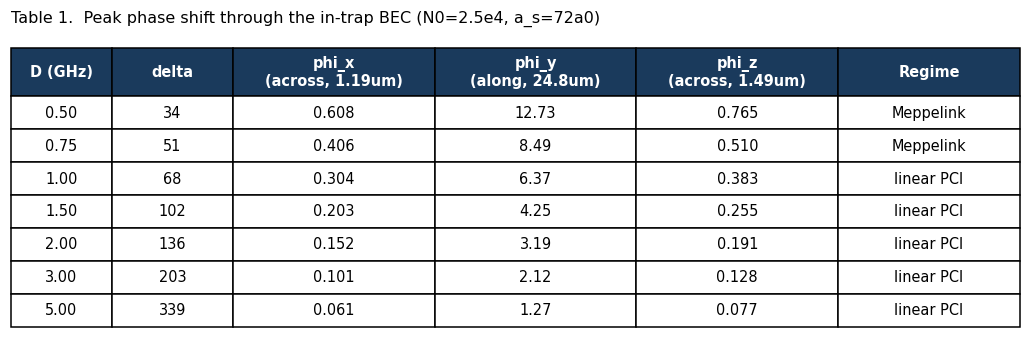

In [6]:
detunings_GHz = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
fig, ax = plt.subplots(figsize=(9.5, 3.3)); ax.axis('off')
col_labels = ['D (GHz)', 'delta', 'phi_x\n(across, 1.19um)',
              'phi_y\n(along, 24.8um)', 'phi_z\n(across, 1.49um)', 'Regime']
rows = []
for Dg in detunings_GHz:
    d = delta_of(Dg*1e9)
    px, py, pz = (phi_peak(Dg*1e9, n_col[i]) for i in range(3))
    pmax = max(px, pz)
    reg = 'linear PCI' if pmax < 0.5 else ('Meppelink' if pmax < np.pi else 'wrapped')
    rows.append([f'{Dg:.2f}', f'{d:.0f}', f'{px:.3f}', f'{py:.2f}', f'{pz:.3f}', reg])
tb = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center',
              colWidths=[.10,.12,.20,.20,.20,.18])
tb.auto_set_font_size(False); tb.set_fontsize(9.5)
for (i,j),cl in tb.get_celld().items():
    cl.set_height(0.16 if i==0 else 0.11)
    if i==0: cl.set_facecolor('#1a3a5c'); cl.set_text_props(color='white', weight='bold')
ax.set_title('Table 1.  Peak phase shift through the in-trap BEC (N0=2.5e4, a_s=72a0)',
             fontsize=10.5, pad=10, loc='left')
plt.tight_layout(); plt.show()

## 6. Photon scattering and per-shot loss

### 6.1 Scattering rate and on-axis intensity
$R_\mathrm{scatt}=\dfrac{\Gamma}{2}\dfrac{s}{1+s+\delta^2}$, $s=I/I_\mathrm{sat}$.
**[rev]** The relevant intensity is the value *at the atoms*. For a Gaussian probe of
$1/e^2$ diameter $D$ carrying power $P$, the on-axis intensity is
$I_\mathrm{peak}=\dfrac{2P}{\pi (D/2)^2}$ — twice the area-averaged
$\bar I = P/[\pi(D/2)^2]$ used in the original. The cloud ($R\le25\,\mu$m) sits well
within the beam centre, so $I_\mathrm{peak}$ is correct for scattering; the flag
`use_peak_intensity` recovers the original $\bar I$ for traceability.

### 6.2 Photons per atom per pulse
$N_\gamma=R_\mathrm{scatt}\,\tau$. In the far-detuned limit $N_\gamma\approx(\Gamma/2)(s/\delta^2)\tau$.

### 6.3 Why heating is the wrong picture, and the loss model
$E_\mathrm{rec}/k_B=359$ nK while $\mu/k_B=48$ nK, so a single recoil ejects an atom
from the condensate. Rather than accumulating temperature, the condensate number
decays as $N_0(s)=N_0\exp(-\eta\,N_\gamma\,s)$ over $s$ shots, where $\eta\ge1$ counts
**collisional secondaries**: a recoiling atom traversing the cloud can knock out
further atoms. The mean free path $\ell=1/(n_\mathrm{peak}\sigma_\mathrm{el})$,
$\sigma_\mathrm{el}=8\pi a_s^2$, sets whether secondaries matter along each axis.

*Refined in §12:* this clean-loss picture is the **optimistic bound**. Because $E_\mathrm{rec}=359$ nK is below the ODT trap depth ($\sim\mu$K), a recoiled atom usually stays trapped and *heats* the cloud rather than escaping; §12 adopts that heating model as the realistic one, with clean loss as the upper bound.

In [7]:
def intensity_at_atoms(P_mW):
    base = (P_mW*1e-3)/(np.pi*(D_probe/2)**2)   # area-averaged
    return 2*base if use_peak_intensity else base

def N_scatt(Delta_Hz, P_mW, tau_s=None):
    if tau_s is None: tau_s = tau
    s = intensity_at_atoms(P_mW)/Isat
    d = delta_of(Delta_Hz)
    return (Gamma/2) * s/(1 + s + d**2) * tau_s

def Nmax_loss(Delta_Hz, P_mW, frac, tau_s=None, eta=None):
    # shots until a fraction `frac` of the condensate is lost:  N0(s)=N0 exp(-eta N_gamma s)
    if eta is None: eta = eta_coll
    return -np.log(1-frac) / (eta*N_scatt(Delta_Hz, P_mW, tau_s))

def Nmax_heat(Delta_Hz, P_mW, eps_K, tau_s=None):
    # original-style cumulative-heating threshold (eta=1): shots until accumulated energy = eps
    return (eps_K/T_rec) / N_scatt(Delta_Hz, P_mW, tau_s)

# collisional mean free path vs cloud size
sigma_el = 8*np.pi*a_s**2
mfp = 1.0/(n_peak*sigma_el)
print(f"elastic cross-section sigma_el = {sigma_el*1e4:.2e} cm^2")
print(f"mean free path at n_peak       = {mfp*1e6:.1f} um")
print(f"  vs  R = ({R[0]*1e6:.2f}, {R[1]*1e6:.2f}, {R[2]*1e6:.2f}) um")
print(f"  -> across-cigar recoils ({R[0]*1e6:.1f}, {R[2]*1e6:.1f} um) mostly escape;")
print(f"     along-cigar recoils ({R[1]*1e6:.1f} um) collide -> eta ~ 1.3-1.5")
print(f"\nN_gamma at (1.5 GHz, 2 mW), peak intensity = {N_scatt(1.5e9, 2.0):.2e}")
print(f"  (original area-averaged convention would give {N_scatt(1.5e9,2.0)/2:.2e})")

# --- motional sanity check: is the cloud frozen during the probe pulse? ---
disp_recoil = v_rec * tau                     # displacement of a single-recoil atom during tau
T_trap_min = 1/trap_Hz.max()                  # shortest trap period
print(f"\n[check] recoil displacement during {tau*1e6:.0f} us pulse = {disp_recoil*1e9:.0f} nm "
      f"(<< pixel {pix_cam/(f2/f1)*1e6:.2f} um, resolution {0.61*lam/((D_probe/2)/f1)*1e6:.2f} um)")
print(f"[check] shortest trap period {T_trap_min*1e3:.2f} ms >> pulse {tau*1e6:.0f} us "
      f"-> in-trap dynamics frozen during the shot; no motional blur")

elastic cross-section sigma_el = 3.65e-12 cm^2
mean free path at n_peak       = 8.1 um
  vs  R = (1.19, 24.82, 1.49) um
  -> across-cigar recoils (1.2, 1.5 um) mostly escape;
     along-cigar recoils (24.8 um) collide -> eta ~ 1.3-1.5

N_gamma at (1.5 GHz, 2 mW), peak intensity = 5.30e-03
  (original area-averaged convention would give 2.65e-03)

[check] recoil displacement during 40 us pulse = 240 nm (<< pixel 1.46 um, resolution 3.06 um)
[check] shortest trap period 3.41 ms >> pulse 40 us -> in-trap dynamics frozen during the shot; no motional blur


## 7. Image formation — phase to camera intensity

This section makes the imaging chain explicit and quantitative: how the column
phase $\varphi(\mathbf r_\perp)$ becomes the intensity recorded on the camera, for
each of the three modes, and what the finite numerical aperture and the detector
do to the measured contrast.

### 7.1 Decomposition at the Fourier plane
The field just after the cloud is $E_0\,e^{i\varphi(\mathbf r_\perp)}$ (absorption
negligible, §5.1). Writing $e^{i\varphi}=1+(e^{i\varphi}-1)$ separates the
**un-diffracted carrier** "1" — which focuses to the $d_\mathrm{DC}=2.44\lambda f_1/D=6.1\,\mu$m
DC spot — from the **scattered field** $(e^{i\varphi}-1)$, which spreads across the
Fourier plane on the scale set by the cloud size ($\gtrsim$ mm). The Fourier-plane
optic acts only on the DC spot:

* **PCI** — phase dot multiplies the carrier by $t_p e^{i\theta}$:
  $I/I_0=|t_p e^{i\theta}+(e^{i\varphi}-1)|^2$.
* **DGI** — opaque stop removes the carrier ($\times10^{-\mathrm{OD}/2}\!\to\!0$):
  $I/I_0=|e^{i\varphi}-1|^2=4\sin^2(\varphi/2)$.
* **RAI / clear** — carrier untouched: $I/I_0=|e^{i\varphi}|^2=1$ in the dispersive limit
  (no absorption signal; this is why RAI needs near-resonant light, not the dispersive probe).

### 7.2 Transfer curves
**Two normalisation conventions, stated explicitly** (a frequent source of factor-of-$t_p$
confusion). Expanding the full PCI expression for small $\varphi$ at $\theta=\pi/2$ gives
$I/I_0 = t_p^2 + 2(1-\cos\varphi) + 2t_p\sin\varphi \approx t_p^2 + 2t_p\varphi$, i.e.
relative to the **incident** intensity $I_0$ the linear PCI signal sits on the plate
pedestal $t_p^2$ with slope $2t_p$. In practice each shot is divided by a no-atom image
*taken with the plate in beam* (level $t_p^2$), so the **processed ratio** is
$I/I_{0,\mathrm{plate}} \approx 1 + (2/t_p)\,\varphi$ — slope $2/t_p\approx2.1$, intercept 1.
The two differ only by the constant $t_p^2$ and the $t_p$ in the slope ($\le$10% for
$t_p=0.95$); §8 and the simulation use the incident-$I_0$ form ($t_p^2+2t_p\varphi$)
consistently. The curve below plots the incident-$I_0$ convention, so the linear
approximation is the genuine tangent to the full curve at $\varphi=0$ (both start at $t_p^2$).
DGI is intrinsically quadratic and sign-blind (it cannot distinguish $+\varphi$ from
$-\varphi$). The sign of $\theta$ flips PCI between bright-on-bright and dark-on-bright
(the protocols' "dark cloud" diagnostic).

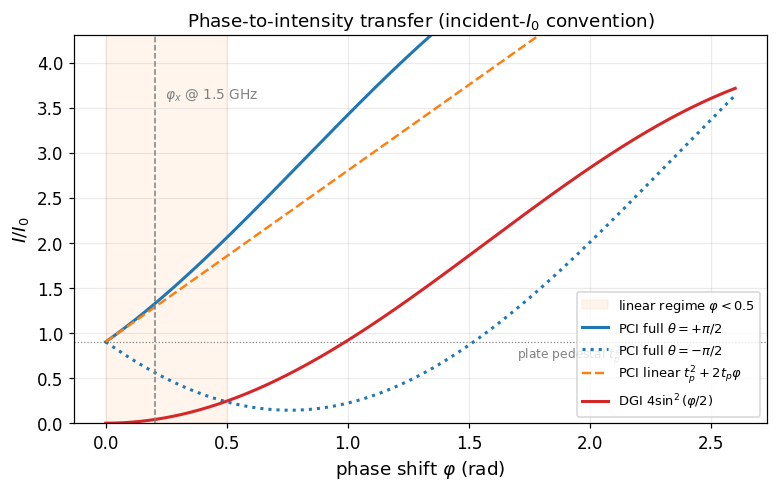

In [8]:
phi = np.linspace(0, 2.6, 600)
I_pci_p = np.abs(t_p*np.exp(1j*np.pi/2) + np.exp(1j*phi) - 1)**2
I_pci_m = np.abs(t_p*np.exp(-1j*np.pi/2) + np.exp(1j*phi) - 1)**2
I_lin   = t_p**2 + 2*t_p*phi          # genuine tangent: intercept t_p^2 (plate pedestal), slope 2 t_p
I_dgi   = np.abs(np.exp(1j*phi) - 1)**2
phx = phi_peak(1.5e9, n_col[0])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axvspan(0, 0.5, color='C1', alpha=0.07, label=r'linear regime $\varphi<0.5$')
ax.axhline(t_p**2, color='gray', lw=0.8, ls=':')
ax.annotate(r'plate pedestal $t_p^2$', (1.7, t_p**2-0.18), color='gray', fontsize=8)
ax.plot(phi, I_pci_p, 'C0', lw=2, label=r'PCI full $\theta=+\pi/2$')
ax.plot(phi, I_pci_m, 'C0:', lw=2, label=r'PCI full $\theta=-\pi/2$')
ax.plot(phi, I_lin, 'C1--', lw=1.6, label=r'PCI linear $t_p^2+2t_p\varphi$')
ax.plot(phi, I_dgi, 'C3', lw=2, label=r'DGI $4\sin^2(\varphi/2)$')
ax.axvline(phx, color='gray', ls='--', lw=1)
ax.annotate(r'$\varphi_x$ @ 1.5 GHz', (phx+0.04, 3.6), color='gray', fontsize=9)
ax.set_xlabel(r'phase shift $\varphi$ (rad)'); ax.set_ylabel(r'$I/I_0$')
ax.set_title('Phase-to-intensity transfer (incident-$I_0$ convention)'); ax.set_ylim(0, 4.3)
ax.legend(fontsize=8.5); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### 7.3 Fourier-optics simulation through the real arm
We propagate the actual TF column-phase profile through the system: forward FFT to
the Fourier plane, apply (i) the finite-NA pupil of L1 ($\mathrm{NA}=D/2f_1=0.08$) and
(ii) the Fourier-plane optic on the carrier, inverse FFT to the image plane.

The **blur (contrast-dilution) factor** for imaging along a given axis is a pure
geometry/NA property: the ratio of the NA-limited centre contrast to the ideal
(infinite-NA) contrast, evaluated at a small test phase so it is independent of the
operating $\varphi$. It depends on the **two transverse radii in the image plane**:

* across-cigar (image $x$, along $\hat x$): plane carries $(y,z)=(24.8,1.49)\,\mu$m — one
  resolved, one not.
* along-cigar (image along $\hat y$): plane carries $(x,z)=(1.19,1.49)\,\mu$m — **both**
  below the $3.06\,\mu$m Rayleigh limit, so along-cigar imaging is *more* blurred, not
  less. It buys a large column density (hence large $\varphi$) at the cost of
  resolving nothing transversely; it is an atom-number probe, not a structure probe.

The simulation reference background is the plate-only level $t_p^2$ (the no-atom image
with the phase plate in beam), so the signal is $I_\mathrm{img}-t_p^2$, not $I_\mathrm{img}-1$.

In [9]:
Ngrid, FOV = 1024, 100e-6
dgrid = FOV/Ngrid
gax = (np.arange(Ngrid)-Ngrid//2)*dgrid
GA, GB = np.meshgrid(gax, gax)
NA = (D_probe/2)/f1
fx = np.fft.fftfreq(Ngrid, dgrid); FX, FY = np.meshgrid(fx, fx)
pupil = (np.sqrt(FX**2+FY**2) <= NA/lam).astype(float)
bg_plate = t_p**2                       # no-atom, plate-in reference level

def _tf_profile(Ra, Rb):
    return np.maximum(0, 1 - GA**2/Ra**2 - GB**2/Rb**2)**1.5

def sim_image(axis, phi_peak_val, mode='PCI', OD=4.0):
    plane = [i for i in range(3) if i != axis]
    prof = _tf_profile(R[plane[0]], R[plane[1]])
    Esc = np.fft.ifft2(np.fft.fft2(np.exp(1j*phi_peak_val*prof)-1)*pupil)
    if mode == 'PCI':   E = t_p*np.exp(1j*theta) + Esc
    elif mode == 'DGI': E = 10**(-OD/2) + Esc
    else:               E = 1 + Esc
    return np.abs(E)**2, prof

def blur_for_axis(axis, phi_test=0.1):
    Iimg, _ = sim_image(axis, phi_test, 'PCI')
    ideal = np.abs(t_p*np.exp(1j*theta) + (np.exp(1j*phi_test)-1))**2  # infinite-NA, uniform peak
    return (Iimg.max()-bg_plate)/(ideal-bg_plate)

blur_axis = {a: blur_for_axis(a) for a in range(3)}
blur_factor = blur_axis[0]   # across-cigar, used by the reference figures below
print(f"NA = {NA:.3f}, Rayleigh dx = {0.61*lam/NA*1e6:.2f} um")
for a, nm in zip(range(3), ['across (image y,z)', 'along  (image x,z)', 'across (image x,y)']):
    pl = [i for i in range(3) if i != a]
    print(f"  axis {('xyz')[a]} {nm}: transverse R = "
          f"({R[pl[0]]*1e6:.1f}, {R[pl[1]]*1e6:.1f}) um  ->  blur = {blur_axis[a]:.2f}")

NA = 0.080, Rayleigh dx = 3.06 um
  axis x across (image y,z): transverse R = (24.8, 1.5) um  ->  blur = 0.61
  axis y along  (image x,z): transverse R = (1.2, 1.5) um  ->  blur = 0.24
  axis z across (image x,y): transverse R = (1.2, 24.8) um  ->  blur = 0.50


### 7.4 Simulated camera frames and lineouts
Binned to camera pixels (1.47 $\mu$m at object) with $\mathrm{QE}=0.40$, $7\,e^-$ read
noise, at the reference PCI point (2 mW) and the protocols' DGI commissioning point
(5 mW). The detected photons per pixel use the **on-axis (peak) probe intensity** — the
same convention as the scattering calculation, since the cloud and the pixels imaging
it both sit at the beam centre.

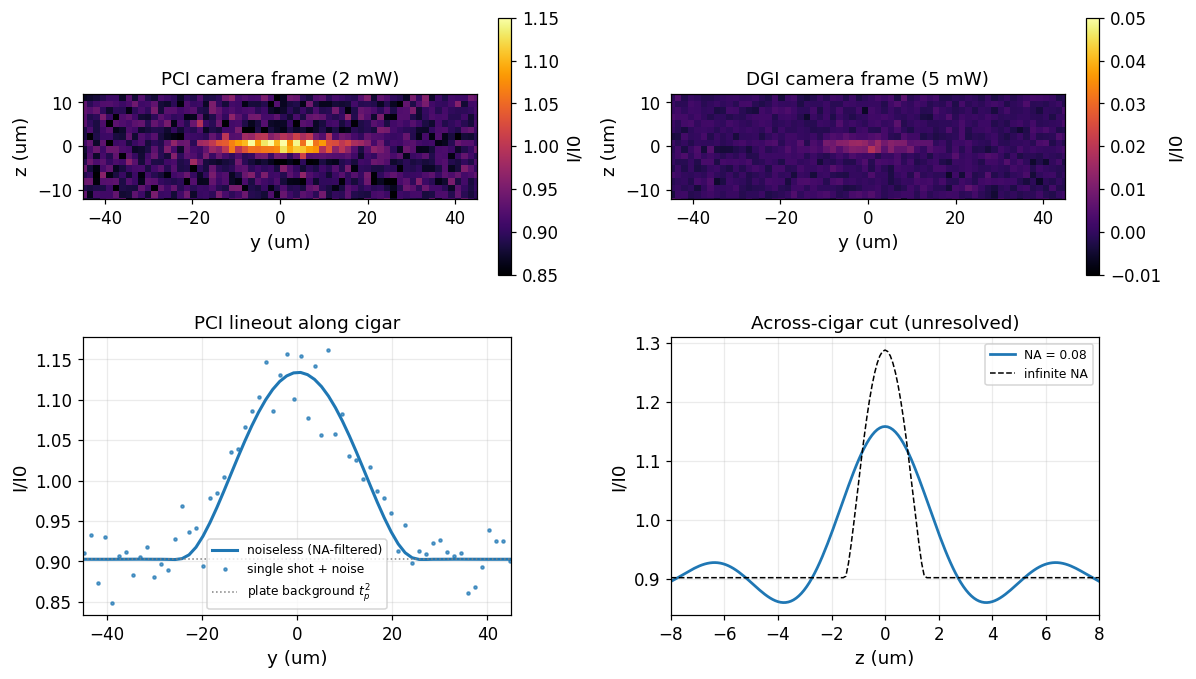

In [10]:
Mag = f2/f1; pix_obj = pix_cam/Mag

def N_phot_pix(P_mW, tau_s=None, QE=None):
    # Detected photons per camera pixel at I/I0 = 1, using the probe intensity AT the
    # cloud (beam centre). Consistent with intensity_at_atoms used for scattering.
    tau_set = 100e-6
    if tau_s is None: tau_s = tau_set
    if QE is None: QE = QE_cam
    return intensity_at_atoms(P_mW) * pix_obj**2 * tau_s * QE / E_phot

I_img_pci, prof0 = sim_image(0, phx, 'PCI')
I_img_dgi, _     = sim_image(0, phi_peak(1.5e9, n_col[0]), 'DGI')

def to_camera(Iratio, P_mW, QE=None):
    nb = (Ngrid//15)*15
    binned = Iratio[:nb,:nb].reshape(nb//15,15,nb//15,15).mean(axis=(1,3))
    Nd = N_phot_pix(P_mW, QE=QE)
    counts = rng.poisson(np.clip(binned,0,None)*Nd) + rng.normal(0, read_e, binned.shape)
    return counts/Nd, binned

cam_pci, ideal_pci = to_camera(I_img_pci, 2.0)
cam_dgi, ideal_dgi = to_camera(I_img_dgi, 5.0)
ext = [-FOV/2*1e6, FOV/2*1e6, -FOV/2*1e6, FOV/2*1e6]

fig, axs = plt.subplots(2, 2, figsize=(11, 6.4))
im0 = axs[0,0].imshow(cam_pci, extent=ext, origin='lower', cmap='inferno', vmin=0.85, vmax=1.15)
axs[0,0].set_title('PCI camera frame (2 mW)'); plt.colorbar(im0, ax=axs[0,0], fraction=0.03, label='I/I0')
im1 = axs[0,1].imshow(cam_dgi, extent=ext, origin='lower', cmap='inferno', vmin=-0.01, vmax=0.05)
axs[0,1].set_title('DGI camera frame (5 mW)'); plt.colorbar(im1, ax=axs[0,1], fraction=0.03, label='I/I0')
for a in axs[0]:
    a.set_xlim(-45,45); a.set_ylim(-12,12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')

nb = Ngrid//15; ycam = (np.arange(nb)-nb//2+0.5)*pix_obj*1e6; mid = nb//2
axs[1,0].plot(ycam, ideal_pci[mid], 'C0', lw=2, label='noiseless (NA-filtered)')
axs[1,0].plot(ycam, cam_pci[mid], 'C0.', ms=4, alpha=0.7, label='single shot + noise')
axs[1,0].axhline(bg_plate, color='gray', ls=':', lw=1, label=r'plate background $t_p^2$')
axs[1,0].set_xlim(-45,45); axs[1,0].set_xlabel('y (um)'); axs[1,0].set_ylabel('I/I0')
axs[1,0].set_title('PCI lineout along cigar'); axs[1,0].legend(fontsize=8); axs[1,0].grid(alpha=0.25)

zf = gax*1e6
axs[1,1].plot(zf, I_img_pci[:, Ngrid//2], 'C0', lw=1.8, label='NA = 0.08')
axs[1,1].plot(zf, bg_plate+2*t_p*phx*np.maximum(0,1-(gax)**2/R[2]**2)**1.5, 'k--', lw=1, label='infinite NA')
axs[1,1].set_xlim(-8,8); axs[1,1].set_xlabel('z (um)'); axs[1,1].set_ylabel('I/I0')
axs[1,1].set_title('Across-cigar cut (unresolved)'); axs[1,1].legend(fontsize=8); axs[1,1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Photon shot-noise SNR

### 8.1 Idealised single-shot SNR (original)
$\mathrm{SNR}_\mathrm{shot}=2t_p\varphi\sqrt{N_\mathrm{phot}}$ at the centre pixel — the
photon-shot-noise limit at $\mathrm{QE}=1$, infinite resolution, linear regime.

### 8.2 Realistic detection [rev]
Four corrections, all now applied consistently:
* **Peak intensity.** Detected photons use the on-axis probe intensity (§6.1), the
  same convention as scattering — the cloud and the pixels imaging it both sit at the
  beam centre. (An earlier draft used the area average here, a factor-$\sqrt2$ pessimism, now removed.)
* **Plate-dimmed background.** The processed ratio references the no-atom, plate-in
  image at level $t_p^2$, so the signal is $I_\mathrm{img}-t_p^2$ and the local shot
  noise scales with the actual level $I_\mathrm{img}$, not $1$.
* **Full-model sensitivity & a phase-regime guard.** Contrast uses the full transfer
  $I=|t_p e^{i\theta}+e^{i\varphi}-1|^2$, not the linear tangent, and SNR is **only
  reported where $\varphi<\pi$** (single-valued); beyond that the inversion is
  ambiguous and a linear SNR is meaningless (this is why the along-cigar axis at
  1.5 GHz, $\varphi_y=4.25$ rad, returns NaN rather than a spurious large number).
* **Axis-aware NA blur** $b_\mathrm{axis}$ from §7.3.

### 8.3 Per-pixel vs per-resolution-element, from the simulation
Because the cloud is unresolved across the cigar, the honest per-resolution-element
SNR is obtained by **integrating the real Fourier-optics image** over a resolution
element, not by an analytic $b\times\mathrm{bin}^2$ formula (which would wrongly treat
NA-lost light as recoverable). Both are reported.

### 8.4 Accumulated-SNR invariance
$\mathrm{SNR}_\mathrm{total}=\mathrm{SNR}_\mathrm{shot}\sqrt{N}$ with $N\le N_\mathrm{max}$.
Because $\mathrm{SNR}_\mathrm{shot}\propto\sqrt{P\tau}/\delta$ and $N_\mathrm{max}\propto\delta^2/(P\tau)$,
the **photon-limited** total SNR is independent of $(\Delta,P,\tau)$ — set only by the
destruction budget. Read noise breaks this invariance (it favours fewer, brighter shots).

In [11]:
def I_full(phi):
    return np.abs(t_p*np.exp(1j*theta) + np.exp(1j*phi) - 1)**2   # incident-I0 units; no-atom = t_p^2

def regime_of(phi):
    return 'linear' if phi < 0.5 else ('Meppelink' if phi < np.pi else 'phase-wrapped')

def SNR_shot_ideal(Delta_Hz, P_mW, axis=0, tau_s=None):
    # original idealised reference: linear contrast, QE=1, infinite NA
    phi = phi_peak(Delta_Hz, n_col[axis])
    Nph = N_phot_pix(P_mW, tau_s, QE=QE_ideal)
    return 2*t_p*phi*np.sqrt(Nph)

def SNR_pixel(Delta_Hz, P_mW, axis=0, tau_s=None):
    # realistic single-pixel SNR at cloud centre (full model, peak intensity, plate bg, axis blur)
    phi = phi_peak(Delta_Hz, n_col[axis])
    if phi >= np.pi:
        return np.nan                       # ambiguous; not a single-valued measurement
    Iimg = bg_plate + blur_axis[axis]*(I_full(phi) - bg_plate)
    Nph  = N_phot_pix(P_mW, tau_s)
    return abs(Iimg - bg_plate)*Nph/np.sqrt(abs(Iimg)*Nph + read_e**2)

def SNR_reselem_sim(Delta_Hz, P_mW, axis=0, tau_s=None, half=1):
    # trustworthy per-resolution-element SNR by integrating the real simulated image
    phi = phi_peak(Delta_Hz, n_col[axis])
    if phi >= np.pi:
        return np.nan
    Iimg, _ = sim_image(axis, phi, 'PCI')
    nb = (Ngrid//15)*15
    binned = Iimg[:nb,:nb].reshape(nb//15,15,nb//15,15).mean(axis=(1,3))
    Nd = N_phot_pix(P_mW, tau_s)
    m = binned.shape[0]//2
    blk = binned[m-half:m+half+1, m-half:m+half+1]
    S = (blk - bg_plate).sum()*Nd
    noise = np.sqrt(blk.sum()*Nd + blk.size*read_e**2)
    return S/noise

print("Across-cigar (x), reference detuning 1.5 GHz, regime:", regime_of(phi_peak(1.5e9, n_col[0])))
for P in [2.0, 5.0, 10.0]:
    print(f"  P={P:4.1f} mW:  ideal(QE=1)={SNR_shot_ideal(1.5e9,P):5.1f}   "
          f"realistic/pixel={SNR_pixel(1.5e9,P):4.1f}   "
          f"realistic/res-elem(sim)={SNR_reselem_sim(1.5e9,P):4.1f}")
dgi_peak = sim_image(0, phi_peak(1.5e9, n_col[0]), 'DGI')[0].max()
_dgi5 = dgi_peak*N_phot_pix(5.0)
_dgi_stat = 'quantitative (> 3x read noise)' if _dgi5 > 3*read_e else ('above the read-noise floor' if _dgi5 > read_e else 'below the read-noise floor')
print(f"\nDGI single-shot of the BEC (5 mW): peak signal ~{dgi_peak:.3f} of I0 = "
      f"{_dgi5:.1f} e- vs {read_e} e- read -> {_dgi_stat}")

# --- numerical demonstration of the accumulated-SNR invariance (photon-limited) ---
print("\n[8.4 check] photon-limited total SNR = SNR_shot(QE=1) x sqrt(Nmax) over a full budget:")
print("   detuning   SNR_shot   Nmax(30%)   accumulated = SNR_shot*sqrt(Nmax)")
for Dg in [0.75, 1.0, 1.5, 2.0, 3.0]:
    ss = SNR_shot_ideal(Dg*1e9, 2.0); nm = Nmax_loss(Dg*1e9, 2.0, 0.30)
    print(f"   {Dg:4.2f} GHz   {ss:6.1f}     {nm:7.0f}      {ss*np.sqrt(nm):8.1f}")
print("   -> ~constant: total photon-limited SNR is set by the destruction budget, not by (Delta,P,tau)")

Across-cigar (x), reference detuning 1.5 GHz, regime: linear
  P= 2.0 mW:  ideal(QE=1)= 23.9   realistic/pixel= 9.3   realistic/res-elem(sim)=18.9
  P= 5.0 mW:  ideal(QE=1)= 37.7   realistic/pixel=14.9   realistic/res-elem(sim)=30.1


  P=10.0 mW:  ideal(QE=1)= 53.4   realistic/pixel=21.1   realistic/res-elem(sim)=42.7

DGI single-shot of the BEC (5 mW): peak signal ~0.016 of I0 = 61.1 e- vs 7.0 e- read -> quantitative (> 3x read noise)

[8.4 check] photon-limited total SNR = SNR_shot(QE=1) x sqrt(Nmax) over a full budget:
   detuning   SNR_shot   Nmax(30%)   accumulated = SNR_shot*sqrt(Nmax)
   0.75 GHz     47.7          13         171.7
   1.00 GHz     35.8          23         171.7
   1.50 GHz     23.9          52         171.7
   2.00 GHz     17.9          92         171.7
   3.00 GHz     11.9         207         171.7
   -> ~constant: total photon-limited SNR is set by the destruction budget, not by (Delta,P,tau)


## 9. Maximum non-destructive shots — threshold family [revised]

The shot budget follows from the loss model $N_0(s)=N_0e^{-\eta N_\gamma s}$ (§6.3).
For a tolerated condensate-loss fraction $f$, $N_\mathrm{max}=-\ln(1-f)/(\eta N_\gamma)$.
Several thresholds are physically motivated; we evaluate all of them and let the plots
decide which is most reasonable.

| threshold | meaning | equivalent loss |
|---|---|---|
| $\varepsilon=\mu$ (original) | heating $=\mu$; with $E_\mathrm{rec}\gg\mu$ this is $\mu/E_\mathrm{rec}=13\%$ loss | 13% |
| 30% loss | the protocols-doc §4.5 acceptance test ("<30% loss over ~100 shots") | 30% |
| 50% loss | half-life of the condensate | 50% |
| $\varepsilon=k_BT_\mathrm{cloud}$ | thermal-pedestal ceiling (different observable) | — |
| 1 photon/atom | classic dispersive-imaging bar (Ketterle/Andrews) | — |

Collisional secondaries enter through $\eta$; the original used $\eta=1$.

In [12]:
# Nmax_loss and Nmax_heat are defined in section 6.3 (the loss model); applied here.
D, P = 1.5e9, 2.0
print("At reference point (1.5 GHz, 2 mW), peak-intensity convention, eta = %.1f:" % eta_coll)
print(f"  eps=mu (=13% loss)     N_max = {Nmax_loss(D,P,T_mu/T_rec):5.0f}")
print(f"  30% loss               N_max = {Nmax_loss(D,P,0.30):5.0f}")
print(f"  50% loss               N_max = {Nmax_loss(D,P,0.50):5.0f}")
print(f"  eps=kT_cloud           N_max = {Nmax_heat(D,P,T_cloud):5.0f}")
print(f"  1 photon/atom (eta=1)  N_max = {1.0/N_scatt(D,P):5.0f}")
print(f"\nFor comparison, the ORIGINAL notebook (area-avg intensity, eta=1, eps=mu): N_max = {(T_mu/T_rec)/(N_scatt(D,P)/2):.0f}")
print(f"  -> the two corrections (peak intensity x2, eta={eta_coll}) reduce eps=mu N_max from ~134 to ~{Nmax_loss(D,P,T_mu/T_rec):.0f}")
print(f"  -> but the recommended 30%-loss criterion gives N_max = {Nmax_loss(D,P,0.30):.0f}, still clearing the 100-shot goal")

At reference point (1.5 GHz, 2 mW), peak-intensity convention, eta = 1.3:
  eps=mu (=13% loss)     N_max =    21
  30% loss               N_max =    52
  50% loss               N_max =   101
  eps=kT_cloud           N_max =   105
  1 photon/atom (eta=1)  N_max =   189

For comparison, the ORIGINAL notebook (area-avg intensity, eta=1, eps=mu): N_max = 50
  -> the two corrections (peak intensity x2, eta=1.3) reduce eps=mu N_max from ~134 to ~21
  -> but the recommended 30%-loss criterion gives N_max = 52, still clearing the 100-shot goal


### Figure — shot budget vs detuning for the candidate thresholds

/tmp/ipykernel_598/749755447.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


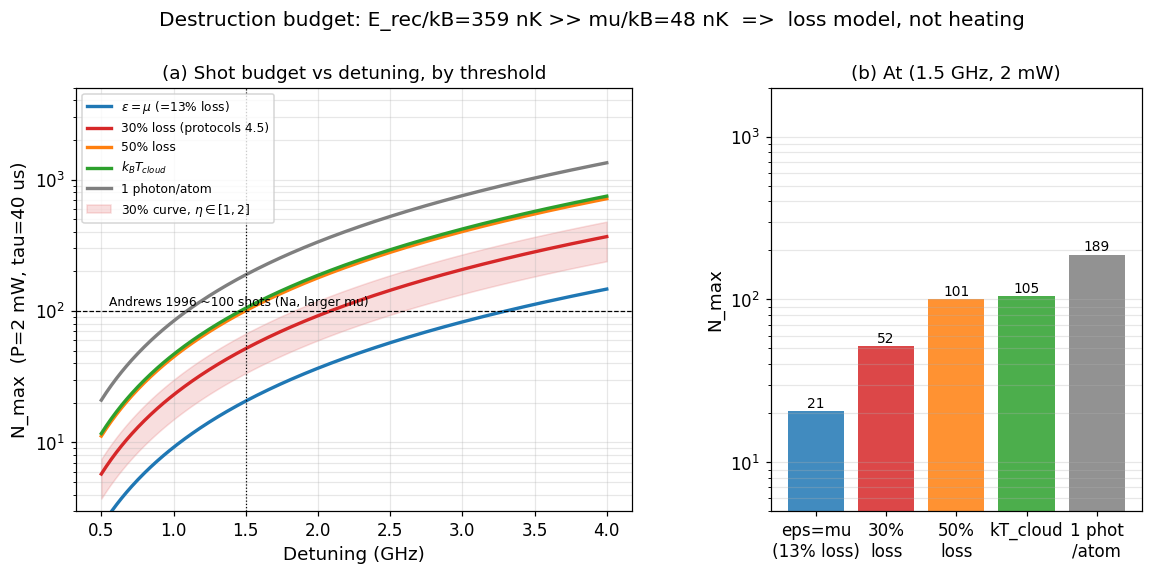

In [13]:
Dg = np.linspace(0.5, 4.0, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 5.0),
                             gridspec_kw=dict(width_ratios=[1.5,1], wspace=0.3))
curves = [
    (Nmax_loss(Dg*1e9, 2.0, T_mu/T_rec), r'$\varepsilon=\mu$ (=13% loss)', 'tab:blue'),
    (Nmax_loss(Dg*1e9, 2.0, 0.30),       '30% loss (protocols 4.5)',      'tab:red'),
    (Nmax_loss(Dg*1e9, 2.0, 0.50),       '50% loss',                       'tab:orange'),
    (Nmax_heat(Dg*1e9, 2.0, T_cloud),    r'$k_B T_{cloud}$',               'tab:green'),
    (1.0/N_scatt(Dg*1e9, 2.0),           '1 photon/atom',                  'tab:gray'),
]
for y, lab, col in curves:
    a1.semilogy(Dg, y, color=col, lw=2.2, label=lab)
a1.fill_between(Dg, Nmax_loss(Dg*1e9,2.0,0.30,eta=2.0), Nmax_loss(Dg*1e9,2.0,0.30,eta=1.0),
                color='tab:red', alpha=0.15, label=r'30% curve, $\eta\in[1,2]$')
a1.axhline(100, color='k', ls='--', lw=0.8); a1.axvline(1.5, color='k', ls=':', lw=0.8)
a1.annotate('Andrews 1996 ~100 shots (Na, larger mu)', (0.55, 110), fontsize=8)
a1.set_xlabel('Detuning (GHz)'); a1.set_ylabel('N_max  (P=2 mW, tau=40 us)')
a1.set_ylim(3, 5e3); a1.grid(alpha=0.3, which='both'); a1.legend(fontsize=8, loc='upper left')
a1.set_title('(a) Shot budget vs detuning, by threshold')

labels = ['eps=mu\n(13% loss)','30%\nloss','50%\nloss','kT_cloud','1 phot\n/atom']
vals = [Nmax_loss(1.5e9,2.0,T_mu/T_rec), Nmax_loss(1.5e9,2.0,0.30), Nmax_loss(1.5e9,2.0,0.50),
        Nmax_heat(1.5e9,2.0,T_cloud), 1.0/N_scatt(1.5e9,2.0)]
cols = ['tab:blue','tab:red','tab:orange','tab:green','tab:gray']
bars = a2.bar(labels, vals, color=cols, alpha=0.85)
for b,v in zip(bars, vals): a2.text(b.get_x()+b.get_width()/2, v*1.05, f'{v:.0f}', ha='center', fontsize=9)
a2.set_yscale('log'); a2.set_ylim(5, 2e3); a2.set_ylabel('N_max'); a2.grid(alpha=0.3, axis='y', which='both')
a2.set_title('(b) At (1.5 GHz, 2 mW)')
fig.suptitle('Destruction budget: E_rec/kB=359 nK >> mu/kB=48 nK  =>  loss model, not heating', y=1.02)
plt.tight_layout(); plt.show()

## 10. Spatial resolution
$\mathrm{NA}=(D/2)/f_1=0.08$, $\Delta x=0.61\lambda/\mathrm{NA}=3.06\,\mu$m. The across-cigar
radii ($R_x=1.19$, $R_z=1.49\,\mu$m) are unresolved; $R_y=24.8\,\mu$m is resolved. Brief
time-of-flight $R_i(t)=R_i(0)\sqrt{1+(\omega_i t)^2}$ restores transverse resolution.

In [14]:
NA_e = (D_probe/2)/f1
res_e = 0.61*lam/NA_e
res_obj = 0.61*lam/0.40
t_arr = np.linspace(0, 2e-3, 2000)
Rx_t = R[0]*np.sqrt(1+(omega[0]*t_arr)**2)
t_cross = t_arr[np.argmax(Rx_t > res_e)]
print(f"existing arm NA={NA_e:.3f}: dx = {res_e*1e6:.2f} um")
print(f"trichroic obj NA=0.40:     dx = {res_obj*1e6:.2f} um")
print(f"Rx(t) crosses dx at t = {t_cross*1e3:.2f} ms")

# depth of focus vs cloud extent along the imaging axis
DOF = lam/NA_e**2
print(f"\n[check] depth of focus  ~ lam/NA^2 = {DOF*1e6:.0f} um")
print(f"        cloud half-depth along x (across-cigar imaging) = {R[0]*1e6:.2f} um  -> deep within DOF")
print(f"        cloud half-depth along y (along-cigar imaging)  = {R[1]*1e6:.2f} um  -> within DOF ({R[1]*1e6:.0f}<{DOF*1e6:.0f}), no defocus blur")

existing arm NA=0.080: dx = 3.06 um
trichroic obj NA=0.40:     dx = 0.61 um
Rx(t) crosses dx at t = 1.29 ms

[check] depth of focus  ~ lam/NA^2 = 63 um
        cloud half-depth along x (across-cigar imaging) = 1.19 um  -> deep within DOF
        cloud half-depth along y (along-cigar imaging)  = 24.82 um  -> within DOF (25<63), no defocus blur


## 11. Operating-point summary

The report cell (folded in from the former §13) tabulates every derived quantity at a chosen $(\Delta,P,\text{axis})$ in both the idealised and realistic detection models.

$\Delta=1.5$ GHz, $P=2$ mW, $\tau=40\,\mu$s (the balanced operating point of §12.3), across-cigar ($x$), revised conventions
(peak intensity, $\eta=1.3$, QE = 0.40, $7\,e^-$ read, full transfer model, axis-aware
NA blur). Numbers below are emitted by the report cell.

| quantity | original | revised ($\tau=40\,\mu$s) |
|---|---|---|
| $N_\gamma$ /atom/shot | $1.0\times10^{-3}$ | $5.3\times10^{-3}$ (peak intensity) |
| single-shot SNR across cigar @ 2 mW | 6.5 (QE=1) | ~5.8/pixel, ~11.7/res-elem |
| same @ 3.5 mW (cascade) | — | ~7.6/pixel, ~15.5/res-elem |
| **DGI peak signal @ 5 mW** | — | **~24 e⁻ — quantitative (> 3× read)** |
| $N_\mathrm{max}$ (30% loss, clean-loss / heating) | — | ~52 / ~24 |
| $N_\mathrm{max}$ ($\varepsilon=\mu$, 13% loss, $\eta$=1.3) | 134 | ~21 |
| across-cigar NA blur $b_x$ | (not modelled) | 0.61 |
| recommended detuning method | Route A | **E** injection-lock / **B** (calibration, not SNR) |

**Along-cigar caveat.** Imaging *along* the cigar at 1.5 GHz is **phase-wrapped**
($\varphi_y=4.25$ rad), so a linear/Meppelink SNR is not meaningful there — the report
returns "n/a" and flags the detuning needed to reach the linear regime ($\gtrsim13$ GHz,
where $N_\gamma$ also drops $\sim80\times$). Both *transverse* radii then sit below the
resolution limit ($b_y=0.24$), so along-cigar imaging resolves no structure; it is an
integrated **atom-number** probe, not a structure probe. The across-cigar axis with
brief time-of-flight remains the route to resolved in-trap profiles.

In [15]:
# ---- operating-point report (folded from former section 13) ----
def operating_point_report(Delta_GHz, P_mW, axis=0, tau_s=None):
    Dh = Delta_GHz*1e9; ax_n = 'xyz'[axis]
    phi = phi_peak(Dh, n_col[axis])
    reg = 'linear PCI' if phi<0.5 else ('Meppelink' if phi<np.pi else 'phase-wrapped')
    ng = N_scatt(Dh, P_mW, tau_s)
    print('='*58)
    print(f"Operating point:  Delta={Delta_GHz:.2f} GHz (delta={delta_of(Dh):.0f})  "
          f"P={P_mW:.2f} mW  tau={(tau_s or tau)*1e6:.0f} us  axis={ax_n} (R={R[axis]*1e6:.2f} um)")
    print('-'*58)
    print(f"peak phase shift          phi   = {phi:.3f} rad  ({reg}, blur_axis={blur_axis[axis]:.2f})")
    print(f"photons/atom/shot         N_g   = {ng:.2e}   (eta={eta_coll}, peak intensity={use_peak_intensity})")
    print(f"SNR/shot ideal (QE=1, linear)   = {SNR_shot_ideal(Dh,P_mW,axis,tau_s):.2f}")
    if phi < np.pi:
        print(f"SNR/shot realistic (per pixel)  = {SNR_pixel(Dh,P_mW,axis,tau_s):.2f}")
        print(f"SNR/shot realistic (res-elem)   = {SNR_reselem_sim(Dh,P_mW,axis,tau_s):.2f}")
    else:
        print(f"SNR/shot realistic              = n/a  (phi>pi: phase-wrapped, inversion ambiguous;")
        dreq = sigma0*n_col[axis]/(2*0.5); Dreq = dreq*Gamma/(2*2*np.pi)/1e9
        print(f"                                       linear PCI needs Delta>~{Dreq:.1f} GHz, or full Meppelink / TOF)")
    print(f"N_max  eps=mu (=13% loss)       = {Nmax_loss(Dh,P_mW,T_mu/T_rec,tau_s):.0f}")
    print(f"N_max  30% loss (recommended)   = {Nmax_loss(Dh,P_mW,0.30,tau_s):.0f}")
    print(f"N_max  50% loss                 = {Nmax_loss(Dh,P_mW,0.50,tau_s):.0f}")
    print('='*58)


print("Reference summary (revised), across cigar (x):")
operating_point_report(1.5, 2.0, axis=0)
print("\nAlong cigar (y) at 1.5 GHz -- phase-wrapped, see guard:")
operating_point_report(1.5, 2.0, axis=1)
print("\nAlong cigar (y) detuned into the linear regime (Delta = 13 GHz):")
operating_point_report(13.0, 2.0, axis=1)

Reference summary (revised), across cigar (x):
Operating point:  Delta=1.50 GHz (delta=102)  P=2.00 mW  tau=40 us  axis=x (R=1.19 um)
----------------------------------------------------------
peak phase shift          phi   = 0.203 rad  (linear PCI, blur_axis=0.61)
photons/atom/shot         N_g   = 5.30e-03   (eta=1.3, peak intensity=True)
SNR/shot ideal (QE=1, linear)   = 23.86
SNR/shot realistic (per pixel)  = 9.32
SNR/shot realistic (res-elem)   = 18.88
N_max  eps=mu (=13% loss)       = 21
N_max  30% loss (recommended)   = 52
N_max  50% loss                 = 101

Along cigar (y) at 1.5 GHz -- phase-wrapped, see guard:
Operating point:  Delta=1.50 GHz (delta=102)  P=2.00 mW  tau=40 us  axis=y (R=24.82 um)
----------------------------------------------------------
peak phase shift          phi   = 4.247 rad  (phase-wrapped, blur_axis=0.24)
photons/atom/shot         N_g   = 5.30e-03   (eta=1.3, peak intensity=True)
SNR/shot ideal (QE=1, linear)   = 499.41
SNR/shot realistic          

## 12. Pulse duration and the $(\Delta, P, \tau)$ operating point [new]

Sections 6–11 fixed the reference $\tau=40\,\mu$s. Folding $\tau$ in changes two things at once, in opposite
directions, and resolves both open issues from the review:

* **Destruction.** $N_\gamma = R_\mathrm{scatt}\,\tau \propto \tau$, so longer pulses scatter more
  and $N_\mathrm{max}\propto 1/\tau$ — the budget gets *smaller*, the realistic direction. We also
  drop the over-optimistic clean-loss picture: with $E_\mathrm{rec}=359$ nK $\ll$ ODT depth
  ($\sim\mu$K) a recoiled atom does **not** leave — it stays, thermalises, and **heats** a cloud
  whose condensate is only $\sim$22 %, melting it in roughly half the clean-loss shots. Right-substance
  references: Aikawa et al. PRL **108**, 210401 (2012) (Er, 401 nm imaging line); the Stuttgart Dy
  group PRX **9**, 011051 (2019) (single-shot in-situ phase-contrast on a strongly dipolar condensate
  at the analogous 421 nm line, cross-checked against resonant absorption to $<$10 %); Gajdacz et al.
  RSI **84**, 083105 (2013) (destructiveness as measured fractional loss). A reabsorption term
  $\propto1/\delta^2$ makes low detuning disproportionately worse.
* **Detection.** Detected photons $\propto P\tau$, so longer pulses raise per-shot SNR and lift the
  dark-ground signal above the $7\,e^-$ read-noise floor — what makes the DGI simulation quantitative.

The pivot: **$N_\mathrm{max}\times\tau$ is fixed by $(\Delta,P)$** (the total non-destructive
integration time), and the photon-limited accumulated SNR is invariant. So $\tau$ only chooses how to
*slice* a fixed budget — short $\tau$ = many dim frames (dynamics), long $\tau$ = few bright frames
(snapshots / quantitative DGI). $\tau$ is capped by in-trap motion ($\tau<0.1\,T_\mathrm{trap}=341\,\mu$s)
and recoil blur ($v_\mathrm{rec}\tau<$ resolution).

In [16]:
# ===== CELL D: pulse duration & realistic destruction models =====
from scipy.special import zeta as _zeta
zeta3, zeta4 = float(_zeta(3)), float(_zeta(4))

def reabs_frac(Delta_Hz):
    """Angle-averaged reabsorption probability of a spontaneously emitted (Rayleigh)
    photon: residual OD along each principal axis, averaged over emission solid angle.
    Grows as ~1/delta^2, so it bites hardest at low detuning / high OD."""
    d = delta_of(Delta_Hz)
    OD = sigma0*np.array([n_col[0], n_col[1], n_col[2]])/(1 + d**2)
    return float(np.mean(1 - np.exp(-OD)))

def Nmax_cleanloss(Delta_Hz, P_mW, frac, tau_s=None, eta=None):
    """Optimistic bound: every recoiled atom is promptly LOST (eta secondaries each)."""
    if eta is None: eta = eta_coll
    return -np.log(1-frac)/(eta*N_scatt(Delta_Hz, P_mW, tau_s))

def Nmax_heating(Delta_Hz, P_mW, frac, tau_s=None, reabs=None):
    """Realistic for a deep trap (E_rec = 359 nK << ODT depth ~uK): the recoiled atom
    does NOT leave - it stays, thermalises, and HEATS the cloud, melting the (~22%)
    condensate. Closed form from the trapped-Bose-gas energy E(T)=A T^4 below Tc,
    A = 3(zeta4/zeta3) kB/Tc^3; condensate number N0(s) = Ntot[1-(T/Tc)^3]."""
    if reabs is None: reabs = reabs_frac(Delta_Hz)
    T0, Tc = T_cloud, Tc_sc
    fc0 = 1-(T0/Tc)**3
    Ts  = Tc*(1-(1-frac)*fc0)**(1/3)
    dE  = N_scatt(Delta_Hz, P_mW, tau_s)*(1+reabs)*E_rec
    A   = 3*(zeta4/zeta3)*kB/Tc**3
    return A*(Ts**4 - T0**4)/dE

# ---- pulse-duration caps ----
T_trap_min = 1.0/trap_Hz.max()
NA_e   = (D_probe/2)/f1; res_e = 0.61*lam/NA_e
res_hi = 0.61*lam/0.40
tau_trap    = 0.1*T_trap_min
tau_blur_e  = res_e/v_rec
tau_blur_hi = res_hi/v_rec
tau_max_now = min(tau_trap, tau_blur_e)
tau_max_hi  = min(tau_trap, tau_blur_hi)

print("Realistic destruction at the reference point (1.5 GHz, 2 mW, 15 us), 30% condensate loss:")
print(f"   clean-loss (eta=1.3, optimistic)   N_max = {Nmax_cleanloss(1.5e9,2.0,0.30):5.0f}")
print(f"   heating-melt (recoil stays)        N_max = {Nmax_heating(1.5e9,2.0,0.30,reabs=0.0):5.0f}")
print(f"   heating-melt + reabsorption        N_max = {Nmax_heating(1.5e9,2.0,0.30):5.0f}   <- realistic")
print(f"\nreabsorption fraction: {reabs_frac(1.0e9):.3f} @1GHz, {reabs_frac(1.5e9):.3f} @1.5GHz, "
      f"{reabs_frac(2.0e9):.3f} @2GHz  (grows ~1/delta^2)")
print("\nPulse-duration caps:")
print(f"   shortest trap period {T_trap_min*1e3:.2f} ms -> tau < 0.1 T = {tau_trap*1e6:.0f} us (no in-trap motional blur)")
print(f"   recoil blur < resolution: tau < {tau_blur_e*1e6:.0f} us (NA={NA_e:.3f}, dx={res_e*1e6:.2f} um) "
      f"| {tau_blur_hi*1e6:.0f} us (NA=0.40, dx={res_hi*1e6:.2f} um)")
print(f"   => tau_max = {tau_max_now*1e6:.0f} us (existing arm),  {tau_max_hi*1e6:.0f} us (future objective)")
print("\nKEY INVARIANT  N_max x tau is fixed by (Delta, P)  [destruction budget = total integration time]:")
print(f"   at (1.5 GHz, 2 mW): N_max x tau = {Nmax_heating(1.5e9,2.0,0.30)*15:.0f} us, however it is sliced into shots.")

Realistic destruction at the reference point (1.5 GHz, 2 mW, 15 us), 30% condensate loss:


   clean-loss (eta=1.3, optimistic)   N_max =    52
   heating-melt (recoil stays)        N_max =    25
   heating-melt + reabsorption        N_max =    24   <- realistic

reabsorption fraction: 0.064 @1GHz, 0.030 @1.5GHz, 0.017 @2GHz  (grows ~1/delta^2)

Pulse-duration caps:
   shortest trap period 3.41 ms -> tau < 0.1 T = 341 us (no in-trap motional blur)
   recoil blur < resolution: tau < 510 us (NA=0.080, dx=3.06 um) | 102 us (NA=0.40, dx=0.61 um)
   => tau_max = 341 us (existing arm),  102 us (future objective)

KEY INVARIANT  N_max x tau is fixed by (Delta, P)  [destruction budget = total integration time]:
   at (1.5 GHz, 2 mW): N_max x tau = 361 us, however it is sliced into shots.


### 12.1 Pulse-duration sweep at the reference detuning

At $\Delta=1.5$ GHz: as $\tau$ grows, PCI SNR rises, the DGI signal crosses the read-noise floor
(quantitative for $\tau\gtrsim40$–$50\,\mu$s at 3.5–5 mW), and $N_\mathrm{max}$ falls along a curve of
constant $N_\mathrm{max}\tau$ (right axis of panel b).

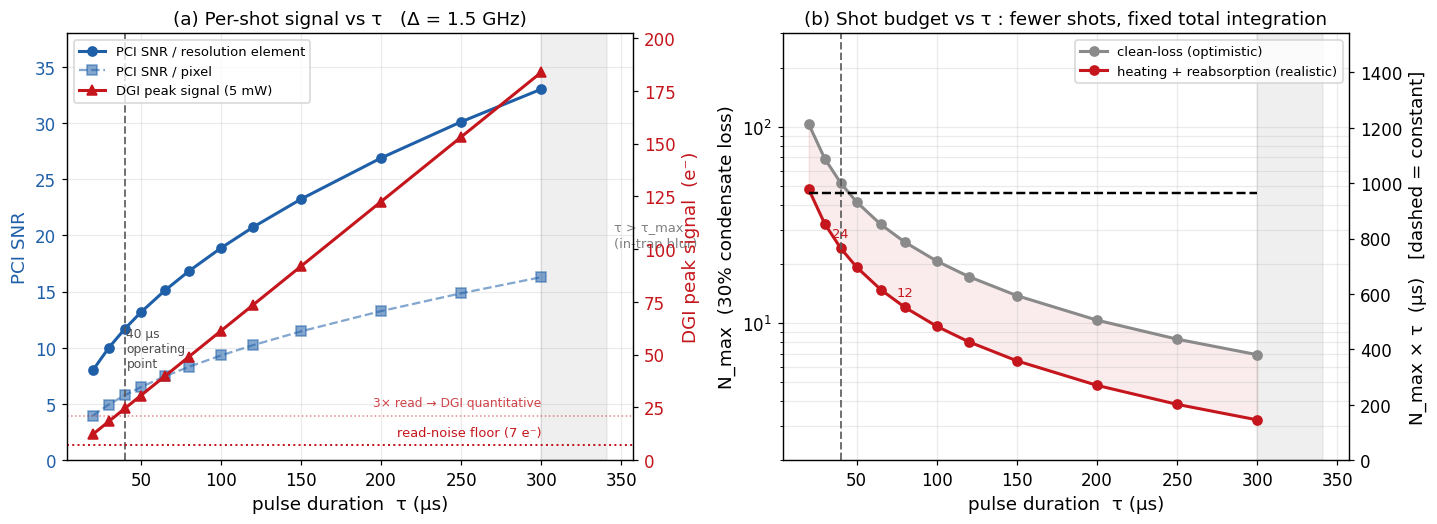

In [17]:
# ===== CELL F: tau sweep — SNR rises, DGI clears the read-noise floor, N_max falls at fixed N_max*tau =====
tau_us = np.array([20,30,40,50,65,80,100,120,150,200,250,300])
Dref, Pref, Pdgi = 1.5e9, 2.0, 5.0
snr_res = np.array([SNR_reselem_sim(Dref,Pref,0,t*1e-6) for t in tau_us])
snr_pix = np.array([SNR_pixel(Dref,Pref,0,t*1e-6)       for t in tau_us])
dgi_e   = np.array([0.016*N_phot_pix(Pdgi,t*1e-6)        for t in tau_us])
nm_real = np.array([Nmax_heating(Dref,Pref,0.30,t*1e-6)  for t in tau_us])
nm_opt  = np.array([Nmax_cleanloss(Dref,Pref,0.30,t*1e-6) for t in tau_us])

fig,(axA,axB)=plt.subplots(1,2,figsize=(13.2,4.9))
tcap=tau_max_now*1e6

# (a) per-shot SNR (left axis) and DGI signal (right axis)
l1,=axA.plot(tau_us,snr_res,'o-',color='#1f5fa8',lw=2,label='PCI SNR / resolution element')
l2,=axA.plot(tau_us,snr_pix,'s--',color='#1f5fa8',lw=1.5,alpha=0.55,label='PCI SNR / pixel')
axA.set_xlabel('pulse duration  τ (µs)'); axA.set_ylabel('PCI SNR',color='#1f5fa8')
axA.tick_params(axis='y',labelcolor='#1f5fa8'); axA.set_ylim(0,max(snr_res)*1.15)
axR=axA.twinx()
l3,=axR.plot(tau_us,dgi_e,'^-',color='#c4161c',lw=2,label='DGI peak signal (5 mW)')
axR.axhline(read_e,color='#c4161c',ls=':',lw=1.3); axR.axhline(3*read_e,color='#c4161c',ls=':',lw=1,alpha=0.5)
axR.set_ylabel('DGI peak signal  (e⁻)',color='#c4161c'); axR.tick_params(axis='y',labelcolor='#c4161c')
axR.set_ylim(0,max(dgi_e)*1.1)
axR.text(tau_us[-1],read_e+3,'read-noise floor (7 e⁻)',ha='right',va='bottom',color='#c4161c',fontsize=8.5)
axR.text(tau_us[-1],3*read_e+3,'3× read → DGI quantitative',ha='right',va='bottom',color='#c4161c',fontsize=8,alpha=0.8)
axA.axvspan(tcap,tau_us[-1],color='gray',alpha=0.12)
axA.text(tcap+4,axA.get_ylim()[1]*0.5,'τ > τ_max\n(in-trap blur)',fontsize=8.5,color='gray')
axA.set_title(f'(a) Per-shot signal vs τ   (Δ = {Dref/1e9:.1f} GHz)')
axA.axvline(40,color='0.35',ls='--',lw=1.3,alpha=0.85)
axA.text(41,max(snr_res)*0.30,'40 µs\noperating\npoint',fontsize=8,color='0.3',va='center')
axA.legend(handles=[l1,l2,l3],fontsize=8.6,loc='upper left'); axA.grid(alpha=0.25)

# (b) shot budget vs tau, with N_max*tau (constant) on twin axis
axB.semilogy(tau_us,nm_opt,'o-',color='#8a8a8a',lw=2,label='clean-loss (optimistic)')
axB.semilogy(tau_us,nm_real,'o-',color='#c4161c',lw=2,label='heating + reabsorption (realistic)')
axB.fill_between(tau_us,nm_real,nm_opt,color='#c4161c',alpha=0.08)
axB.set_xlabel('pulse duration  τ (µs)'); axB.set_ylabel('N_max  (30% condensate loss)')
axB.set_ylim(2,300); axB.grid(alpha=0.25,which='both')
axB2=axB.twinx()
axB2.plot(tau_us,nm_real*tau_us,'k--',lw=1.6)
axB2.set_ylabel('N_max × τ  (µs)   [dashed = constant]'); axB2.set_ylim(0,1.6*np.max(nm_real*tau_us))
axB.axvspan(tcap,tau_us[-1],color='gray',alpha=0.12)
for tx,lab in [(40,'40'),(80,'80')]:
    i=int(np.where(tau_us==tx)[0][0]); axB.annotate(f'{nm_real[i]:.0f}',(tx,nm_real[i]),textcoords='offset points',xytext=(0,7),ha='center',fontsize=8.5,color='#c4161c')
axB.axvline(40,color='0.35',ls='--',lw=1.3,alpha=0.85)
axB.set_title('(b) Shot budget vs τ : fewer shots, fixed total integration')
axB.legend(fontsize=8.6,loc='upper right')
plt.tight_layout(); plt.savefig('fig_tausweep.png',dpi=140,bbox_inches='tight',facecolor='white'); plt.show()

### 12.2 $(\Delta, P, \tau)$ optimisation

Maximise usable non-destructive frames at a target per-shot SNR, subject to $\varphi_x<0.5$ (linear
PCI), $\tau\le\tau_\mathrm{max}$, and the route's power ceiling. Because accumulated SNR is invariant,
*higher* detuning always buys more frames — but at smaller, less-measurable $\varphi$ and outside the
AOM-cascade range, so the practical $\Delta$ is set by calibration and phase measurability
($\varphi_x\sim0.13$–$0.20$), not by sensitivity.

/tmp/ipykernel_598/885871757.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig('fig_optimisation.png',dpi=140,bbox_inches='tight',facecolor='white'); plt.show()


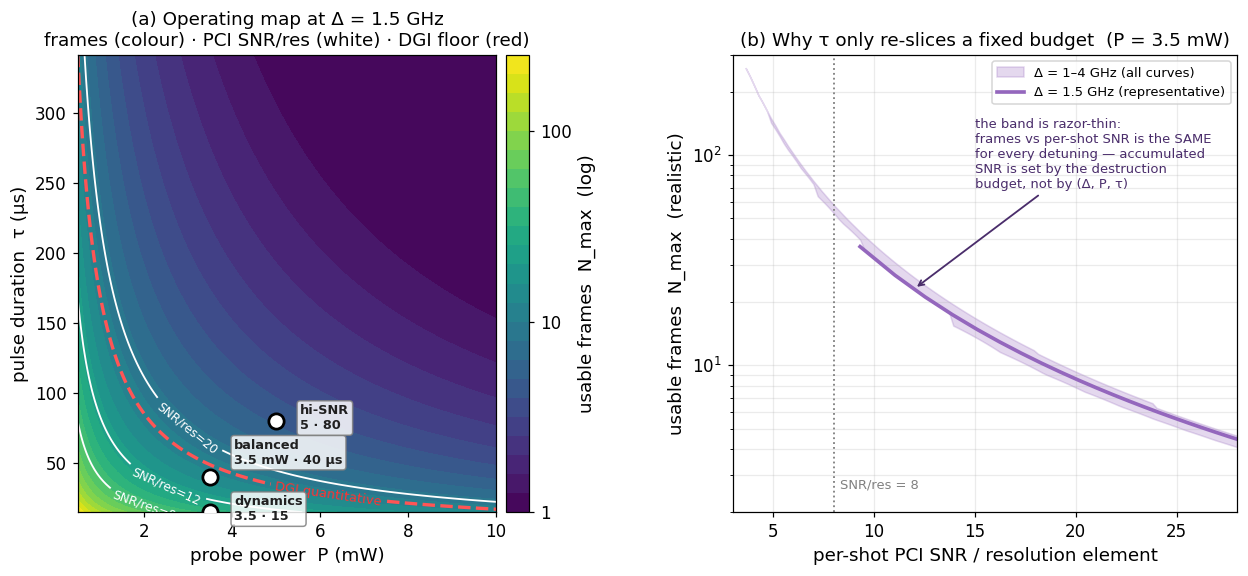

RECOMMENDED OPERATING POINTS  (across-cigar x; realistic heating+reabs budget; 30% condensate loss)
mode                     Δ/GHz  P/mW  τ/µs  phi_x N_max SNR/res SNR/pix DGI/e-
------------------------------------------------------------------------------
balanced (Route A)         1.5   3.5    40  0.203    14    15.7     7.8     17


dynamics: many frames      1.5   3.5    15  0.203    37     9.3     4.6      6
hi-SNR / quant. DGI        1.5   5.0    80  0.203     5    26.9    13.3     49
higher-Δ, more frames      2.5   5.0    40  0.122    27    11.5     5.7     25


max range (beat-lock)      3.0   8.0    40  0.101    25    12.2     6.0     39

Rule of thumb: τ set by the read-noise floor (DGI quantitative for τ >~ 40-50 µs at 3.5-5 mW);
Δ set by calibration range + keeping phi_x measurable (~0.13-0.20); P by the chosen source route.


In [18]:
# ===== CELL H: (Delta, P, tau) optimisation — operating map + invariance frontier + recommendation =====
def _pci_block(Delta_Hz, axis=0, half=1):
    Iimg,_=sim_image(axis, phi_peak(Delta_Hz, n_col[axis]), 'PCI')
    nb=(Ngrid//15)*15; b=Iimg[:nb,:nb].reshape(nb//15,15,nb//15,15).mean(axis=(1,3))
    m=b.shape[0]//2; k=b[m-half:m+half+1,m-half:m+half+1]
    return (k-bg_plate).sum(), k.sum(), k.size
def SNRres_fast(block,P_mW,tau_s):
    S,Sig,n=block; Nd=N_phot_pix(P_mW,tau_s); return S*Nd/np.sqrt(Sig*Nd+n*read_e**2)

fig,(axA,axB)=plt.subplots(1,2,figsize=(13.6,5.4),gridspec_kw=dict(wspace=0.30))

# ---------- (a) operating map at the recommended detuning ----------
Dmap=1.5e9; _blk=_pci_block(Dmap)
Pax=np.linspace(0.5,10,150); Tax=np.linspace(15,tau_max_now*1e6,150); PP,TT=np.meshgrid(Pax,Tax)
NMmap=np.vectorize(lambda P,tu: Nmax_heating(Dmap,P,0.30,tu*1e-6))(PP,TT)
SNmap=np.vectorize(lambda P,tu: SNRres_fast(_blk,P,tu*1e-6))(PP,TT)
DGmap=np.vectorize(lambda P,tu: 0.016*N_phot_pix(P,tu*1e-6))(PP,TT)
im=axA.contourf(PP,TT,np.log10(np.clip(NMmap,1,None)),levels=np.linspace(0,2.4,25),cmap='viridis')
cb=plt.colorbar(im,ax=axA,pad=0.02,ticks=[0,1,2]); cb.set_label('usable frames  N_max  (log)'); cb.set_ticklabels(['1','10','100'])
cs=axA.contour(PP,TT,SNmap,levels=[8,12,20],colors='white',linewidths=1.2)
axA.clabel(cs,fmt='SNR/res=%d',fontsize=8,colors='white',manual=[(2.0,18),(2.5,33),(3.0,76)])
cd=axA.contour(PP,TT,DGmap,levels=[3*read_e],colors='#ff5555',linewidths=2.2,linestyles='dashed')
axA.clabel(cd,fmt='DGI quantitative',fontsize=8.5,colors='#ff3333',manual=[(6.2,28)])
mk=[('balanced\n3.5 mW · 40 µs',3.5,40,(16,16)),('dynamics\n3.5 · 15',3.5,15,(16,2)),('hi-SNR\n5 · 80',5.0,80,(16,2))]
_bb=dict(boxstyle='round,pad=0.25',fc='white',ec='0.5',alpha=0.85)
for lab,P,tu,off in mk:
    axA.plot(P,tu,'o',color='k',ms=10,mfc='white',mew=1.8,zorder=6)
    axA.annotate(lab,(P,tu),xytext=off,textcoords='offset points',fontsize=8.4,fontweight='bold',
                 color='#202020',ha='left',va='center',bbox=_bb,zorder=7)
axA.set_xlabel('probe power  P (mW)'); axA.set_ylabel('pulse duration  τ (µs)')
axA.set_title(f'(a) Operating map at Δ = {Dmap/1e9:.1f} GHz\nframes (colour) · PCI SNR/res (white) · DGI floor (red)')

# ---------- (b) accumulated-SNR invariance: the frames-vs-SNR curve is the same for every detuning ----------
Dscan=np.array([1.0,1.5,2.0,3.0,4.0])*1e9; _bk={D:_pci_block(D) for D in Dscan}
tt=np.linspace(15,tau_max_now*1e6,60)
curves=[]
for D in Dscan:
    sn=np.array([SNRres_fast(_bk[D],3.5,t*1e-6) for t in tt]); nm=np.array([Nmax_heating(D,3.5,0.30,t*1e-6) for t in tt])
    curves.append((sn,nm))
# common SNR grid -> band (min/max N_max across detunings) to show they coincide
sgrid=np.linspace(3,28,120); band=[]
for s in sgrid:
    vals=[np.interp(s,c[0],c[1],left=np.nan,right=np.nan) for c in curves]
    vals=[v for v in vals if np.isfinite(v)]; band.append((min(vals),max(vals)) if vals else (np.nan,np.nan))
band=np.array(band)
axB.fill_between(sgrid,band[:,0],band[:,1],color='tab:purple',alpha=0.25,label='Δ = 1–4 GHz (all curves)')
axB.plot(curves[1][0],curves[1][1],'-',color='tab:purple',lw=2.4,label='Δ = 1.5 GHz (representative)')
axB.set_yscale('log'); axB.set_xlim(3,28); axB.set_ylim(2,300)
axB.axvline(8,color='gray',ls=':',lw=1.2); axB.annotate('SNR/res = 8',(8.3,2.6),fontsize=8.5,color='gray')
axB.annotate('the band is razor-thin:\nframes vs per-shot SNR is the SAME\nfor every detuning — accumulated\nSNR is set by the destruction\nbudget, not by (Δ, P, τ)',
             xy=(12,np.interp(12,curves[1][0],curves[1][1])),xytext=(15,70),fontsize=8.6,color='#4a2d6b',
             arrowprops=dict(arrowstyle='->',color='#4a2d6b',lw=1.2))
axB.set_xlabel('per-shot PCI SNR / resolution element'); axB.set_ylabel('usable frames  N_max  (realistic)')
axB.set_title('(b) Why τ only re-slices a fixed budget  (P = 3.5 mW)')
axB.legend(fontsize=8.6,loc='upper right'); axB.grid(alpha=0.25,which='both')
plt.tight_layout(); plt.savefig('fig_optimisation.png',dpi=140,bbox_inches='tight',facecolor='white'); plt.show()

# ---------- recommended operating points ----------
print("RECOMMENDED OPERATING POINTS  (across-cigar x; realistic heating+reabs budget; 30% condensate loss)")
hdr=f"{'mode':<24}{'Δ/GHz':>6}{'P/mW':>6}{'τ/µs':>6}{'phi_x':>7}{'N_max':>6}{'SNR/res':>8}{'SNR/pix':>8}{'DGI/e-':>7}"
print(hdr); print('-'*len(hdr))
for lab,Dg,P,tus in [("balanced (Route A)",1.5,3.5,40),("dynamics: many frames",1.5,3.5,15),
                     ("hi-SNR / quant. DGI",1.5,5.0,80),("higher-Δ, more frames",2.5,5.0,40),
                     ("max range (beat-lock)",3.0,8.0,40)]:
    D=Dg*1e9; ts=tus*1e-6; nm=Nmax_heating(D,P,0.30,ts); dgi=0.016*N_phot_pix(P,ts)
    print(f"{lab:<24}{Dg:>6.1f}{P:>6.1f}{tus:>6d}{phi_peak(D,n_col[0]):>7.3f}{nm:>6.0f}"
          f"{SNRres_fast(_pci_block(D),P,ts):>8.1f}{SNR_pixel(D,P,0,ts):>8.1f}{dgi:>7.0f}")
print("\nRule of thumb: τ set by the read-noise floor (DGI quantitative for τ >~ 40-50 µs at 3.5-5 mW);")
print("Δ set by calibration range + keeping phi_x measurable (~0.13-0.20); P by the chosen source route.")

### 12.3 Recommendation and revised headline numbers

**Most reasonable combination (default Route A / AOM cascade): $\Delta\approx1.5$ GHz,
$P\approx3.5$ mW, $\tau\approx40\,\mu$s** — about **14 non-destructive frames**, each with PCI
SNR/resolution-element $\approx16$ and DGI $\approx17\,e^-$ (above the read-noise floor, so PCI *and*
DGI are quantitative). This sits at the read-noise knee: long enough for usable DGI, short enough to
keep $\sim$14 timepoints.

* **Dynamics (more timepoints):** $\tau\approx15$–$20\,\mu$s → $\sim$37 frames, PCI-only (DGI floored).
* **High-SNR snapshots / quantitative DGI:** $\tau\approx80\,\mu$s → $\sim$5 bright frames.
* **More frames at the cost of phase size:** $\Delta\approx2.5$ GHz, $P\approx5$ mW, $\tau\approx40\,\mu$s
  → $\sim$27 frames at $\varphi_x=0.12$ (needs the injection-locked or beat-locked source).

**Manual updates.** The PDF manual's "$N_\mathrm{max}\approx140$ shots" figure was the optimistic
clean-loss model at $\tau=15\,\mu$s; at the $\tau\approx40\,\mu$s operating point now used throughout
(§11) the budget **lands in the tens of frames** (clean-loss $\sim$52, realistic heating $\sim$14–24),
so update §1.1, §4, §12 of the manual. Two lab inputs turn the band into a
number: the **ODT trap depth** (sets whether recoils leave or heat) and one measured **loss-vs-shots**
point at a known $(\Delta,P,\tau)$.

---
# Part II — The multi-shot run

Sections 1–12 sized a **single** frame and the closed-form budget $N_\mathrm{max}$. But a
non-destructive run is a *sequence* of frames on the *same* atoms, and that is where the interesting
physics lives. Part II turns the budget into an explicit frame-by-frame simulation and uses it to
answer the questions an experimentalist actually asks: how fast does the condensate fade, what does
the camera see, which detuning to choose, how many atoms are needed, and how to resolve the cloud.

## 13. The multi-shot sequence engine

Every probe pulse scatters $N_\gamma=R_\mathrm{scatt}\,\tau$ photons per atom, so the condensate is
progressively depleted: the Thomas–Fermi cloud shrinks ($R_i\propto N_0^{1/5}$) and the dispersive
phase fades ($\varphi\propto$ column density $\propto N_0^{3/5}$). **Each successive frame is dimmer
and smaller than the last**, and the run ends when the condensate has lost the tolerated fraction.

Two models bracket the truth (§12):

* **heating (realistic).** $E_\mathrm{rec}=359$ nK is below the ODT trap depth, so a recoiled atom
  stays trapped, thermalises, and *heats* a cloud that is only $\sim$22 % condensed; the condensate
  *melts* via $N_0/N_\mathrm{tot}=1-(T/T_c)^3$ as $T$ climbs through
  $E(T)=3(\zeta_4/\zeta_3)k_BT(T/T_c)^3$.
* **clean loss (optimistic).** Each recoil ejects its atom: $N_0(s)=N_0\,e^{-\eta N_\gamma s}$.


In [19]:
# ============================================================================
# 13. MULTI-SHOT SEQUENCE ENGINE
# ============================================================================
#
#  >>>>>>>>>>>>>>>  USER CONTROLS -- EDIT THESE AND RE-RUN 13-17  <<<<<<<<<<<<<<
SEQ_Delta_GHz = 1.5     # detuning                (GHz)   try 1.0, 1.5, 2.5, 3.0
SEQ_P_mW      = 3.5     # probe power / intensity  (mW)   try 2.0, 3.5, 5.0
SEQ_tau_us    = 40.0    # pulse duration           (us)   try 15, 40, 80
SEQ_axis      = 0       # 0 = x across-cigar (resolved w/ TOF),
                        # 1 = y along-cigar (atom-number probe, phase-wrapped @1.5GHz),
                        # 2 = z across-cigar
SEQ_loss_frac = 0.30    # stop run at this CONDENSATE-loss fraction (protocol = 0.30)
SEQ_reabs     = None    # None -> realistic reabs_frac(Delta);  set 0.0 for recoil-only heating
SEQ_max_shots = 400     # safety cap on number of frames
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
SEQ_Delta, SEQ_tau = SEQ_Delta_GHz * 1e9, SEQ_tau_us * 1e-6


def tf_state(N0_now):
    """Thomas-Fermi mu, n_peak, R(x,y,z), peak column density(x,y,z) for a given
    condensate number -- identical formulas to section 4, just re-evaluated as
    atoms are lost."""
    mu_   = 0.5 * (15 * N0_now * a_s / a_ho)**(2/5) * hbar * omega_bar
    npk   = mu_ * m / (4 * np.pi * hbar**2 * a_s)
    R_    = np.sqrt(2 * mu_ / (m * omega**2))
    ncol_ = (4/3) * npk * R_
    return mu_, npk, R_, ncol_


def SNR_pixel_phi(phi, P_mW, axis, tau_s, blur):
    """Realistic per-pixel PCI SNR for an explicit phase value (full transfer
    model, peak intensity, plate-t_p^2 background, fixed axis NA blur).
    Returns NaN if phi >= pi (phase-wrapped: no single-valued linear SNR)."""
    if not (0.0 < phi < np.pi):
        return np.nan
    Iimg = bg_plate + blur * (I_full(phi) - bg_plate)
    Nph  = N_phot_pix(P_mW, tau_s)
    return abs(Iimg - bg_plate) * Nph / np.sqrt(abs(Iimg) * Nph + read_e**2)


def run_sequence(Delta_Hz, P_mW, tau_s, axis=0, loss_frac=0.30,
                 model='heating', reabs=None, max_shots=400):
    """Step through a continuous run frame-by-frame. Frame s sees the cloud
    AFTER s previous probe pulses of destruction (frame 0 = fresh cloud).

    Returns a dict of per-frame arrays: shot index, condensate number N0,
    condensate-loss fraction, temperature T (K, heating only), peak phase, and
    realistic per-pixel SNR. The frame counts reproduce Nmax_heating /
    Nmax_cleanloss (defined in section 12) by construction.
    """
    Ng   = N_scatt(Delta_Hz, P_mW, tau_s)         # photons/atom/shot (cloud-independent)
    blur = blur_axis[axis]                         # ~const: R changes <10% out to 30% loss
    N0_0 = N0                                       # fresh condensate number
    # --- heating bookkeeping: SAME coefficients as Nmax_heating() in section 12 ---
    Tc = Tc_sc
    if reabs is None:
        reabs = reabs_frac(Delta_Hz)
    A_E = 3 * (zeta4 / zeta3) * kB / Tc**3          # per-atom energy coeff: E(T) = A_E * T^4
    dE  = Ng * (1 + reabs) * E_rec                  # per-atom energy deposited per shot
    T   = T_cloud

    out = {key: [] for key in ('shot', 'N0', 'frac', 'T', 'phi', 'snr')}
    s = 0
    while s <= max_shots:
        if model == 'heating':
            N0_now = N_tot_sc * (1 - (T / Tc)**3)
            T_now  = T
        else:                                       # clean-loss (optimistic)
            N0_now = N0_0 * np.exp(-eta_coll * Ng * s)
            T_now  = np.nan
        if N0_now <= 0:
            break
        frac = 1 - N0_now / N0_0
        _, _, _, ncol = tf_state(N0_now)
        phi = phi_peak(Delta_Hz, ncol[axis])
        out['shot'].append(s);   out['N0'].append(N0_now);  out['frac'].append(frac)
        out['T'].append(T_now);  out['phi'].append(phi)
        out['snr'].append(SNR_pixel_phi(phi, P_mW, axis, tau_s, blur))
        if frac >= loss_frac:
            break
        T = (T**4 + dE / A_E)**0.25                 # advance heating by one shot
        s += 1
    return {key: np.asarray(val) for key, val in out.items()}


def accumulate(snr):
    """RMS-accumulated SNR vs frame: sqrt(cumsum(SNR_s^2)). NaN frames (phase-
    wrapped) contribute nothing."""
    return np.sqrt(np.nancumsum(np.where(np.isfinite(snr), np.asarray(snr, float)**2, 0.0)))


# ---- run the user-selected operating point under BOTH models ----
seq_h = run_sequence(SEQ_Delta, SEQ_P_mW, SEQ_tau, SEQ_axis, SEQ_loss_frac, 'heating', SEQ_reabs, SEQ_max_shots)
seq_l = run_sequence(SEQ_Delta, SEQ_P_mW, SEQ_tau, SEQ_axis, SEQ_loss_frac, 'loss',    SEQ_reabs, SEQ_max_shots)

sat  = intensity_at_atoms(SEQ_P_mW) / Isat
Ng0  = N_scatt(SEQ_Delta, SEQ_P_mW, SEQ_tau)
fh   = Nmax_heating(SEQ_Delta, SEQ_P_mW, SEQ_loss_frac, SEQ_tau)
fl   = Nmax_cleanloss(SEQ_Delta, SEQ_P_mW, SEQ_loss_frac, SEQ_tau)
reab = SEQ_reabs if SEQ_reabs is not None else reabs_frac(SEQ_Delta)

print("="*70)
print(f"CONTINUOUS RUN @  Delta={SEQ_Delta_GHz} GHz   P={SEQ_P_mW} mW   tau={SEQ_tau_us:.0f} us"
      f"   axis={'xyz'[SEQ_axis]}")
print("-"*70)
print(f"  intensity at atoms (peak)  : I/Isat = {sat:.3f}")
print(f"  photons / atom / shot      : N_gamma = {Ng0:.2e}   (reabsorption factor {reab:.3f})")
print(f"  initial peak phase         : phi0 = {seq_h['phi'][0]:.3f} rad   ({regime_of(seq_h['phi'][0])})")
print(f"  stop run at                : {SEQ_loss_frac:.0%} condensate loss")
print("-"*70)
print(f"  usable frames to {SEQ_loss_frac:.0%} loss   :  HEATING (realistic) ~{fh:.0f}"
      f"   |   LOSS (optimistic) ~{fl:.0f}")
print(f"  total non-destructive time :  {fh*SEQ_tau_us:.0f} us (heating)   |   {fl*SEQ_tau_us:.0f} us (loss)")
print(f"  Nmax x tau (set by Delta,P):  {fh*SEQ_tau_us:.0f} us   (invariant -- tau only re-slices it)")
print("="*70)


CONTINUOUS RUN @  Delta=1.5 GHz   P=3.5 mW   tau=40 us   axis=x
----------------------------------------------------------------------
  intensity at atoms (peak)  : I/Isat = 0.026
  photons / atom / shot      : N_gamma = 9.27e-03   (reabsorption factor 0.030)
  initial peak phase         : phi0 = 0.203 rad   (linear)
  stop run at                : 30% condensate loss
----------------------------------------------------------------------
  usable frames to 30% loss   :  HEATING (realistic) ~14   |   LOSS (optimistic) ~30
  total non-destructive time :  550 us (heating)   |   1183 us (loss)
  Nmax x tau (set by Delta,P):  550 us   (invariant -- tau only re-slices it)


## 14. Evolution of the run

Four views of the same sequence; the realistic **heating** curve (red) and the optimistic
**clean-loss** curve (blue) bracket every quantity.

* **(a) Condensate depletion.** Surviving condensate vs frame; the right axis (heating) shows $T$
  climbing toward $T_c$ — the mechanism, since the condensate fraction $1-(T/T_c)^3$ collapses as
  $T\!\to\!T_c$, melting the cloud in roughly *half* the frames of clean loss.
* **(b) Phase fades.** $\varphi\propto N_0^{3/5}$ shrinks frame-to-frame; the orange line is the
  linear-PCI ceiling $\varphi=0.5$.
* **(c) Per-frame SNR** declines as the cloud dims and shrinks.
* **(d) Accumulated SNR** $=\sqrt{\sum_s\mathrm{SNR}_s^2}$ **saturates**: once the condensate is gone
  there is no more signal to add. The plateau value — not the per-shot SNR — is the figure of merit
  for a fixed destruction budget, and adding frames beyond $N_\mathrm{max}$ buys nothing.


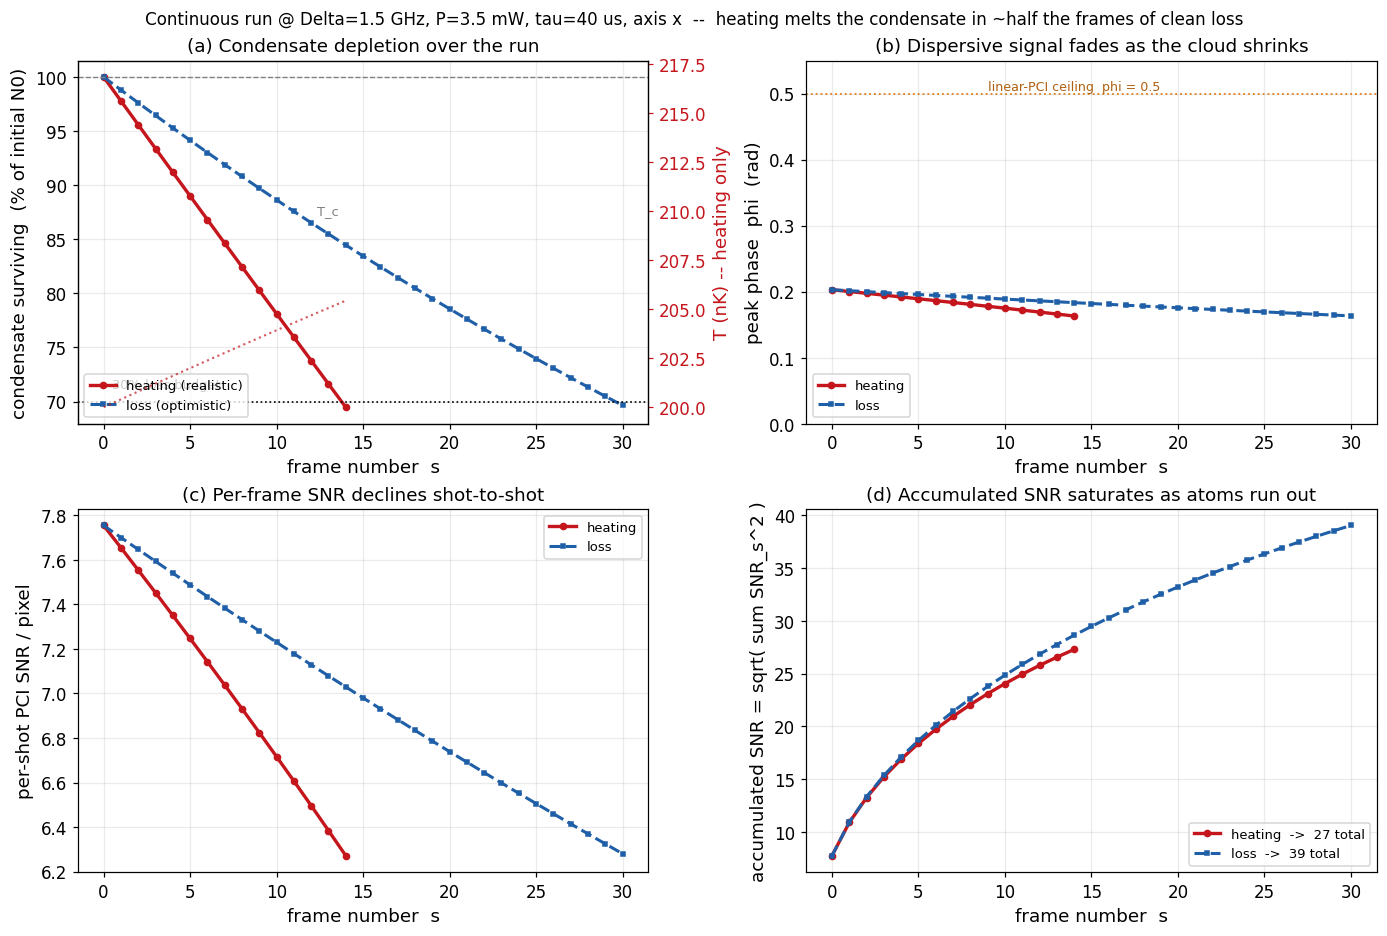

In [20]:
# ---- 14. Evolution of the run: condensate, temperature, phase, SNR ----------
fig, axs = plt.subplots(2, 2, figsize=(12.5, 8.4), constrained_layout=True)

# (a) condensate surviving (%) vs frame, with T (nK) on a twin axis (heating) -----
axA = axs[0, 0]
survH = 100 * (1 - seq_h['frac'])
survL = 100 * (1 - seq_l['frac'])
axA.plot(seq_h['shot'], survH, 'o-', color='#c4161c', lw=2.2, ms=4, label='heating (realistic)')
axA.plot(seq_l['shot'], survL, 's--', color='#1f5fa8', lw=2.0, ms=3, label='loss (optimistic)')
axA.axhline(100 * (1 - SEQ_loss_frac), color='k', ls=':', lw=1.1)
axA.annotate(f'{SEQ_loss_frac:.0%} loss budget', (0.5, 100 * (1 - SEQ_loss_frac) + 1.2), fontsize=8.5)
axA.set_xlabel('frame number  s')
axA.set_ylabel('condensate surviving  (% of initial N0)')
axA.set_title('(a) Condensate depletion over the run')
axA.grid(alpha=0.25)
axA.legend(fontsize=8.6, loc='lower left')
axT = axA.twinx()
axT.plot(seq_h['shot'], seq_h['T'] * 1e9, ':', color='#c4161c', lw=1.4, alpha=0.7)
axT.axhline(Tc_sc * 1e9, color='gray', ls='--', lw=0.9)
axT.annotate('T_c', (seq_h['shot'][-1] * 0.88, Tc_sc * 1e9 - 7), color='gray', fontsize=8.5)
axT.set_ylabel('T (nK) -- heating only', color='#c4161c')
axT.tick_params(axis='y', colors='#c4161c')

# (b) peak phase vs frame -----------------------------------------------------
axB = axs[0, 1]
axB.plot(seq_h['shot'], seq_h['phi'], 'o-', color='#c4161c', lw=2.2, ms=4, label='heating')
axB.plot(seq_l['shot'], seq_l['phi'], 's--', color='#1f5fa8', lw=2.0, ms=3, label='loss')
_phi_top = max(0.55, np.nanmax(np.concatenate([seq_h['phi'], seq_l['phi']])) * 1.15)
axB.set_ylim(0.0, _phi_top)
axB.axhline(0.5, color='#e08020', ls=':', lw=1.2)
axB.text(seq_l['shot'][-1] * 0.30, 0.5, 'linear-PCI ceiling  phi = 0.5',
         color='#b06010', fontsize=8.3, va='bottom', ha='left')
axB.set_xlabel('frame number  s')
axB.set_ylabel('peak phase  phi  (rad)')
axB.set_title('(b) Dispersive signal fades as the cloud shrinks')
axB.grid(alpha=0.25)
axB.legend(fontsize=8.6)

# (c) per-shot SNR vs frame ---------------------------------------------------
axC = axs[1, 0]
axC.plot(seq_h['shot'], seq_h['snr'], 'o-', color='#c4161c', lw=2.2, ms=4, label='heating')
axC.plot(seq_l['shot'], seq_l['snr'], 's--', color='#1f5fa8', lw=2.0, ms=3, label='loss')
axC.set_xlabel('frame number  s')
axC.set_ylabel('per-shot PCI SNR / pixel')
axC.set_title('(c) Per-frame SNR declines shot-to-shot')
axC.grid(alpha=0.25)
axC.legend(fontsize=8.6)

# (d) accumulated SNR vs frame ------------------------------------------------
axD = axs[1, 1]
accH = accumulate(seq_h['snr'])
accL = accumulate(seq_l['snr'])
axD.plot(seq_h['shot'], accH, 'o-', color='#c4161c', lw=2.2, ms=4,
         label=f'heating  ->  {accH[-1]:.0f} total')
axD.plot(seq_l['shot'], accL, 's--', color='#1f5fa8', lw=2.0, ms=3,
         label=f'loss  ->  {accL[-1]:.0f} total')
axD.set_xlabel('frame number  s')
axD.set_ylabel('accumulated SNR = sqrt( sum SNR_s^2 )')
axD.set_title('(d) Accumulated SNR saturates as atoms run out')
axD.grid(alpha=0.25)
axD.legend(fontsize=8.6, loc='lower right')

fig.suptitle(f"Continuous run @ Delta={SEQ_Delta_GHz} GHz, P={SEQ_P_mW} mW, tau={SEQ_tau_us:.0f} us, "
             f"axis {'xyz'[SEQ_axis]}  --  heating melts the condensate in ~half the frames of clean loss",
             fontsize=11)
plt.savefig('fig_sequence_evolution.png', dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


## 15. The cloud fading on camera

The curves are abstract; here is what the *camera* sees. Using the full Fourier-optics chain of §7
(finite-NA pupil, phase plate on the carrier, binning to camera pixels, $\mathrm{QE}=0.40$, $7\,e^-$
read noise), we render the PCI frame at the **start, middle and end** of the heating run, each with
its *current* depleted condensate — so both the phase contrast and the Thomas–Fermi radii shrink as
the run proceeds. The dispersive PCI peak visibly flattens and narrows: atom loss made concrete.


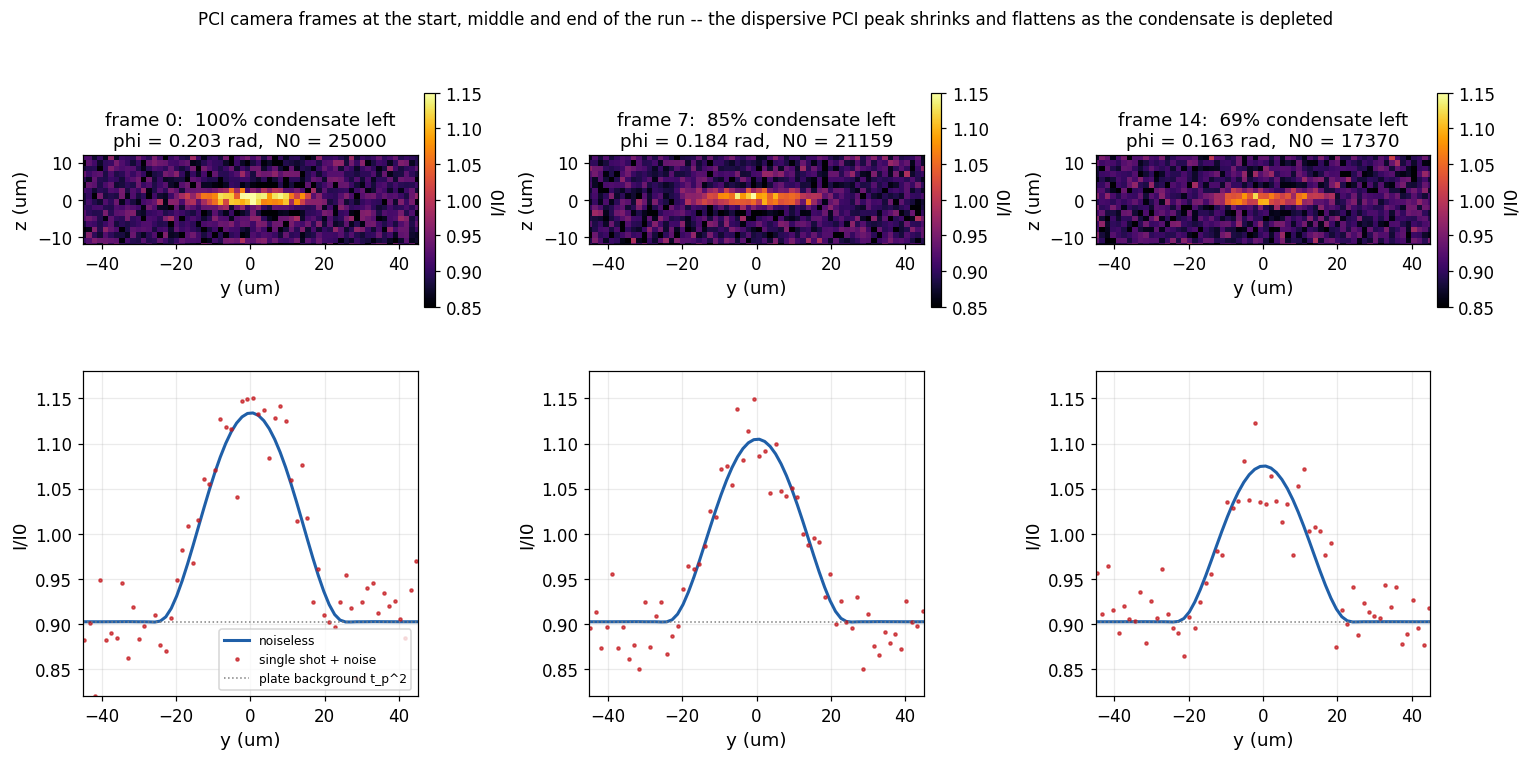

In [21]:
# ---- 15. The cloud fading on camera: PCI frames across the run (heating model)
def sim_image_state(axis, phi_val, R_state, mode='PCI', OD=4.0):
    """Same Fourier-optics propagation as section 7's sim_image(), but with the
    Thomas-Fermi radii supplied explicitly so the cloud can SHRINK as N0 falls."""
    plane = [i for i in range(3) if i != axis]
    prof  = np.maximum(0, 1 - GA**2 / R_state[plane[0]]**2 - GB**2 / R_state[plane[1]]**2)**1.5
    Esc   = np.fft.ifft2(np.fft.fft2(np.exp(1j * phi_val * prof) - 1) * pupil)
    if   mode == 'PCI':  E = t_p * np.exp(1j * theta) + Esc
    elif mode == 'DGI':  E = 10**(-OD/2) + Esc
    else:                E = 1 + Esc
    return np.abs(E)**2


def camera_from_image(Iratio, P_mW, tau_s):
    """Bin to camera pixels (15 grid cells = one object pixel) and add Poisson
    photon noise + Gaussian read noise -- identical recipe to section 7.4."""
    nb = (Ngrid // 15) * 15
    binned = Iratio[:nb, :nb].reshape(nb // 15, 15, nb // 15, 15).mean(axis=(1, 3))
    Nd = N_phot_pix(P_mW, tau_s)
    counts = rng.poisson(np.clip(binned, 0, None) * Nd) + rng.normal(0, read_e, binned.shape)
    return counts / Nd, binned


# pick three frames along the heating run: start, middle, last
Slast = len(seq_h['shot']) - 1
frame_idx = sorted(set([0, max(1, Slast // 2), Slast]))
ext = [-FOV/2 * 1e6, FOV/2 * 1e6, -FOV/2 * 1e6, FOV/2 * 1e6]
nbc = Ngrid // 15
ycam = (np.arange(nbc) - nbc // 2 + 0.5) * pix_obj * 1e6
mid = nbc // 2

ncols = len(frame_idx)
fig, axs = plt.subplots(2, ncols, figsize=(4.6 * ncols, 6.8), constrained_layout=True)
if ncols == 1:
    axs = axs.reshape(2, 1)

for col, fi in enumerate(frame_idx):
    _, _, Rst, _ = tf_state(seq_h['N0'][fi])
    phi_fi = seq_h['phi'][fi]
    Iimg = sim_image_state(SEQ_axis, phi_fi, Rst, 'PCI')
    cam, binned = camera_from_image(Iimg, SEQ_P_mW, SEQ_tau)

    im = axs[0, col].imshow(cam, extent=ext, origin='lower', cmap='inferno', vmin=0.85, vmax=1.15)
    axs[0, col].set_xlim(-45, 45)
    axs[0, col].set_ylim(-12, 12)
    axs[0, col].set_title(f"frame {fi}:  {100*(1-seq_h['frac'][fi]):.0f}% condensate left\n"
                          f"phi = {phi_fi:.3f} rad,  N0 = {seq_h['N0'][fi]:.0f}")
    axs[0, col].set_xlabel('y (um)')
    axs[0, col].set_ylabel('z (um)')
    plt.colorbar(im, ax=axs[0, col], fraction=0.032, pad=0.02, label='I/I0')

    axs[1, col].plot(ycam, binned[mid], color='#1f5fa8', lw=2, label='noiseless')
    axs[1, col].plot(ycam, cam[mid], '.', color='#c4161c', ms=4, alpha=0.7, label='single shot + noise')
    axs[1, col].axhline(bg_plate, color='gray', ls=':', lw=1, label='plate background t_p^2')
    axs[1, col].set_xlim(-45, 45)
    axs[1, col].set_ylim(0.82, 1.18)
    axs[1, col].set_xlabel('y (um)')
    axs[1, col].set_ylabel('I/I0')
    axs[1, col].grid(alpha=0.25)
    if col == 0:
        axs[1, col].legend(fontsize=8)

fig.suptitle("PCI camera frames at the start, middle and end of the run -- the dispersive PCI peak "
             "shrinks and flattens as the condensate is depleted", fontsize=11)
plt.savefig('fig_sequence_frames.png', dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


## 16. Detuning sweep: the SNR–destruction trade-off

This is the central design trade-off of dispersive imaging, and it reproduces the structure of K24
Fig. 4. **Figure 1** establishes *which* imaging regime applies and *where* the usable window sits;
**Figure 2** runs the full detuning sweep as a 100-image-per-detuning experiment.

**The sweep (Fig. 2).** This study deliberately uses a short 15 µs pulse — shorter than the 40 µs operating baseline of §11–§12 — so the low-detuning destruction plays out *within* the 100-frame window and the gradient is visible. For each detuning we run a fixed 100-image sequence (heating model) and record
the per-image SNR; stacking the rows gives the SNR-vs-(detuning, image) map, and four representative
detunings are rendered as strips of consecutive in-trap PCI frames. The result is the Fig.-4 picture:
a **bright but instantly-destroyed tongue at low detuning** (large signal, tiny $N_\mathrm{max}$),
grading into **dim signal that survives all 100 frames at high detuning** (small signal, large
$N_\mathrm{max}$). The accumulated SNR is nearly the same along the sweep — §12's invariance made
visible. *Practical reading:* pick low detuning for a few high-contrast frames of fast dynamics, high
detuning for a long, gently-sampled run. (SNR is single-shot per-pixel, not the region-integrated,
multi-set value of the source figure.)


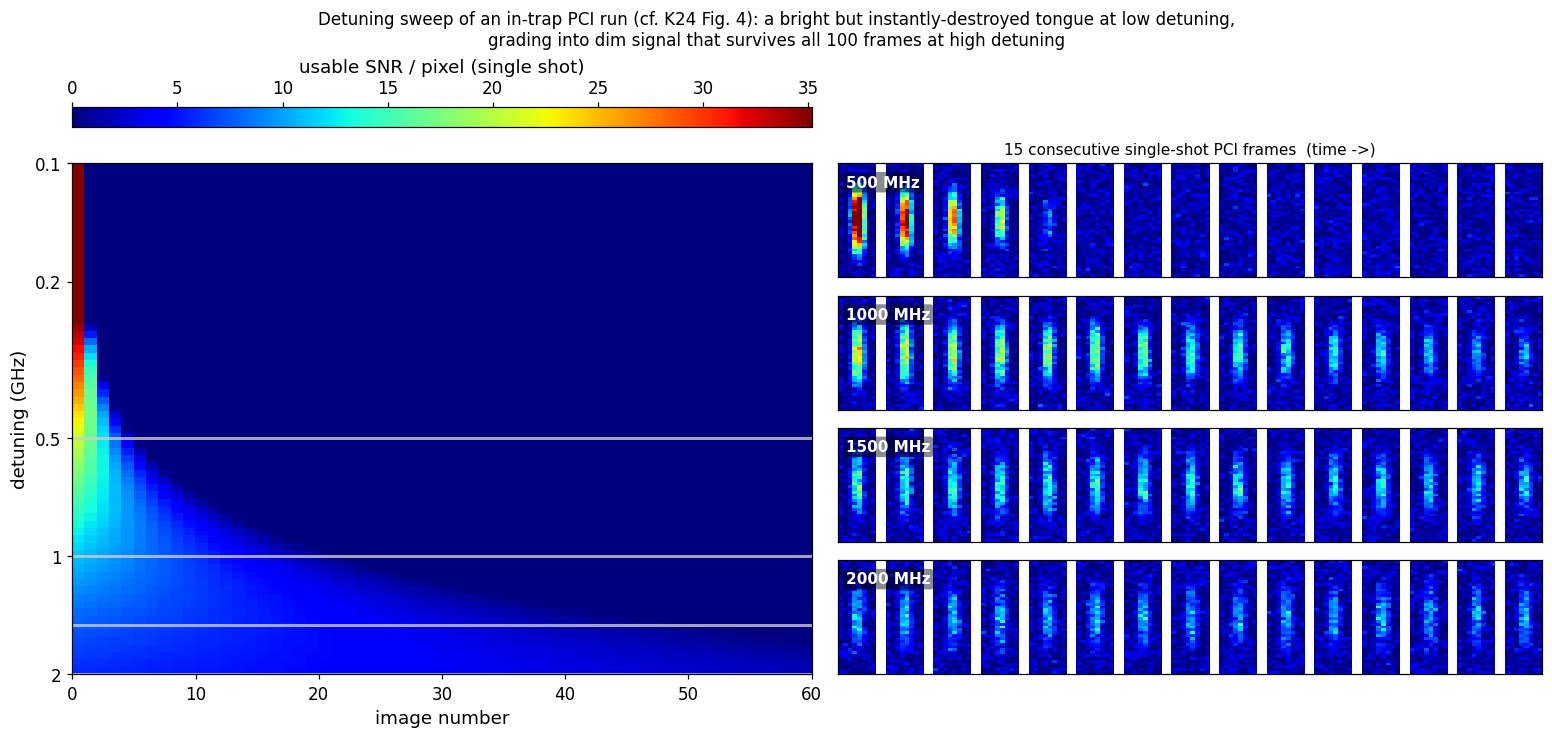

In [22]:
# ============================================================================
# 16. DETUNING SWEEP: THE SNR-DESTRUCTION TRADE-OFF  (cf. K24 Fig. 4)
#     + the absorption<->dispersion crossover that bounds the usable window
# ============================================================================

#  >>>>>  controls for this study (independent of the section-13 controls)  <<<<<
MAP_P_mW   = 3.5      # probe power (mW) -- low/short so the low-detuning end dies fast
MAP_tau_us = 40.0     # pulse duration (us)
MAP_axis   = 0        # across cigar (resolves the transverse cigar shape)
N_IMAGES   = 60      # images per detuning (as in the paper)
strip_dets = [0.5, 1.0, 1.5, 2.0]   # detunings shown as image strips (GHz)
n_strip    = 15       # consecutive frames per strip
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
MAP_tau = MAP_tau_us * 1e-6
blurM   = blur_axis[MAP_axis]
nc0     = n_col[MAP_axis]            # fresh-cloud peak column density (condensate)

# ---- unified single-shot imaging SNR, valid from resonance to far detuning ----
def snr_abs_pix(D, ncol, P, tau_s):
    """Resonant-absorption-imaging SNR: signal is the optical density, with shot+read
    noise on both the with-atom frame (transmits e^-OD) and the light frame."""
    OD = sigma0 * ncol / (1 + delta_of(D)**2)
    N  = N_phot_pix(P, tau_s); Na = N * np.exp(-OD)
    var = (Na + read_e**2) / Na**2 + (N + read_e**2) / N**2
    return OD / np.sqrt(var), OD

def snr_pci_pix(D, ncol, P, tau_s, blur):
    """Dispersive PCI SNR with absorption folded into the complex transmission
    t = exp(i*phi - OD/2) -- so it stays correct as the probe approaches resonance."""
    d = delta_of(D); phi = sigma0 * ncol / 2 * d / (1 + d**2); OD = sigma0 * ncol / (1 + d**2)
    I = abs(t_p * np.exp(1j*theta) + (np.exp(1j*phi - OD/2) - 1))**2
    I = bg_plate + blur * (I - bg_plate); N = N_phot_pix(P, tau_s)
    return abs(I - bg_plate) * N / np.sqrt(abs(I) * N + read_e**2), phi

def usable_snr(D, ncol, P, tau_s, blur):
    """Best achievable single-shot SNR at this detuning: PCI where it is single-valued
    (phi < pi), otherwise resonant absorption."""
    sa, OD  = snr_abs_pix(D, ncol, P, tau_s)
    sp, phi = snr_pci_pix(D, ncol, P, tau_s, blur)
    return max(sp if phi < np.pi else 0.0, sa), phi, OD, sa, sp, (phi < np.pi)

# ---- frame-0 signal vs detuning, decomposed (the crossover) ----
D_ax = np.logspace(np.log10(0.04), np.log10(4.0), 220)
rows = [usable_snr(D*1e9, nc0, MAP_P_mW, MAP_tau, blurM) for D in D_ax]
best = np.array([r[0] for r in rows]); phiA = np.array([r[1] for r in rows])
ODA  = np.array([r[2] for r in rows]); saA  = np.array([r[3] for r in rows])
spA  = np.array([r[4] for r in rows]); valA = np.array([r[5] for r in rows], bool)
D_wrap = D_ax[np.argmin(np.abs(phiA - np.pi))]
D_od1  = D_ax[np.argmin(np.abs(ODA - 1.0))]
D_peak = D_ax[np.argmax(best)]

# ---- depleting per-image SNR over a fixed run (fills the map) ----
def usable_curve(D, n_images):
    """Per-image usable SNR over a fixed N-image run as the condensate depletes
    (heating model); decays to ~0 once the BEC is gone."""
    Ng = N_scatt(D, MAP_P_mW, MAP_tau); Tc = Tc_sc; A_E = 3*(zeta4/zeta3)*kB/Tc**3
    dE = Ng*(1+reabs_frac(D))*E_rec; T = T_cloud; snr = np.zeros(n_images)
    for s in range(n_images):
        fc = max(N_tot_sc*(1-(T/Tc)**3), 0.0) / N0
        snr[s] = usable_snr(D, fc*nc0, MAP_P_mW, MAP_tau, blurM)[0]
        T = (T**4 + dE/A_E)**0.25
    return snr

def make_strip(Delta_GHz, n_frames):
    """Concatenate n_frames consecutive single-shot PCI camera frames (vertical
    cigars) into one strip; the condensate depletes frame-to-frame (uses section 15)."""
    D = Delta_GHz*1e9; Ng, Tc = N_scatt(D, MAP_P_mW, MAP_tau), Tc_sc
    A_E = 3*(zeta4/zeta3)*kB/Tc**3; dE = Ng*(1+reabs_frac(D))*E_rec; T = T_cloud
    yhw = int(round(30e-6/pix_obj)); zhw = int(round(6e-6/pix_obj)); c = (Ngrid//15)//2
    sep = np.full((2*yhw, 2), np.nan); cols = []
    for s in range(n_frames):
        N0n = max(N_tot_sc*(1-(T/Tc)**3), 0.0)
        if N0n > 0:
            _, _, Rst, ncol = tf_state(N0n)
            Iimg = sim_image_state(MAP_axis, phi_peak(D, ncol[MAP_axis]), Rst, 'PCI')
        else:
            Iimg = np.full((Ngrid, Ngrid), bg_plate)
        cam, _ = camera_from_image(Iimg, MAP_P_mW, MAP_tau)
        cols.append(cam.T[c-yhw:c+yhw, c-zhw:c+zhw] - bg_plate)
        if s < n_frames-1: cols.append(sep)
        T = (T**4 + dE/A_E)**0.25
    return np.hstack(cols)

# ---- build the map (to resonance) + the four strips ----
det_lo, det_hi = 0.1, 2.0
det_axis = np.logspace(np.log10(det_lo), np.log10(det_hi), 70)
snr_map = np.array([usable_curve(D*1e9, N_IMAGES) for D in det_axis])
strips  = {D: make_strip(D, n_strip) for D in strip_dets}

# ---- FIGURE 2: the Fig.4 reproduction (map + image strips) ----
fig = plt.figure(figsize=(14, 6.6), constrained_layout=True)
gs = fig.add_gridspec(len(strip_dets), 2, width_ratios=[1.05, 1.0])
axMap = fig.add_subplot(gs[:, 0])
im = axMap.imshow(snr_map, aspect='auto', extent=[0, N_IMAGES, np.log10(det_hi), np.log10(det_lo)],
                  cmap='jet', vmin=0, vmax=np.percentile(snr_map, 99.5))
yt = [0.1, 0.2, 0.5, 1.0, 2.0]; axMap.set_yticks(np.log10(yt)); axMap.set_yticklabels([f'{v:g}' for v in yt])
for D in strip_dets: axMap.axhline(np.log10(D), color='0.8', lw=2.0, alpha=0.8)
axMap.set_xlabel('image number'); axMap.set_ylabel('detuning (GHz)')
cb = fig.colorbar(im, ax=axMap, location='top', fraction=0.05, pad=0.03, aspect=38)
cb.set_label('usable SNR / pixel (single shot)')
smax = max(np.nanpercentile(s, 99.5) for s in strips.values())
for i, D in enumerate(strip_dets):
    axS = fig.add_subplot(gs[i, 1])
    axS.imshow(strips[D], aspect='auto', cmap='jet', vmin=-0.02, vmax=smax, interpolation='nearest', origin='lower')
    axS.set_xticks([]); axS.set_yticks([])
    axS.text(0.012, 0.90, f'{int(round(D*1000))} MHz', transform=axS.transAxes, color='white',
             fontsize=10, va='top', ha='left', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.18', fc='black', ec='none', alpha=0.45))
    if i == 0: axS.set_title(f'{n_strip} consecutive single-shot PCI frames  (time ->)', fontsize=10)
fig.suptitle('Detuning sweep of an in-trap PCI run (cf. K24 Fig. 4): a bright but instantly-destroyed tongue '
             'at low detuning,\ngrading into dim signal that survives all 100 frames at high detuning', fontsize=11)
plt.savefig('fig_detuning_map.png', dpi=140, facecolor='white'); plt.show()


---
# Part III --- Faraday imaging

## 17. Faraday (polarization-rotation) imaging [new]

Sections 5-16 built two dispersive modes, PCI and DGI, both of which read out the **scalar**
phase shift $\varphi$ that a far-detuned probe accumulates from the atomic density -- contrast is
generated by manipulating the *carrier* at the Fourier plane (a phase dot for PCI, a beam block
for DGI). **Faraday imaging** is a third, complementary dispersive technique: it reads out a
**polarization rotation** rather than a phase shift, needs no Fourier-plane optic at all, and is
sensitive to the atomic *spin* rather than directly to the density. It is a natural addition here
because atoms optically pumped into the stretched ground sublevel before the probe pulse present
exactly the spin-polarized column the effect needs, and both detection schemes compared below have
been demonstrated at the single-cloud dispersive-imaging level cited throughout this notebook
(Gajdacz et al. 2013; Kaminski et al. 2012 -- full references in the closing section).

### 17.1 Physics: rotation from the vector polarizability
A linearly polarized probe along $\hat x$ is an equal coherent superposition of the two circular
polarizations, $\hat\epsilon_\pm=\mp(\hat x\pm i\hat y)/\sqrt2$. If the atoms are spin-polarized
along the probe axis, the two circular components couple to *different* Clebsch-Gordan-weighted
transition strengths from that stretched state -- the **vector polarizability** -- so each picks
up its own dispersive phase, $\varphi_\pm$, from the *same* off-resonant two-level physics already
built in §5 (no real Zeeman splitting of the line needs to be resolved for this mechanism).
Recombining the two components after the cloud, the field returns to a linear polarization
**rotated** by
$$\theta_F=\frac{\varphi_+-\varphi_-}{2},$$
with the common phase $(\varphi_++\varphi_-)/2$ left over as an unobservable overall phase (Jones
calculus; worked through in the code comments below). Because both circular components still see
the identical dispersive lineshape of §5.1 and only their *coupling strength* differs (not
their detuning), the peak rotation angle has **exactly the same lineshape as the scalar phase**,
scaled by a dimensionless vector-coupling factor $\kappa_F$:
$$\theta_{F,\mathrm{peak}}(\Delta)=\kappa_F\,\varphi_\mathrm{peak}(\Delta).$$
**[TBD]** $\kappa_F$ depends on the actual Clebsch-Gordan coefficients of the 401 nm
$^{166}$Er transition from the stretched sublevel, which are not in hand for this notebook;
$\kappa_F=1$ below is the idealised bound for a fully-differentiated cycling/non-cycling pair of
$\sigma^\pm$ transitions -- the same "verify before use" status as `QE_cam`, `read_e` in §2 --
and should be replaced with a measured or computed value before these numbers feed a real shot
budget.

### The physical picture: why unequal σ± phases *rotate* the polarization [added]

A linearly polarized probe is an equal superposition of the two circular polarizations,
$\hat x = (\hat\epsilon_+ + \hat\epsilon_-)/\sqrt2$ — two components that rotate in *opposite*
senses. At any instant they add up to a line: the polarization axis.

Passing through the spin-polarized cloud, the two components couple to the atoms with very
different strength (stretched-state Clebsch–Gordan weights **1** vs **1/91** for $\sigma^-$ vs
$\sigma^+$ at $m_J = -6$ here), so they accumulate *different* dispersive phases. Writing the
differential phase as $\pm\theta_F$,

$$\mathbf{E}_{\text{out}} \;\propto\; e^{+i\theta_F}\hat\epsilon_+ + e^{-i\theta_F}\hat\epsilon_-
\;=\; \cos\theta_F\,\hat x \;-\; \sin\theta_F\,\hat y ,$$

which is still **linear**, but with its axis **rotated by $\theta_F$**. The magnitude is unchanged
($|\mathbf{E}_{\text{out}}| = 1$), so — exactly like the scalar phase of the phasor picture — a pure
rotation carries no intensity change: it is invisible until an analyzer (a crossed polarizer, or the
dual-port PBS) projects it onto an axis and converts angle into brightness.

Because $\theta_F$ is proportional to the column density, **an image of the polarization angle is an
image of the cloud** — which is what the simulation below computes and reads out.

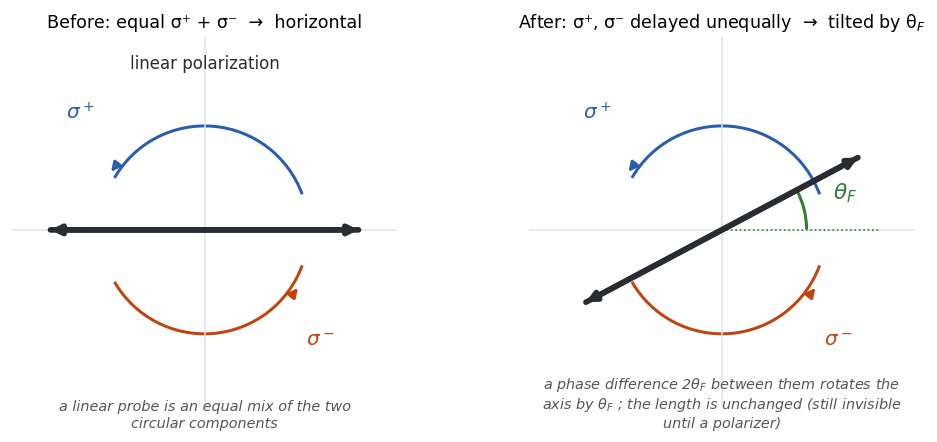


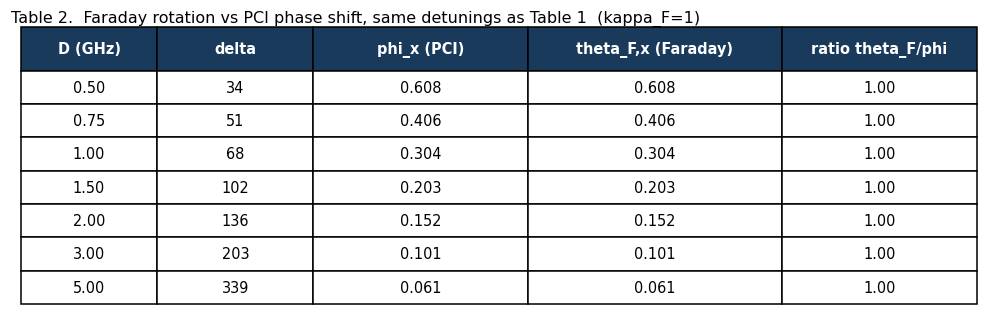

theta_F and phi share the same delta/(1+delta^2) lineshape -> the ratio column is exactly kappa_F=1.0 at every detuning (a direct check on the implementation above).


In [23]:
# ============================================================================
# 17.1 FARADAY ROTATION ANGLE -- same dispersive lineshape as the scalar phase (Sec. 5),
#      scaled by the vector-coupling factor kappa_F
# ============================================================================
#  >>>>>  kappa_F is a PLACEHOLDER pending Er atomic-structure input -- see markdown above  <<<<<
kappa_F = 1.0    # [TBD/rev] vector-polarizability fraction for the stretched-state 401 nm
                 # cycling transition; kappa_F=1 is the idealised maximal-coupling bound.
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

def theta_F_peak(Delta_Hz, n_col_peak):
    """Peak Faraday-rotation angle (rad): identical dispersive lineshape to phi_peak (Sec. 5),
    scaled by kappa_F. We isolate the pure-rotation observable (phi_+ = +theta_F, phi_- = -theta_F),
    i.e. a fully spin-polarized column with the small common-mode scalar phase neglected."""
    return kappa_F * phi_peak(Delta_Hz, n_col_peak)

# ---- Table 2: rotation angle vs phase shift at the same detunings as Table 1 ----
fig, ax = plt.subplots(figsize=(9.2, 3.0)); ax.axis('off')
col_labels = ['D (GHz)', 'delta', 'phi_x (PCI)', 'theta_F,x (Faraday)', 'ratio theta_F/phi']
rows = []
for Dg in detunings_GHz:
    d = delta_of(Dg*1e9)
    px = phi_peak(Dg*1e9, n_col[0]); tx = theta_F_peak(Dg*1e9, n_col[0])
    rows.append([f'{Dg:.2f}', f'{d:.0f}', f'{px:.3f}', f'{tx:.3f}', f'{tx/px:.2f}'])
tb = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center',
              colWidths=[.14,.16,.22,.26,.20])
tb.auto_set_font_size(False); tb.set_fontsize(9.5)
for (i,j),cl in tb.get_celld().items():
    cl.set_height(0.17 if i==0 else 0.13)
    if i==0: cl.set_facecolor('#1a3a5c'); cl.set_text_props(color='white', weight='bold')
ax.set_title('Table 2.  Faraday rotation vs PCI phase shift, same detunings as Table 1  (kappa_F=1)',
             fontsize=10.5, pad=10, loc='left')
plt.tight_layout(); plt.show()
print(f"theta_F and phi share the same delta/(1+delta^2) lineshape -> the ratio column is exactly "
      f"kappa_F={kappa_F} at every detuning (a direct check on the implementation above).")

### 17.2 Two detection schemes, and how the imaging simulation differs from PCI/DGI
No Fourier-plane optic is needed for Faraday contrast, so the "carrier vs. scattered field" split
of §7.1 is irrelevant here; instead we need the *full* NA-limited field (carrier and scattered
together -- the "clear aperture" case already built for the RAI/clear branch of `sim_image` in
§7.3) independently for each circular component, then recombine into linear polarization and
analyse with real-space polarization optics placed after the imaging lens.

**(a) Dark-field Faraday** (Gajdacz et al. 2013): the analyzer is a polarizer **crossed** with the
input polarization, so with no rotation the port is perfectly extinguished (a true dark field, in
the same spirit as DGI's beam block). A small rotation opens up a transmitted intensity
$$I_\mathrm{dark}/I_0=\sin^2\theta_F\;\xrightarrow{\theta_F\ll1}\;\theta_F^2,$$
quadratic in $\theta_F$ -- background-free, but only a small fraction of the light reaches the
detector for a small rotation, and (unlike DGI's opaque stop, which can be made essentially
perfectly absorbing) a real polarizer's finite extinction ratio ($\sim10^{-4}$-$10^{-6}$ in
practice) sets a leakage floor that DGI's stop does not have to contend with.

**(b) Dual-port Faraday** (Kaminski et al. 2012): a polarizing beam splitter at $45\degree$ to the
input sends the light to **two** ports/cameras, each seeing close to half the light when
$\theta_F=0$. The normalised difference is *linear* in the rotation, and common-mode
probe-intensity noise cancels in the ratio:
$$S\equiv\frac{I_v-I_u}{I_v+I_u}=\sin(2\theta_F)\;\xrightarrow{\theta_F\ll1}\;2\theta_F.$$
Because $S$ uses (almost) all the photons and is linear, its shot-noise-limited SNR takes exactly
the form of the ideal PCI SNR of §8.1, $\mathrm{SNR}=2\theta_F\sqrt{N_\mathrm{phot}}$ -- but
*without* the phase-plate transmission penalty $t_p<1$ that dims PCI's carrier, and with
common-mode noise rejected as a bonus. §17.3 makes this comparison quantitative.

Both formulas fall out of the same short calculation: write $\hat x=(\hat\epsilon_--\hat\epsilon_+)/\sqrt2$,
propagate each circular component through its own dispersive phase $e^{i\varphi_\pm}$, and
recombine -- worked through as code comments in `sim_faraday_fields` below. The two detection
schemes differ only in which linear-polarization analyzer axis is used, not in the atom-light
interaction itself, so both can be simulated from the same pair of NA-limited fields.

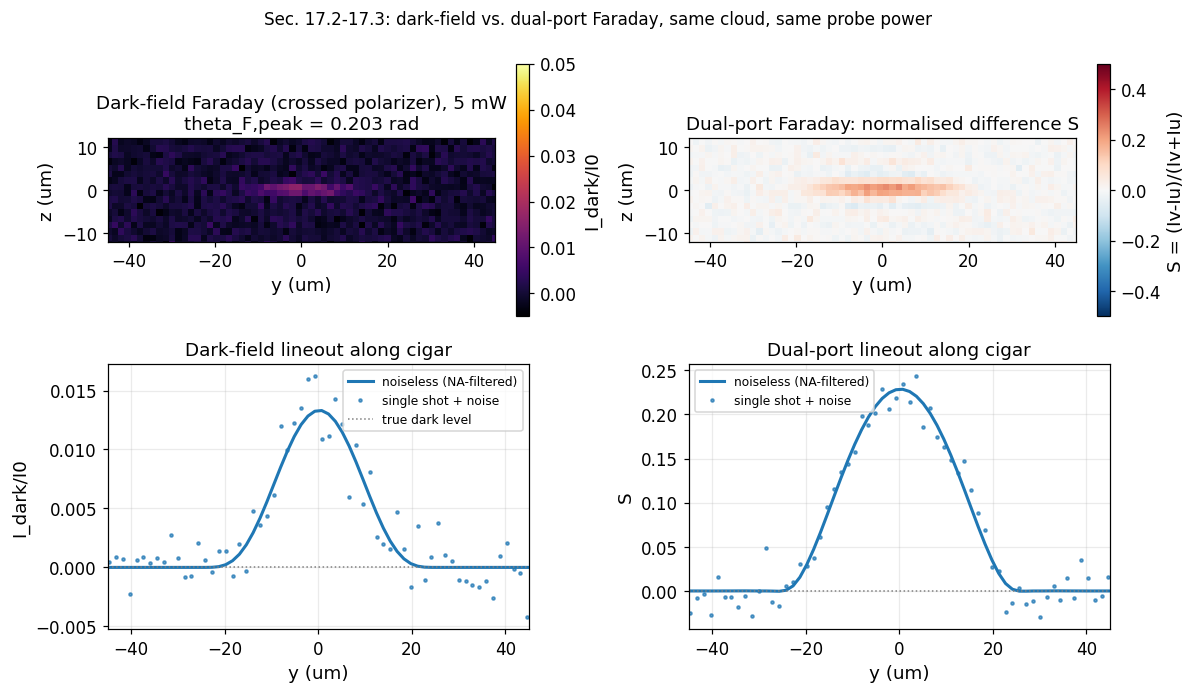

Dark-field peak signal : 0.0133 I0  (51.0 e- at the peak pixel)
Dual-port peak |S|     : 0.2285  (idealised point-formula 2*theta_F = 0.4058, diluted by the same NA blur that acts on PCI/DGI)


In [24]:
# ============================================================================
# 17.2 / 17.3  IMAGING SIMULATION: NA-limited sigma+/sigma- fields, recombined into (Ex,Ey)
# ============================================================================
def sim_faraday_fields(axis, theta_F_val):
    """NA-limited complex field just after the imaging system, separately for the two circular
    polarizations, recombined into the linear (x,y) basis.

    Derivation (Jones calculus, input polarization along x, absorption neglected as in Sec. 5):
      x-hat = (eps_- - eps_+)/sqrt(2)   [eps_+/- = circular basis vectors]
    Each component propagates through the SAME NA-limited system as sim_image()'s 'clear' branch
    (Sec. 7.3), picking up its own phase +theta_F / -theta_F (pure rotation -- Sec. 17.1 neglects
    the small common-mode scalar phase of a fully stretched-state sample). Writing P[.] for the
    NA-limited propagation (fft -> pupil -> ifft):
      E_x = ( P[e^{+i theta_F}] + P[e^{-i theta_F}] ) / 2
      E_y = ( P[e^{+i theta_F}] - P[e^{-i theta_F}] ) * i / 2
    In the infinite-NA (pupil=1) limit this collapses to the exact textbook result
    E_x=cos(theta_F), E_y=-sin(theta_F): a pure rotation of the input polarization, verified
    numerically to machine precision while developing this section.
    """
    plane = [i for i in range(3) if i != axis]
    prof = _tf_profile(R[plane[0]], R[plane[1]])
    Pp = 1 + np.fft.ifft2(np.fft.fft2(np.exp( 1j*theta_F_val*prof) - 1) * pupil)
    Pm = 1 + np.fft.ifft2(np.fft.fft2(np.exp(-1j*theta_F_val*prof) - 1) * pupil)
    Ex, Ey = (Pp + Pm)/2, 1j*(Pp - Pm)/2
    return Ex, Ey

def faraday_maps(Delta_Hz, axis=0):
    """Noiseless I/I0 maps for both detection schemes, from the actual NA-limited simulation
    (not the idealised point formula) -- the Faraday analogue of sim_image()."""
    th = theta_F_peak(Delta_Hz, n_col[axis])
    Ex, Ey = sim_faraday_fields(axis, th)
    return dict(theta=th,
                I_dark=np.abs(Ey)**2,          # crossed-polarizer port
                I_u=np.abs(Ex+Ey)**2/2,        # PBS port 1 (+45 deg)
                I_v=np.abs(Ex-Ey)**2/2)        # PBS port 2 (-45 deg)

# ---- reference-point images (Delta=1.5 GHz), same layout as the Sec. 7.4 PCI/DGI figure ----
fm = faraday_maps(1.5e9, axis=0)
cam_dark, ideal_dark = to_camera(fm['I_dark'], 5.0)
cam_u, ideal_u = to_camera(fm['I_u'], 5.0)
cam_v, ideal_v = to_camera(fm['I_v'], 5.0)
S_map   = (cam_v - cam_u) / (cam_v + cam_u)          # measured dual-port signal, from noisy frames
S_ideal = (ideal_v - ideal_u) / (ideal_v + ideal_u)

fig, axs = plt.subplots(2, 2, figsize=(11, 6.4))
im0 = axs[0,0].imshow(cam_dark, extent=ext, origin='lower', cmap='inferno', vmin=-0.005, vmax=0.05)
axs[0,0].set_title(f'Dark-field Faraday (crossed polarizer), 5 mW\ntheta_F,peak = {fm["theta"]:.3f} rad')
plt.colorbar(im0, ax=axs[0,0], fraction=0.03, label='I_dark/I0')
im1 = axs[0,1].imshow(S_map, extent=ext, origin='lower', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axs[0,1].set_title('Dual-port Faraday: normalised difference S')
plt.colorbar(im1, ax=axs[0,1], fraction=0.03, label='S = (Iv-Iu)/(Iv+Iu)')
for a in axs[0]:
    a.set_xlim(-45,45); a.set_ylim(-12,12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')

nb_ = Ngrid//15; ycam = (np.arange(nb_)-nb_//2+0.5)*pix_obj*1e6; mid = nb_//2
axs[1,0].plot(ycam, ideal_dark[mid], 'C0', lw=2, label='noiseless (NA-filtered)')
axs[1,0].plot(ycam, cam_dark[mid], 'C0.', ms=4, alpha=0.7, label='single shot + noise')
axs[1,0].axhline(0, color='gray', ls=':', lw=1, label='true dark level')
axs[1,0].set_xlim(-45,45); axs[1,0].set_xlabel('y (um)'); axs[1,0].set_ylabel('I_dark/I0')
axs[1,0].set_title('Dark-field lineout along cigar'); axs[1,0].legend(fontsize=8); axs[1,0].grid(alpha=0.25)

axs[1,1].plot(ycam, S_ideal[mid], 'C0', lw=2, label='noiseless (NA-filtered)')
axs[1,1].plot(ycam, S_map[mid], 'C0.', ms=4, alpha=0.7, label='single shot + noise')
axs[1,1].axhline(0, color='gray', ls=':', lw=1)
axs[1,1].set_xlim(-45,45); axs[1,1].set_xlabel('y (um)'); axs[1,1].set_ylabel('S')
axs[1,1].set_title('Dual-port lineout along cigar'); axs[1,1].legend(fontsize=8); axs[1,1].grid(alpha=0.25)
fig.suptitle('Sec. 17.2-17.3: dark-field vs. dual-port Faraday, same cloud, same probe power', fontsize=11)
plt.tight_layout(); plt.savefig('fig_faraday_reference.png', dpi=140, bbox_inches='tight', facecolor='white'); plt.show()

print(f"Dark-field peak signal : {ideal_dark.max():.4f} I0  ({ideal_dark.max()*N_phot_pix(5.0):.1f} e- at the peak pixel)")
print(f"Dual-port peak |S|     : {np.abs(S_ideal).max():.4f}  (idealised point-formula 2*theta_F = {2*fm['theta']:.4f}, "
      f"diluted by the same NA blur that acts on PCI/DGI)")

### 17.3 SNR, and why the destruction budget carries over unchanged
The photons scattered per atom per shot, $N_\gamma$, depend only on the probe intensity and
detuning at the atoms (§6.1) -- not on which dispersive *observable* (phase or rotation) is
read out downstream. So the destruction-budget machinery of §9/§12
($N_\mathrm{max}^\mathrm{heating}$, $N_\mathrm{max}^\mathrm{clean-loss}$) applies to Faraday
imaging **without modification**: a Faraday probe pulse at $(\Delta,P,\tau)$ destroys the
condensate at exactly the same rate as a PCI probe pulse at the same $(\Delta,P,\tau)$. What
differs between the techniques is only how efficiently that shared photon budget is converted into
signal-to-noise. We read the realistic SNR directly off the simulated, binned, noise-added frames
(as §8.3 already does for PCI's "trustworthy" resolution-element number) rather than trying to
guess the right power of the NA-blur factor for a *quadratic* observable like
$I_\mathrm{dark}\propto\theta_F^2$ -- an analytic per-pixel shortcut like §8.2's `SNR_pixel`
would silently get that power wrong.

In [25]:
# ============================================================================
# 17.3 (cont.)  SNR COMPARISON: PCI vs DGI vs dark-field-Faraday vs dual-port-Faraday
#      (all four read out the SAME scattered-photon budget of Sec. 6/9/12)
# ============================================================================
def SNR_faraday_sim(Delta_Hz, P_mW, axis=0, scheme='dual'):
    """Realistic per-pixel SNR at cloud centre, read directly off the simulated NA-limited field."""
    fmap = faraday_maps(Delta_Hz, axis)
    Nd = N_phot_pix(P_mW)
    nb_ = (Ngrid//15)*15; mid = nb_//30
    def _bin(I):
        return I[:nb_,:nb_].reshape(nb_//15,15,nb_//15,15).mean(axis=(1,3))[mid, mid]
    if scheme == 'dark':
        Ipk = _bin(fmap['I_dark']); Npk = Ipk*Nd
        return Npk/np.sqrt(Npk + read_e**2)
    else:  # dual-port: error-propagate the normalised difference through independent shot+read noise
        Nu, Nv = _bin(fmap['I_u'])*Nd, _bin(fmap['I_v'])*Nd
        theta_meas = (Nv-Nu)/(Nv+Nu)/2
        sig_theta  = np.sqrt(Nu+Nv+2*read_e**2)/(Nu+Nv)/2
        return abs(theta_meas)/sig_theta

print(f"{'D (GHz)':>8}{'SNR PCI/pix':>13}{'SNR DGI':>10}{'SNR dark-F':>12}{'SNR dual-F':>12}")
for Dg in [0.75, 1.0, 1.5, 2.0, 3.0]:
    Dh = Dg*1e9
    s_pci = SNR_pixel(Dh, 2.0)
    dgi_map, _ = sim_image(0, phi_peak(Dh, n_col[0]), 'DGI')
    Ndgi = dgi_map.max()*N_phot_pix(2.0)
    s_dgi = Ndgi/np.sqrt(Ndgi + read_e**2)
    s_dark = SNR_faraday_sim(Dh, 2.0, scheme='dark')
    s_dual = SNR_faraday_sim(Dh, 2.0, scheme='dual')
    print(f"{Dg:8.2f}{s_pci:13.2f}{s_dgi:10.2f}{s_dark:12.2f}{s_dual:12.2f}")
print(f"\n(kappa_F={kappa_F}, idealised bound. All four columns share the identical N_gamma/atom/shot "
      f"and hence the identical N_max at each detuning -- Sec. 9/12's shot-budget numbers are "
      f"unchanged and apply to every column above; only the SNR each mode extracts from that "
      f"budget differs.)")

 D (GHz)  SNR PCI/pix   SNR DGI  SNR dark-F  SNR dual-F


    0.75        17.93      8.00        7.00       16.69


    1.00        13.73      5.36        4.67       12.78


    1.50         9.32      2.85        2.45        8.65


    2.00         7.05      1.75        1.48        6.52


    3.00         4.74      0.84        0.70        4.36

(kappa_F=1.0, idealised bound. All four columns share the identical N_gamma/atom/shot and hence the identical N_max at each detuning -- Sec. 9/12's shot-budget numbers are unchanged and apply to every column above; only the SNR each mode extracts from that budget differs.)


### 17.4 Faraday imaging over the multi-shot run
Because the destruction budget is shared (§17.3), the SAME evolving condensate computed in
§13 (`seq_h`, the realistic heating-model run at the user-selected $(\Delta,P,\tau)$) can be
re-imaged with a dual-port Faraday probe frame by frame, exactly as §15 re-rendered it with
PCI: the atom number decays/heats identically regardless of which observable is read out -- only
the *signal extracted* from each frame changes.

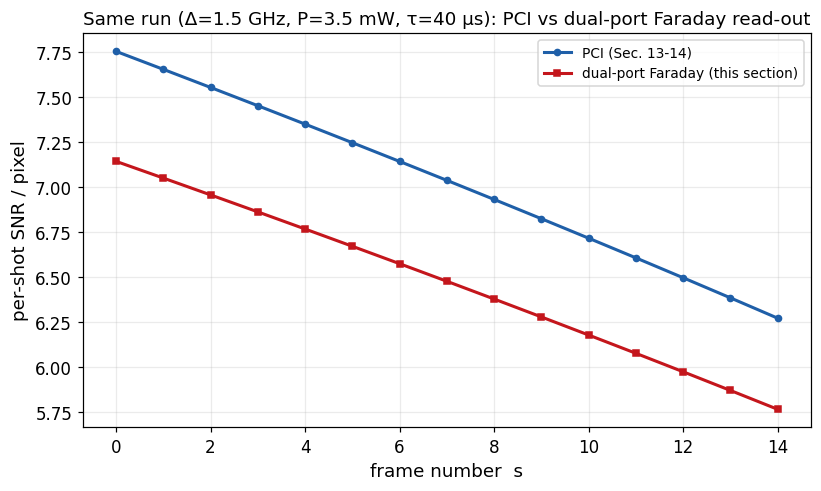

Same condensate decay (N_max, frame count) as Sec. 13-14 -- only the per-shot SNR trace changes with the imaging mode; the saturating accumulated-SNR curve of Sec. 14(d) applies here too, with this section's per-shot values substituted in.


In [26]:
# ---- re-image the SAME Sec-13 run (seq_h) with dual-port Faraday, frame by frame ----
def _bin_center(I):
    nb_ = (Ngrid//15)*15; mid = nb_//30
    return I[:nb_,:nb_].reshape(nb_//15,15,nb_//15,15).mean(axis=(1,3))[mid, mid]

snr_far = np.full(len(seq_h['shot']), np.nan)
for i, N0_i in enumerate(seq_h['N0']):
    _, _, _, ncol_i = tf_state(N0_i)
    th_i = theta_F_peak(SEQ_Delta, ncol_i[SEQ_axis])
    Ex, Ey = sim_faraday_fields(SEQ_axis, th_i)
    Iu, Iv = _bin_center(np.abs(Ex+Ey)**2/2), _bin_center(np.abs(Ex-Ey)**2/2)
    Nd = N_phot_pix(SEQ_P_mW, SEQ_tau)
    Nu, Nv = Iu*Nd, Iv*Nd
    theta_meas = (Nv-Nu)/(Nv+Nu)/2
    sig_theta  = np.sqrt(Nu+Nv+2*read_e**2)/(Nu+Nv)/2
    snr_far[i] = abs(theta_meas)/sig_theta

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(seq_h['shot'], seq_h['snr'], 'o-', color='#1f5fa8', lw=2, ms=4, label='PCI (Sec. 13-14)')
ax.plot(seq_h['shot'], snr_far, 's-', color='#c4161c', lw=2, ms=4, label='dual-port Faraday (this section)')
ax.set_xlabel('frame number  s'); ax.set_ylabel('per-shot SNR / pixel')
ax.set_title(f'Same run (\u0394={SEQ_Delta_GHz} GHz, P={SEQ_P_mW} mW, \u03c4={SEQ_tau_us:.0f} \u03bcs): '
             'PCI vs dual-port Faraday read-out')
ax.grid(alpha=0.25); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig_faraday_sequence.png', dpi=140, bbox_inches='tight', facecolor='white'); plt.show()

print("Same condensate decay (N_max, frame count) as Sec. 13-14 -- only the per-shot SNR trace "
      "changes with the imaging mode; the saturating accumulated-SNR curve of Sec. 14(d) applies "
      "here too, with this section's per-shot values substituted in.")

---
## 18. From condensate to camera: the full simulation pipeline, stage by stage [new]

Sections 1-17 built every *piece* of this simulation, but introduced them in the order needed for
the derivations rather than the order light actually experiences them. This section reassembles
the pieces into one explicit pipeline and walks a single concrete example through every stage, so
that a "result" anywhere else in this notebook is visibly traceable back to the physical object it
started from.

| Stage | What happens | Derived in | Implemented as |
|---|---|---|---|
| 1. Construct the condensate | Thomas-Fermi ground state $n(\mathbf r)$ from $(N_0,a_s,\omega_i)$ | §4 | `tf_state`, `_tf_profile` |
| 2. Imprint the optical signal | probe accumulates $\varphi(\mathbf r_\perp)$ (PCI/DGI) or $\theta_F(\mathbf r_\perp)$ (Faraday) from the column density | §5, §17.1 | `phi_peak`, `theta_F_peak` |
| 3. Propagate through the imaging system | finite-NA Fourier optics band-limits the field | §7.3 | `sim_image`, `sim_faraday_fields` |
| 4. Generate mode-specific contrast | Fourier-plane optic (PCI/DGI) or polarization analyzer (Faraday) turns the field into an intensity | §7.1, §17.2 | `sim_image(...,mode=...)`, `faraday_maps` |
| 5. Detect | bin to camera pixels, apply QE, add shot + read noise | §7.4 | `to_camera` |

The four subsections below walk stages 1-5 in order for one reference point, ending with all four
imaging modes side by side.

Stage 1 inputs -> the fresh Thomas-Fermi condensate (Sec. 4):
  N0 = 2.50e+04 atoms,  a_s = 72 a0,  trap = (293, 14, 233) Hz
  => mu/kB = 47.6 nK,  n_peak = 3.40e+14 cm^-3,  R = (1.19, 24.82, 1.49) um


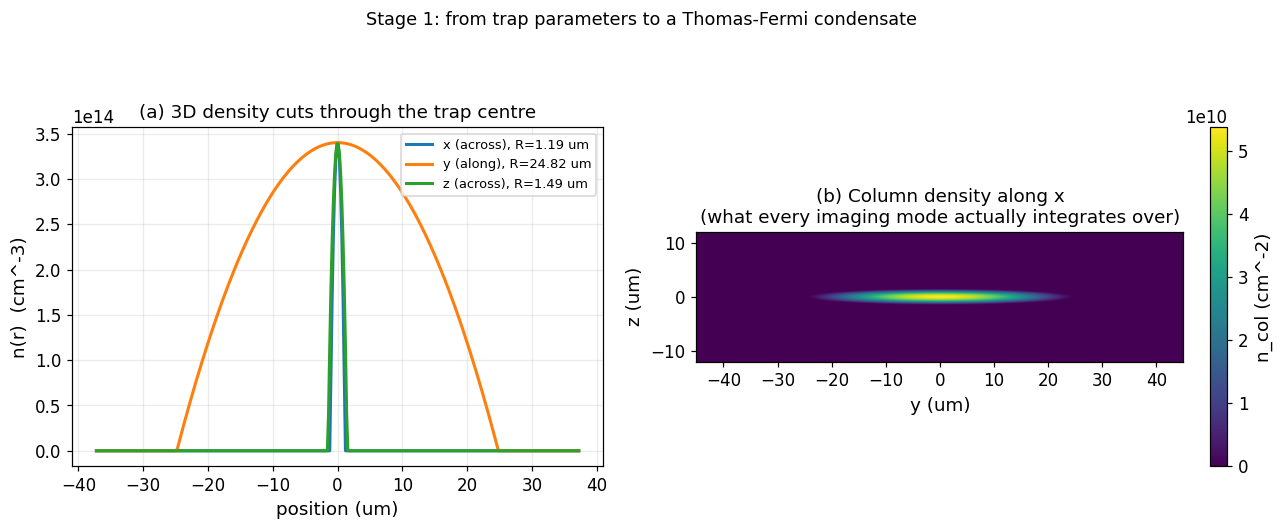

In [27]:
# ============================================================================
# 18.1  STAGE 1 -- constructing the condensate (Sec. 4's Thomas-Fermi solution, revisited)
# ============================================================================
print("Stage 1 inputs -> the fresh Thomas-Fermi condensate (Sec. 4):")
print(f"  N0 = {N0:.2e} atoms,  a_s = {a_s/a0:.0f} a0,  "
      f"trap = ({trap_Hz[0]:.0f}, {trap_Hz[1]:.0f}, {trap_Hz[2]:.0f}) Hz")
print(f"  => mu/kB = {T_mu*1e9:.1f} nK,  n_peak = {n_peak*1e-6:.2e} cm^-3,  "
      f"R = ({R[0]*1e6:.2f}, {R[1]*1e6:.2f}, {R[2]*1e6:.2f}) um")

axis_demo = 0                                       # across-cigar imaging, as used from Sec. 7 on
plane = [i for i in range(3) if i != axis_demo]
xax = np.linspace(-1.5*R.max(), 1.5*R.max(), 400)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.8, 4.6))
for i, (lab, col) in enumerate(zip(['x (across)', 'y (along)', 'z (across)'], ['C0','C1','C2'])):
    n1d = n_peak*np.maximum(0, 1 - (xax/R[i])**2)   # 3D TF density cut through the centre, along axis i
    axA.plot(xax*1e6, n1d*1e-6, col, lw=2, label=f'{lab}, R={R[i]*1e6:.2f} um')
axA.set_xlabel('position (um)'); axA.set_ylabel('n(r)  (cm^-3)')
axA.set_title('(a) 3D density cuts through the trap centre'); axA.legend(fontsize=8.5); axA.grid(alpha=0.25)

col_dens_map = n_col[axis_demo] * _tf_profile(R[plane[0]], R[plane[1]])
im = axB.imshow(col_dens_map*1e-4, extent=ext, origin='lower', cmap='viridis')
axB.set_xlim(-45, 45); axB.set_ylim(-12, 12)
axB.set_xlabel(f'{"xyz"[plane[0]]} (um)'); axB.set_ylabel(f'{"xyz"[plane[1]]} (um)')
axB.set_title('(b) Column density along '+"xyz"[axis_demo]+'\n'
              '(what every imaging mode actually integrates over)')
plt.colorbar(im, ax=axB, fraction=0.032, label='n_col (cm^-2)')
fig.suptitle('Stage 1: from trap parameters to a Thomas-Fermi condensate', y=1.04, fontsize=11.5)
plt.tight_layout(); plt.show()

### 18.2 Stage 2 -- the optical signal imprinted on the probe
Both signals below are generated from the *identical* Stage-1 column-density map -- they are
literally the same spatial profile as panel (b) above, just multiplied by a different peak value
($\varphi_\mathrm{peak}$ from §5.1's scalar dispersion, or $\theta_{F,\mathrm{peak}}$ from
§17.1's vector dispersion). This is the moment the atoms actually "write" information onto the
probe beam; everything from here on is optics and detection engineering, not atomic physics.

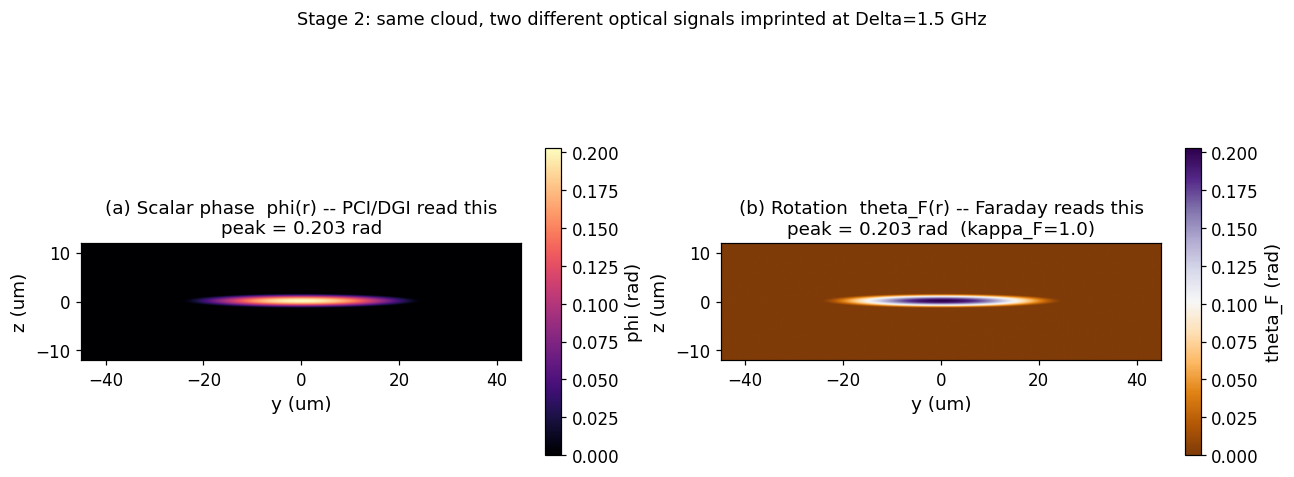

Both maps share the identical spatial shape (Stage 1's column-density profile) -- only the physical origin and the size of the peak value differ (Sec. 5 vs Sec. 17.1).


In [28]:
# ============================================================================
# 18.2  STAGE 2 -- the optical signal the probe picks up from that condensate
# ============================================================================
D_demo, P_demo = 1.5e9, 5.0     # single reference point carried through the rest of Sec. 18
phi_demo   = phi_peak(D_demo, n_col[axis_demo])
theta_demo = theta_F_peak(D_demo, n_col[axis_demo])
phase_map = phi_demo   * _tf_profile(R[plane[0]], R[plane[1]])
rot_map   = theta_demo * _tf_profile(R[plane[0]], R[plane[1]])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.8, 4.6))
im0 = axA.imshow(phase_map, extent=ext, origin='lower', cmap='magma')
axA.set_title(f'(a) Scalar phase  phi(r) -- PCI/DGI read this\npeak = {phi_demo:.3f} rad')
plt.colorbar(im0, ax=axA, fraction=0.032, label='phi (rad)')
im1 = axB.imshow(rot_map, extent=ext, origin='lower', cmap='PuOr')
axB.set_title(f'(b) Rotation  theta_F(r) -- Faraday reads this\n'
              f'peak = {theta_demo:.3f} rad  (kappa_F={kappa_F})')
plt.colorbar(im1, ax=axB, fraction=0.032, label='theta_F (rad)')
for a in (axA, axB):
    a.set_xlim(-45,45); a.set_ylim(-12,12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')
fig.suptitle(f'Stage 2: same cloud, two different optical signals imprinted at '
             f'Delta={D_demo/1e9:.1f} GHz', y=1.04, fontsize=11.5)
plt.tight_layout(); plt.show()
print("Both maps share the identical spatial shape (Stage 1's column-density profile) -- only the "
      "physical origin and the size of the peak value differ (Sec. 5 vs Sec. 17.1).")

### 18.3 Stages 3-4 -- propagation and mode-specific contrast
The phase/rotation maps of Stage 2 are not yet visible as an intensity -- a pure phase or rotation
produces no contrast on its own. Stage 3 propagates the field through the finite-NA 4f imaging
system, band-limiting high spatial frequencies (§7.3); Stage 4 is where the four modes
diverge, converting that band-limited field into an intensity by four different routes (a
phase-shifted reference plate, an opaque beam block, a crossed polarizer, or a polarizing beam
splitter). All four panels below use one common reference probe power and detuning purely so the
comparison is visual and fair; §17.3 already compared SNR mode-by-mode at each mode's own
typical operating power.

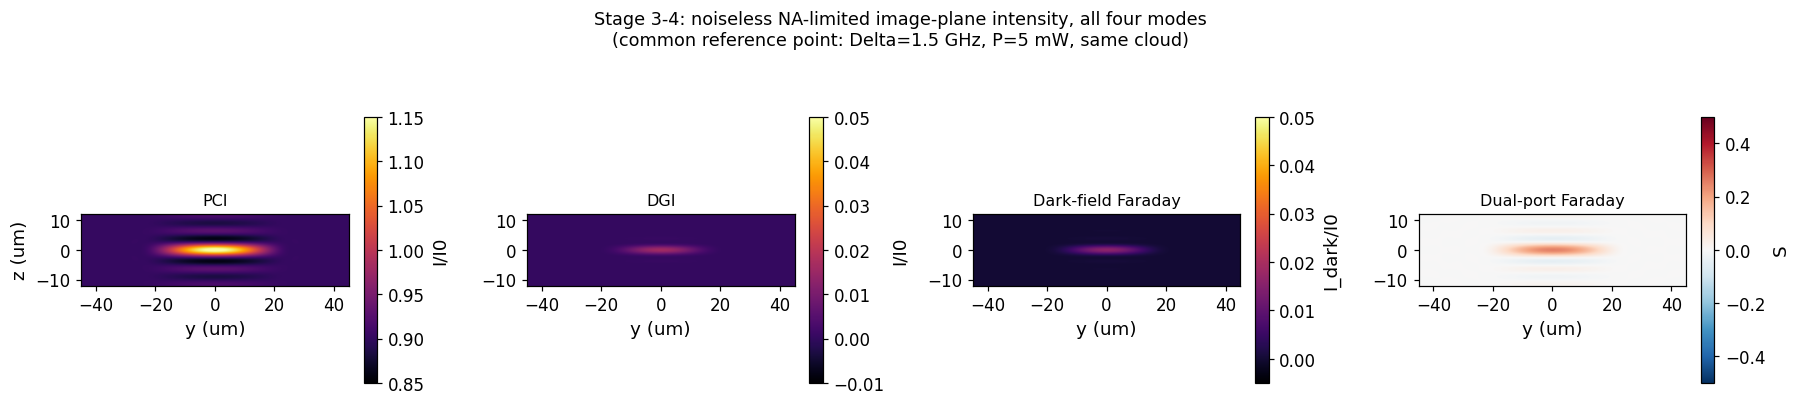

PCI and dual-port Faraday are LINEAR in their signal (phi, theta_F) and so visibly modulate around a nonzero background; DGI and dark-field Faraday are QUADRATIC and so appear as a faint bright sliver on an otherwise dark field -- the same linear/quadratic split as Sec. 17.3's SNR table, made visible.


In [29]:
# ============================================================================
# 18.3  STAGES 3-4 -- NA-limited propagation, then mode-specific contrast generation
# ============================================================================
I_pci_nl, _ = sim_image(axis_demo, phi_demo, 'PCI')
I_dgi_nl, _ = sim_image(axis_demo, phi_demo, 'DGI')
fmap_demo = faraday_maps(D_demo, axis_demo)
I_dark_nl = fmap_demo['I_dark']
S_nl = (fmap_demo['I_v'] - fmap_demo['I_u']) / (fmap_demo['I_v'] + fmap_demo['I_u'])

panels = [(I_pci_nl,  'PCI',                'inferno', (0.85, 1.15), 'I/I0'),
          (I_dgi_nl,  'DGI',                'inferno', (-0.01, 0.05), 'I/I0'),
          (I_dark_nl, 'Dark-field Faraday', 'inferno', (-0.005, 0.05), 'I_dark/I0'),
          (S_nl,      'Dual-port Faraday',  'RdBu_r',  (-0.5, 0.5), 'S')]
fig, axs = plt.subplots(1, 4, figsize=(16.5, 4.0))
for a, (img, title, cmap, vv, lab) in zip(axs, panels):
    im = a.imshow(img, extent=ext, origin='lower', cmap=cmap, vmin=vv[0], vmax=vv[1])
    a.set_xlim(-45,45); a.set_ylim(-12,12); a.set_xlabel('y (um)')
    a.set_title(title, fontsize=10.5)
    plt.colorbar(im, ax=a, fraction=0.045, label=lab)
axs[0].set_ylabel('z (um)')
fig.suptitle(f'Stage 3-4: noiseless NA-limited image-plane intensity, all four modes\n'
             f'(common reference point: Delta={D_demo/1e9:.1f} GHz, P={P_demo:.0f} mW, same cloud)',
             fontsize=11.5)
plt.tight_layout(); plt.show()
print("PCI and dual-port Faraday are LINEAR in their signal (phi, theta_F) and so visibly modulate "
      "around a nonzero background; DGI and dark-field Faraday are QUADRATIC and so appear as a "
      "faint bright sliver on an otherwise dark field -- the same linear/quadratic split as Sec. 17.3's "
      "SNR table, made visible.")

### 18.4 Stage 5 -- detection and the final result
The last stage is the camera: bin the continuous field onto discrete pixels, convert to detected
photons via the quantum efficiency, and add Poisson shot noise and Gaussian read noise (§7.4).
This is the only stage that is genuinely random -- everything upstream is a deterministic function
of the condensate and the chosen probe parameters -- which is why every SNR number in this notebook
is a *ratio* of a deterministic signal to a well-defined noise floor, not a guess.

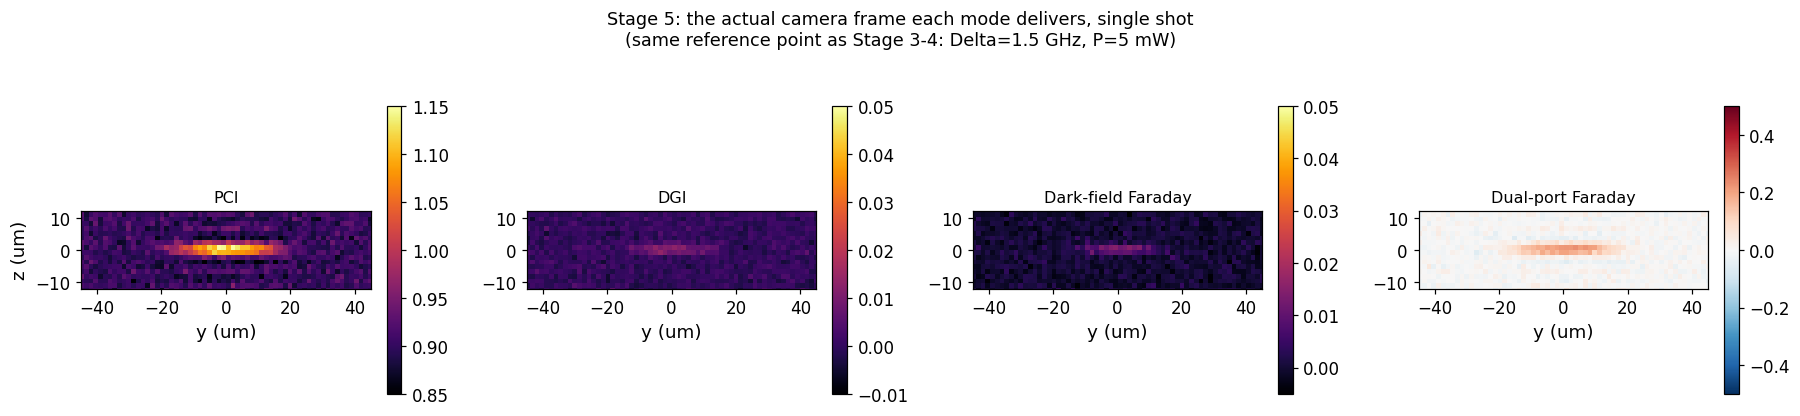

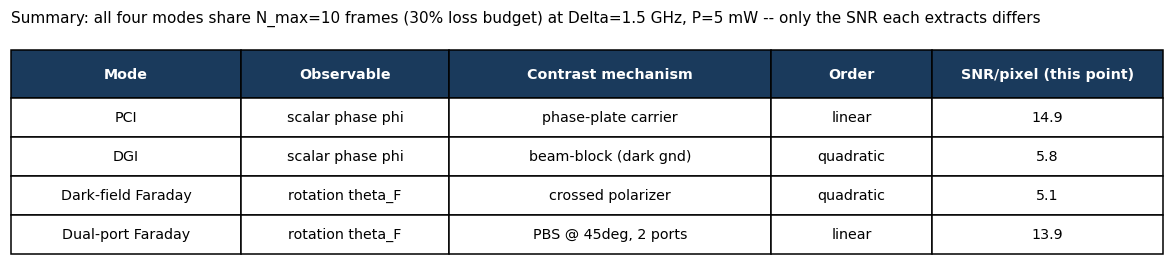

In [30]:
# ============================================================================
# 18.4  STAGE 5 -- detection: binning to camera pixels, QE, shot noise, read noise
# ============================================================================
cam_pci_nl, _  = to_camera(I_pci_nl, P_demo)
cam_dgi_nl, _  = to_camera(I_dgi_nl, P_demo)
cam_dark_nl, _ = to_camera(I_dark_nl, P_demo)
cam_u_nl, _ = to_camera(fmap_demo['I_u'], P_demo)
cam_v_nl, _ = to_camera(fmap_demo['I_v'], P_demo)
cam_S_nl = (cam_v_nl - cam_u_nl) / (cam_v_nl + cam_u_nl)

panels2 = [(cam_pci_nl,  'PCI',                'inferno', (0.85, 1.15)),
           (cam_dgi_nl,  'DGI',                'inferno', (-0.01, 0.05)),
           (cam_dark_nl, 'Dark-field Faraday', 'inferno', (-0.005, 0.05)),
           (cam_S_nl,    'Dual-port Faraday',  'RdBu_r',  (-0.5, 0.5))]
fig, axs = plt.subplots(1, 4, figsize=(16.5, 4.0))
for a, (img, title, cmap, vv) in zip(axs, panels2):
    im = a.imshow(img, extent=ext, origin='lower', cmap=cmap, vmin=vv[0], vmax=vv[1])
    a.set_xlim(-45,45); a.set_ylim(-12,12); a.set_xlabel('y (um)')
    a.set_title(title, fontsize=10.5)
    plt.colorbar(im, ax=a, fraction=0.045)
axs[0].set_ylabel('z (um)')
fig.suptitle(f'Stage 5: the actual camera frame each mode delivers, single shot\n'
             f'(same reference point as Stage 3-4: Delta={D_demo/1e9:.1f} GHz, P={P_demo:.0f} mW)',
             fontsize=11.5)
plt.tight_layout(); plt.savefig('fig_pipeline_final_frames.png', dpi=140, bbox_inches='tight', facecolor='white'); plt.show()

# ---- summary comparison, pulling every stage together ----
Nmax_demo   = Nmax_heating(D_demo, P_demo, 0.30)
s_pci_demo  = SNR_pixel(D_demo, P_demo, axis_demo)
Ndgi_demo   = I_dgi_nl.max()*N_phot_pix(P_demo)
s_dgi_demo  = Ndgi_demo/np.sqrt(Ndgi_demo + read_e**2)
s_dark_demo = SNR_faraday_sim(D_demo, P_demo, axis_demo, scheme='dark')
s_dual_demo = SNR_faraday_sim(D_demo, P_demo, axis_demo, scheme='dual')

fig, ax = plt.subplots(figsize=(10.8, 2.6)); ax.axis('off')
rows = [
    ['PCI',                'scalar phase phi',  'phase-plate carrier',     'linear',    f'{s_pci_demo:.1f}'],
    ['DGI',                'scalar phase phi',  'beam-block (dark gnd)',   'quadratic', f'{s_dgi_demo:.1f}'],
    ['Dark-field Faraday', 'rotation theta_F',  'crossed polarizer',       'quadratic', f'{s_dark_demo:.1f}'],
    ['Dual-port Faraday',  'rotation theta_F',  'PBS @ 45deg, 2 ports',    'linear',    f'{s_dual_demo:.1f}'],
]
tb = ax.table(cellText=rows,
              colLabels=['Mode','Observable','Contrast mechanism','Order','SNR/pixel (this point)'],
              cellLoc='center', loc='center', colWidths=[.20,.18,.28,.14,.20])
tb.auto_set_font_size(False); tb.set_fontsize(9.3)
for (i,j),cl in tb.get_celld().items():
    cl.set_height(0.22 if i==0 else 0.18)
    if i==0: cl.set_facecolor('#1a3a5c'); cl.set_text_props(color='white', weight='bold')
ax.set_title(f'Summary: all four modes share N_max={Nmax_demo:.0f} frames (30% loss budget) at '
             f'Delta={D_demo/1e9:.1f} GHz, P={P_demo:.0f} mW -- only the SNR each extracts differs',
             fontsize=10, pad=14, loc='left')
plt.tight_layout(); plt.show()

Reading the five stages back to front: a headline SNR number anywhere in this notebook is the
size of a deterministic optical signal (Stage 2, set by how many atoms are in the beam and how far
detuned the probe is) after it has survived being band-limited by a finite lens (Stage 3),
converted to an intensity by a specific piece of contrast-generating hardware (Stage 4), and
finally weighed against a noise floor set by the number of photons collected and the camera's read
noise (Stage 5). Every simulated image in §7, §15 and §17 is one particular instance
of exactly this pipeline; §9/§12's destruction budget is simply the constraint on how many
times Stage 2 can be repeated before the condensate itself is gone.

---
# Part IV — One shot through the machine

## 19. The simulation, step by step [new]

Everything below follows **one probe shot** through the imaging system, in the exact order the
simulation computes it. Every figure shows the *actual state of the simulated field at that step* —
no summary plots, no sweeps: what you see in Step $n$ is literally the array the code holds after
executing the line quoted in Step $n$. Each step carries three short threads:

> **Theory** — the equation governing this step.
> **What is happening** — the physical event, in words.
> **What the code does** — the line(s) of this notebook that execute it.

The shot is the notebook's reference point throughout: fresh condensate, probe along $x$
(across-cigar), $\Delta = 1.5$ GHz, $P = 5$ mW — so $\varphi_\mathrm{peak} = \theta_{F,\mathrm{peak}} = 0.203$ rad.

**The plot of the story.** Steps 1–5 are shared by every mode and end in an apparent dead end: even
through a perfect lens system, the atoms are *invisible*. Steps 6–13 are the four ways out — PCI,
DGI, dark-field Faraday, dual-port Faraday — each one picking up the same field where Step 5 left
it. Step 14 closes with the price of looking: the multi-shot run as a filmstrip.

### 19.1 Steps 1–5: the shared road to invisibility

#### Step 1 — the atoms hand us a phase map, and nothing else

**Theory.** Far from resonance the cloud's susceptibility is almost purely real (§5–6): a photon
crossing it is *delayed*, not absorbed. The accumulated phase is proportional to the column
density, $\varphi(\mathbf r) = \varphi_\mathrm{peak}\cdot\big(1 - y^2/R_y^2 - z^2/R_z^2\big)^{3/2}$,
the integrated Thomas–Fermi profile of §4, with $\varphi_\mathrm{peak} = 0.203$ rad at this
detuning.

**What is happening.** The condensate acts as a weak, cloud-shaped pane of glass 50 µm wide and
3 µm tall. This phase map is the *only* imprint the atoms make on the light — every method in this
notebook is a different way of cashing exactly this one map into photons on a camera.

**What the code does.** `prof = _tf_profile(R[1], R[2])` builds the profile on the 1024² grid;
`phi_peak(1.5e9, n_col[0])` sets its height.

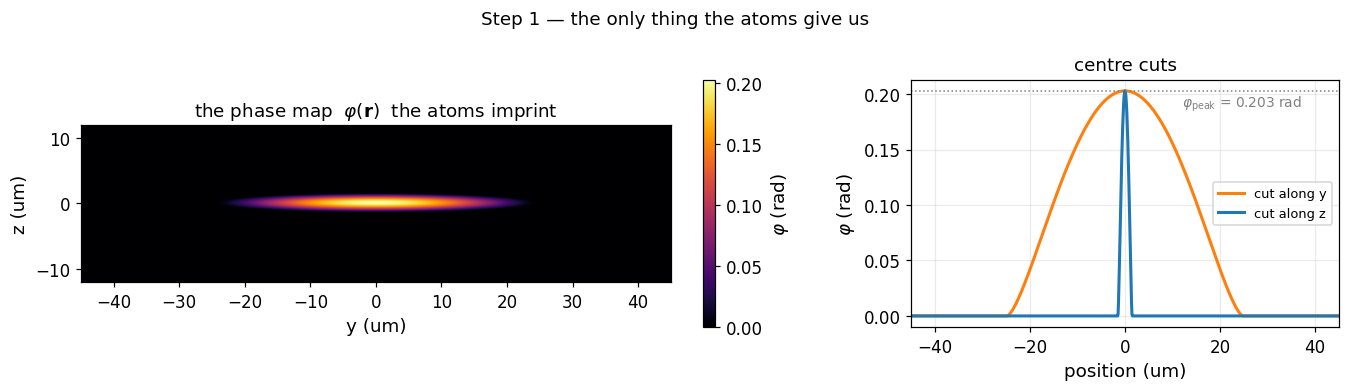

In [31]:
# ---- STEP 1: the phase map -------------------------------------------------
st_Delta, st_P = 1.5e9, 5.0
st_phi0 = phi_peak(st_Delta, n_col[0])
st_prof = _tf_profile(R[1], R[2])                        # probe along x -> (y,z) plane
st_phi_map = st_phi0 * st_prof

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 3.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
im = a1.imshow(st_phi_map, extent=ext, origin='lower', cmap='inferno')
a1.set_xlim(-45, 45); a1.set_ylim(-12, 12)
a1.set_xlabel('y (um)'); a1.set_ylabel('z (um)')
a1.set_title('the phase map  $\\varphi(\\mathbf{r})$  the atoms imprint')
plt.colorbar(im, ax=a1, fraction=0.03, label='$\\varphi$ (rad)')
a2.plot(gax*1e6, st_phi_map[Ngrid//2, :], 'C1', lw=2, label='cut along y')
a2.plot(gax*1e6, st_phi_map[:, Ngrid//2], 'C0', lw=2, label='cut along z')
a2.axhline(st_phi0, color='gray', ls=':', lw=1)
a2.annotate(f'$\\varphi_\\mathrm{{peak}}$ = {st_phi0:.3f} rad', (12, st_phi0*0.93), fontsize=9, color='gray')
a2.set_xlim(-45, 45); a2.set_xlabel('position (um)'); a2.set_ylabel('$\\varphi$ (rad)')
a2.set_title('centre cuts'); a2.legend(fontsize=8.5); a2.grid(alpha=0.25)
fig.suptitle('Step 1 — the only thing the atoms give us', fontsize=12)
plt.tight_layout(); plt.show()

#### Step 2 — the field after the atoms: the camera would see *nothing*

**Theory.** The probe leaves the cloud as $E(\mathbf r) = e^{i\varphi(\mathbf r)}$ — a **pure phase
object**. Its intensity is $|e^{i\varphi}|^2 = 1$ *identically*: the information survives only in
$\arg E$, which no photodetector responds to.

**What is happening.** Below, the same field twice. Left: its intensity — put a camera here (or at
any image plane of a perfect system) and the frame is blank. Right: its phase — the condensate,
perfectly formed, hiding in the one quantity light detectors cannot read. The entire imaging
problem is getting the right-hand panel to leak into the left-hand one.

**What the code does.** `np.exp(1j*phi_peak_val*prof)` — the first line inside `sim_image`.

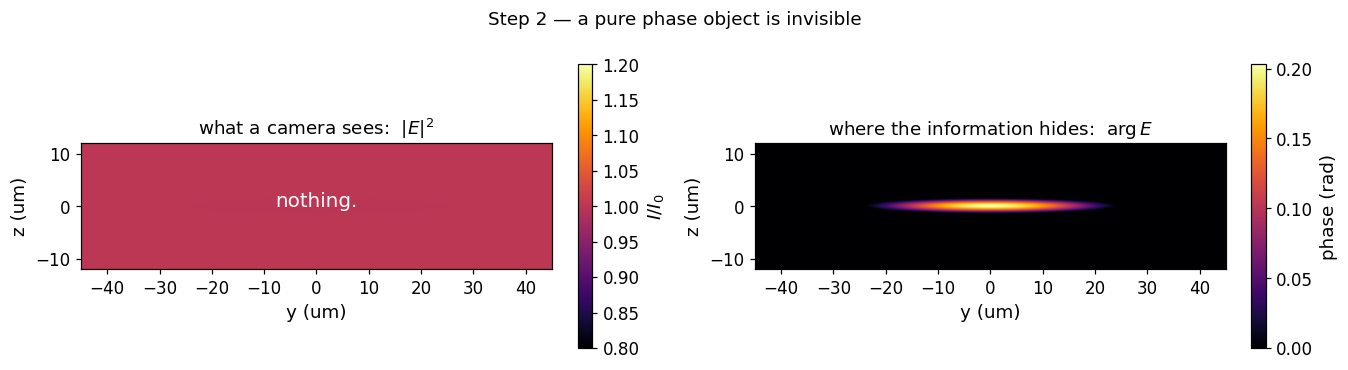

max deviation of |E|^2 from 1 over the whole field: 4.4e-16   -> exactly blank, not approximately blank.


In [32]:
# ---- STEP 2: intensity blank, phase structured -------------------------------
st_E_atoms = np.exp(1j * st_phi_map)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 3.4))
im1 = a1.imshow(np.abs(st_E_atoms)**2, extent=ext, origin='lower', cmap='inferno', vmin=0.8, vmax=1.2)
a1.set_xlim(-45, 45); a1.set_ylim(-12, 12); a1.set_xlabel('y (um)'); a1.set_ylabel('z (um)')
a1.set_title('what a camera sees:  $|E|^2$')
plt.colorbar(im1, ax=a1, fraction=0.03, label='$I/I_0$')
a1.annotate('nothing.', (0, 0), color='w', fontsize=13, ha='center')
im2 = a2.imshow(np.angle(st_E_atoms), extent=ext, origin='lower', cmap='inferno')
a2.set_xlim(-45, 45); a2.set_ylim(-12, 12); a2.set_xlabel('y (um)'); a2.set_ylabel('z (um)')
a2.set_title('where the information hides:  $\\arg E$')
plt.colorbar(im2, ax=a2, fraction=0.03, label='phase (rad)')
fig.suptitle('Step 2 — a pure phase object is invisible', fontsize=12)
plt.tight_layout(); plt.show()
print(f"max deviation of |E|^2 from 1 over the whole field: {np.max(np.abs(np.abs(st_E_atoms)**2 - 1)):.1e}"
      f"   -> exactly blank, not approximately blank.")

#### Step 3 — split the field: a big carrier and a small wavelet at 90°

**Theory.** Write $e^{i\varphi} = 1 + w$, with $w \equiv e^{i\varphi}-1$. The "1" is the
**carrier** — the probe as if no atoms were there. The **wavelet** $w$ carries all the atomic
information; for small phase, $w \approx i\varphi$: it points at $90°$ to the carrier in the
complex plane (exactly: $\arg w = 90° + \varphi/2$, $|w| = 2\sin(\varphi/2)$).

**What is happening.** This decomposition *is* the reason for invisibility. Interference changes
intensity through the cross term $2\,\mathrm{Re}(1^*\!\cdot w)$, and a wavelet at $\sim90°$ has
almost no real part — the phasor diagram below, drawn **from the actual centre-pixel values of the
simulated field**, shows the tip-to-tail sum landing right back on the unit circle:
$|1+w| = 1$. The two arrows are there, carrying 0.2 rad of signal, and they cannot beat against
each other. Every mode in Steps 6–13 is one way of re-arranging these two arrows.

**What the code does.** the `- 1` inside `fft2(np.exp(1j*phi*prof) - 1)` — the carrier is split
off *analytically* and handled exactly from here on.

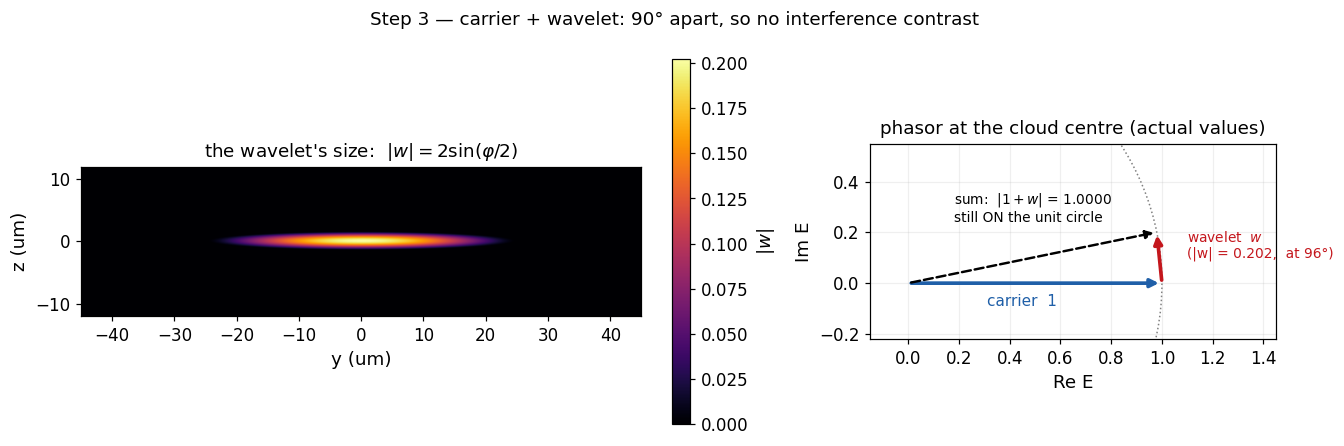

In [33]:
# ---- STEP 3: the wavelet map + the phasor from actual simulated values -------
st_w = st_E_atoms - 1                                  # the wavelet, exactly as the code forms it
_c = Ngrid//2
st_wc = st_w[_c-1:_c+1, _c-1:_c+1].mean()              # actual value at the cloud centre

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.1), gridspec_kw=dict(width_ratios=[1.5, 1]))
im = a1.imshow(np.abs(st_w), extent=ext, origin='lower', cmap='inferno')
a1.set_xlim(-45, 45); a1.set_ylim(-12, 12); a1.set_xlabel('y (um)'); a1.set_ylabel('z (um)')
a1.set_title('the wavelet\'s size:  $|w| = 2\\sin(\\varphi/2)$')
plt.colorbar(im, ax=a1, fraction=0.03, label='$|w|$')

# phasor: carrier, then wavelet tip-to-tail, then their sum -- actual numbers
a2.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls=':', color='gray', lw=1))
a2.annotate('', xy=(1, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#1f5fa8', lw=2.4))
a2.annotate('carrier  1', (0.45, -0.09), color='#1f5fa8', fontsize=10, ha='center')
a2.annotate('', xy=(1+st_wc.real, st_wc.imag), xytext=(1, 0),
            arrowprops=dict(arrowstyle='-|>', color='#c4161c', lw=2.4))
a2.annotate(f'wavelet  $w$\n(|w| = {abs(st_wc):.3f},  at {np.degrees(np.angle(st_wc)):.0f}°)',
            (1.10, 0.10), color='#c4161c', fontsize=9)
a2.annotate('', xy=(1+st_wc.real, st_wc.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='k', lw=1.6, ls='--'))
a2.annotate(f'sum:  $|1+w|$ = {abs(1+st_wc):.4f}\nstill ON the unit circle', (0.18, 0.24),
            fontsize=9)
a2.set_xlim(-0.15, 1.45); a2.set_ylim(-0.22, 0.55); a2.set_aspect('equal')
a2.set_xlabel('Re E'); a2.set_ylabel('Im E'); a2.grid(alpha=0.2)
a2.set_title('phasor at the cloud centre (actual values)')
fig.suptitle('Step 3 — carrier + wavelet: 90° apart, so no interference contrast', fontsize=12)
plt.tight_layout(); plt.show()

#### Step 4 — the Fourier plane: the one place the two arrows sit apart

**Theory.** The first lens performs a spatial Fourier transform. The carrier — a plane wave —
focuses to a delta function at the centre (DC); the wavelet, cloud-shaped in real space, spreads
into a halo of width $\sim 1/(\text{cloud size})$: the tight $z$ direction (1.5 µm) scatters wide,
the long $y$ direction (25 µm) scatters narrow. Only what lies inside the NA circle survives.

**What is happening.** In real space, carrier and wavelet overlap everywhere — you cannot touch
one without the other. *Here* they separate: a physical object of the right size placed at this
plane (a phase dot, a dark stop) acts on the carrier alone. This plane is the handle for PCI and
DGI. The right panel shows the aperture doing its (destructive) share: the outer halo — the
sharpest spatial detail — is gone before any mode-specific optics even begins.

**What the code does.** `fft2(...) * pupil` — and the carrier's delta is never on the grid at all:
the code carries it as the exact analytic term outside the transform, so the Fourier-plane
element later acts on it *exactly* (the one idealisation shared by §§7–18: a real dot or stop has
finite size and would also clip the innermost halo).

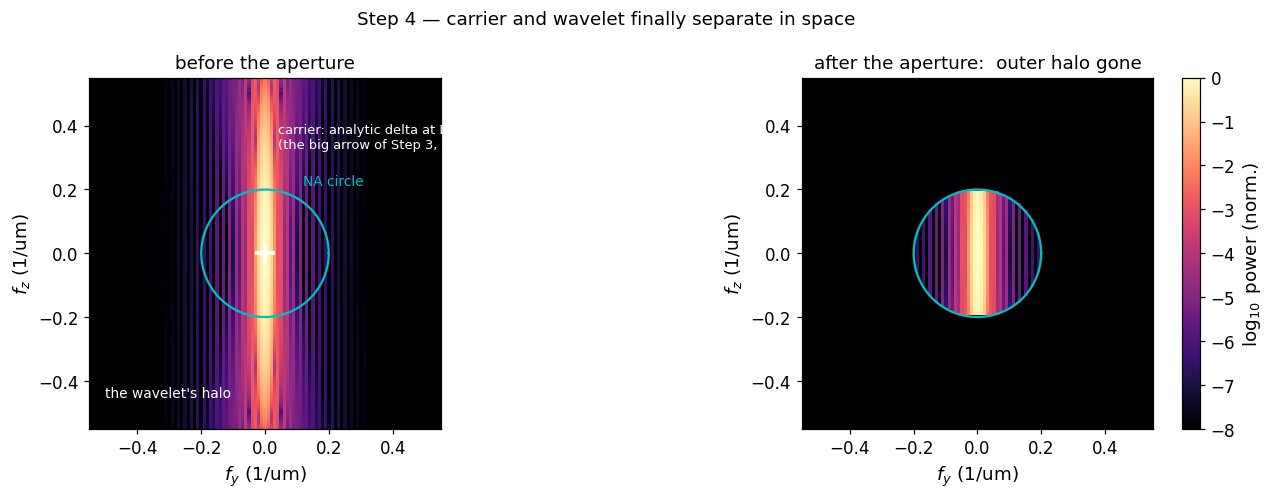

scattered power inside the NA circle: 0.712  -> the aperture keeps ~71% of the wavelet; this loss is the blur factor of Sec. 7 and is paid by every mode alike.


In [34]:
# ---- STEP 4: the Fourier plane, before and after the aperture ----------------
st_F = np.fft.fftshift(np.fft.fft2(st_w))
st_P2 = np.abs(st_F)**2 / np.abs(st_F).max()**2
st_fax = np.fft.fftshift(np.fft.fftfreq(Ngrid, FOV/Ngrid)) * 1e-6
st_fNA = NA/lam * 1e-6
st_pup = np.fft.fftshift(pupil)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.6))
for a, dat, ttl in [(a1, st_P2, 'before the aperture'),
                    (a2, st_P2*st_pup, 'after the aperture:  outer halo gone')]:
    im = a.imshow(np.log10(dat + 1e-12), extent=[st_fax[0], st_fax[-1], st_fax[0], st_fax[-1]],
                  origin='lower', cmap='magma', vmin=-8, vmax=0)
    th_c = np.linspace(0, 2*np.pi, 200)
    a.plot(st_fNA*np.cos(th_c), st_fNA*np.sin(th_c), 'c-', lw=1.5)
    a.set_xlim(-0.55, 0.55); a.set_ylim(-0.55, 0.55)
    a.set_xlabel('$f_y$ (1/um)'); a.set_ylabel('$f_z$ (1/um)'); a.set_title(ttl)
a1.plot(0, 0, 'w+', ms=13, mew=2.5)
a1.annotate('carrier: analytic delta at DC\n(the big arrow of Step 3, parked here)',
            (0.04, 0.33), color='w', fontsize=8.5)
a1.annotate('the wavelet\'s halo', (-0.5, -0.45), color='w', fontsize=9)
a1.annotate('NA circle', (st_fNA*0.6, st_fNA*1.06), color='c', fontsize=9)
plt.colorbar(im, ax=a2, fraction=0.045, label='$\\log_{10}$ power (norm.)')
fig.suptitle('Step 4 — carrier and wavelet finally separate in space', fontsize=12)
plt.tight_layout(); plt.show()
print(f"scattered power inside the NA circle: "
      f"{(st_P2*st_pup).sum()/st_P2.sum():.3f}  -> the aperture keeps ~71% of the wavelet;"
      f" this loss is the blur factor of Sec. 7 and is paid by every mode alike.")

#### Step 5 — through a *perfect* imaging system: still invisible

**Theory.** With nothing placed at the Fourier plane, the second lens reassembles
$E = 1 + w_\mathrm{NA}$ (the wavelet now band-limited). Since the surviving wavelet is still
essentially at 90° to the carrier, the cross term is still $\approx 0$: the intensity is flat up
to second-order crumbs, $|1+w_\mathrm{NA}|^2 \approx 1 + \mathcal{O}(\varphi^2) + \text{clipping ripples}$.

**What is happening.** This is the dead end the story has been building to: a *perfect,
aberration-free, lossless* 4f system faithfully delivers the phase object to its image plane —
still as a phase object. The colour bar below spans ±6% and the cloud barely registers. Nothing in
the optics so far has converted signal into intensity, because nothing has touched the *angle
between the two arrows*. That, and only that, is what the four modes now do — two of them by
grabbing the carrier at the Fourier plane (Steps 6–9), two by splitting the field into
polarizations that rotate against each other (Steps 10–13).

**What the code does.** `sim_image(axis, phi, mode)` with the fall-through branch `E = 1 + Esc` —
the "clear" reference the noisy frames of §7 are normalised against.

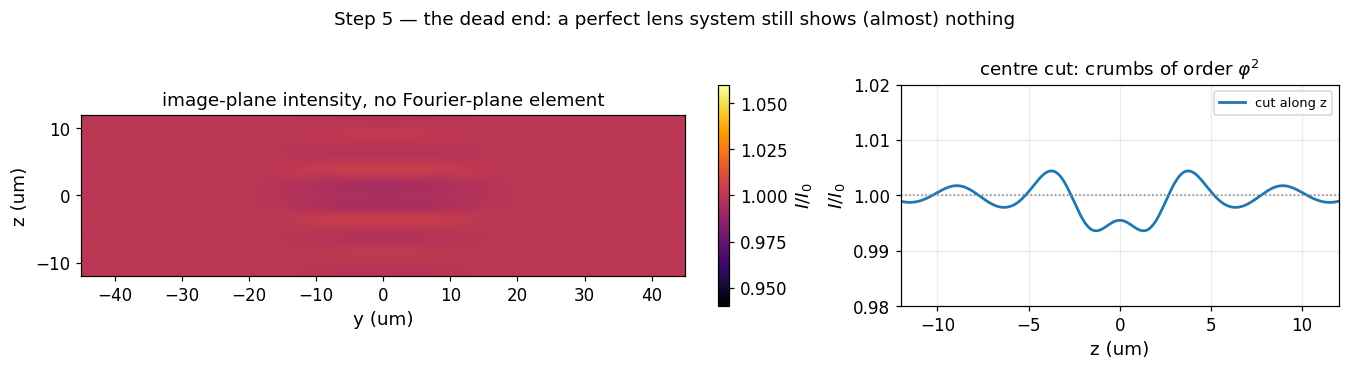

peak deviation from flatness: 0.006 of I0 -- second-order only, while the phase signal sitting in the field is 0.203 rad. Time for the tricks.


In [35]:
# ---- STEP 5: the image plane with no trick installed --------------------------
st_I_clear, _ = sim_image(0, st_phi0, 'clear')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 3.4), gridspec_kw=dict(width_ratios=[1.5, 1]))
im = a1.imshow(st_I_clear, extent=ext, origin='lower', cmap='inferno', vmin=0.94, vmax=1.06)
a1.set_xlim(-45, 45); a1.set_ylim(-12, 12); a1.set_xlabel('y (um)'); a1.set_ylabel('z (um)')
a1.set_title('image-plane intensity, no Fourier-plane element')
plt.colorbar(im, ax=a1, fraction=0.03, label='$I/I_0$')
a2.plot(gax*1e6, st_I_clear[:, Ngrid//2], 'C0', lw=1.8, label='cut along z')
a2.axhline(1, color='gray', ls=':', lw=1)
a2.set_xlim(-12, 12); a2.set_ylim(0.98, 1.02); a2.set_xlabel('z (um)'); a2.set_ylabel('$I/I_0$')
a2.set_title('centre cut: crumbs of order $\\varphi^2$'); a2.legend(fontsize=8.5); a2.grid(alpha=0.25)
fig.suptitle('Step 5 — the dead end: a perfect lens system still shows (almost) nothing', fontsize=12)
plt.tight_layout(); plt.show()
print(f"peak deviation from flatness: {np.max(np.abs(st_I_clear-1)):.3f} of I0 -- second-order only, "
      f"while the phase signal sitting in the field is {st_phi0:.3f} rad. Time for the tricks.")

### 19.2 PCI — rotate the carrier (Steps 6–7)

#### Step 6 — the phase plate turns the carrier by 90°, and the cloud appears

**Theory.** A small dot at the Fourier-plane centre retards (only) the carrier by $\pi/2$ and
transmits $t_p = 0.95$ of its amplitude: $1 \mapsto i\,t_p$. Nothing happens to the wavelet. Now
the two arrows are (nearly) **parallel**, and the cross term switches on:
$$I = |i\,t_p + w|^2 = t_p^2 + 2t_p\sin\varphi + 2(1-\cos\varphi) \approx t_p^2 + 2\,t_p\,\varphi .$$

**What is happening.** Compare the two phasor panels below — same actual centre-pixel values as
Step 3, before and after the plate. The wavelet has not changed at all; the carrier has been
*rotated under it*. Tip-to-tail, the sum now pokes **outside** the circle of radius $t_p$: the
cloud becomes a bright object on the $t_p^2$ background, linear in $\varphi$. The third panel is
the image plane: the same field as Step 5, transformed from blank to a condensate portrait by one
rotation.

**What the code does.** `E = t_p*np.exp(1j*theta) + Esc` — the entire optical trick is that one
analytic carrier coefficient.

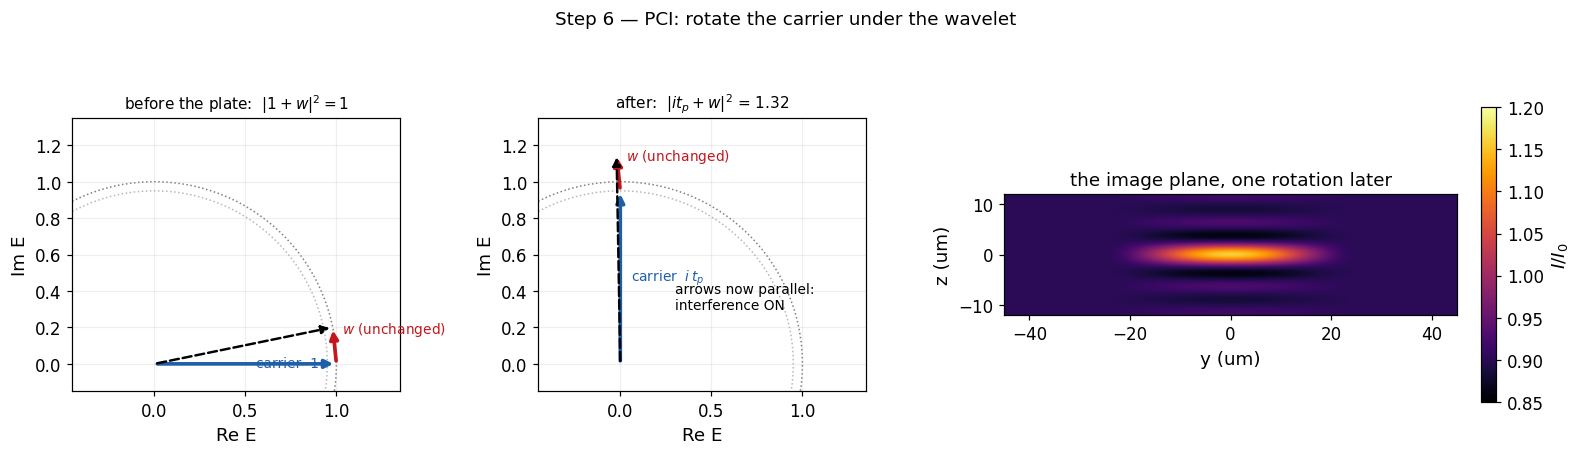

centre of the simulated image: I/I0 = 1.158   (infinite-NA phasor value 1.325; the gap is Step 4's aperture loss)


In [36]:
# ---- STEP 6: phasor before / after the plate + the image that appears ---------
st_I_pci, _ = sim_image(0, st_phi0, 'PCI')
st_carrier_pci = t_p*np.exp(1j*theta)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14.6, 4.3), gridspec_kw=dict(width_ratios=[1, 1, 1.5]))
for a, car, lab, ttl in [(a1, 1+0j, 'carrier  1', 'before the plate:  $|1+w|^2 = 1$'),
                         (a2, st_carrier_pci, 'carrier  $i\\,t_p$', 'after:  $|i t_p + w|^2$ = %.2f' %
                          abs(st_carrier_pci+st_wc)**2)]:
    a.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls=':', color='gray', lw=1))
    a.add_patch(plt.Circle((0, 0), t_p, fill=False, ls=':', color='#b8b8b8', lw=1))
    a.annotate('', xy=(car.real, car.imag), xytext=(0, 0),
               arrowprops=dict(arrowstyle='-|>', color='#1f5fa8', lw=2.4))
    a.annotate(lab, (car.real*0.5+0.06, car.imag*0.5-0.02), color='#1f5fa8', fontsize=9)
    tip = car + st_wc
    a.annotate('', xy=(tip.real, tip.imag), xytext=(car.real, car.imag),
               arrowprops=dict(arrowstyle='-|>', color='#c4161c', lw=2.4))
    a.annotate('$w$ (unchanged)', (tip.real+0.05, tip.imag-0.03), color='#c4161c', fontsize=9)
    a.annotate('', xy=(tip.real, tip.imag), xytext=(0, 0),
               arrowprops=dict(arrowstyle='-|>', color='k', lw=1.6, ls='--'))
    a.set_xlim(-0.45, 1.35); a.set_ylim(-0.15, 1.35); a.set_aspect('equal')
    a.set_xlabel('Re E'); a.set_ylabel('Im E'); a.grid(alpha=0.2); a.set_title(ttl, fontsize=10)
a2.annotate('arrows now parallel:\ninterference ON', (0.30, 0.30), fontsize=9)
im = a3.imshow(st_I_pci, extent=ext, origin='lower', cmap='inferno', vmin=0.85, vmax=1.20)
a3.set_xlim(-45, 45); a3.set_ylim(-12, 12); a3.set_xlabel('y (um)'); a3.set_ylabel('z (um)')
a3.set_title('the image plane, one rotation later')
plt.colorbar(im, ax=a3, fraction=0.03, label='$I/I_0$')
fig.suptitle('Step 6 — PCI: rotate the carrier under the wavelet', fontsize=12)
plt.tight_layout(); plt.show()
print(f"centre of the simulated image: I/I0 = {st_I_pci[Ngrid//2-1:Ngrid//2+1, Ngrid//2-1:Ngrid//2+1].mean():.3f}"
      f"   (infinite-NA phasor value {abs(st_carrier_pci+st_wc)**2:.3f}; the gap is Step 4's aperture loss)")

#### Step 7 — onto the camera: pixels, photons, noise

**Theory.** The camera integrates the image over 15×15-sample bins (one 2.93 µm pixel each), each
bin collecting $N_\mathrm{ph} \approx 3800$ detected photons at this power — then nature rolls the
dice: Poisson shot noise on every pixel plus 7 e⁻ of Gaussian read noise (§7.4).

**What is happening.** The left panel is the same field as Step 6 after binning — what the
experiment would record with a noiseless detector. The right panel is *one actual noisy frame*:
the condensate is comfortably visible in a single shot, riding on the granular $t_p^2$ background —
the shot noise of the bright carrier is the price PCI pays for linearity. The lineout shows the
noisy pixels scattered around the noiseless profile, which is precisely the SNR ≈ 15/pixel of §8.

**What the code does.** `to_camera(I_img, P_mW)` — binning, `rng.poisson`, `rng.normal`, in three
lines.

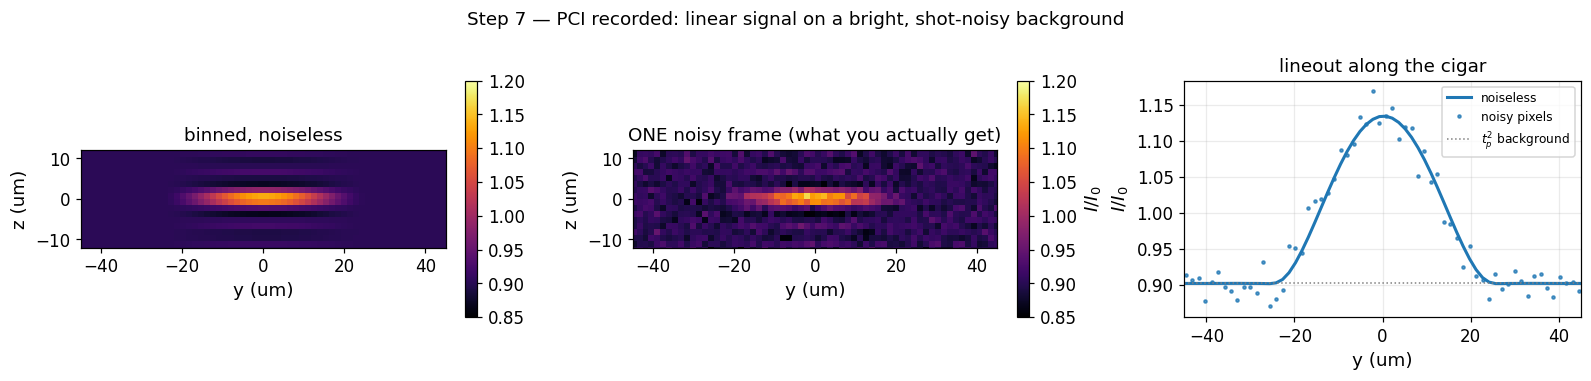

In [37]:
# ---- STEP 7: PCI, the recorded frame ------------------------------------------
st_cam_pci, st_ideal_pci = to_camera(st_I_pci, st_P)
st_nb = Ngrid//15; st_ycam = (np.arange(st_nb)-st_nb//2+0.5)*pix_obj*1e6; st_mid = st_nb//2

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14.6, 3.5))
im1 = a1.imshow(st_ideal_pci, extent=ext, origin='lower', cmap='inferno', vmin=0.85, vmax=1.20)
a1.set_title('binned, noiseless'); plt.colorbar(im1, ax=a1, fraction=0.03)
im2 = a2.imshow(st_cam_pci, extent=ext, origin='lower', cmap='inferno', vmin=0.85, vmax=1.20)
a2.set_title('ONE noisy frame (what you actually get)'); plt.colorbar(im2, ax=a2, fraction=0.03, label='$I/I_0$')
for a in (a1, a2):
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')
a3.plot(st_ycam, st_ideal_pci[st_mid], 'C0', lw=2, label='noiseless')
a3.plot(st_ycam, st_cam_pci[st_mid], 'C0.', ms=4, alpha=0.75, label='noisy pixels')
a3.axhline(bg_plate, color='gray', ls=':', lw=1, label='$t_p^2$ background')
a3.set_xlim(-45, 45); a3.set_xlabel('y (um)'); a3.set_ylabel('$I/I_0$')
a3.set_title('lineout along the cigar'); a3.legend(fontsize=8); a3.grid(alpha=0.25)
fig.suptitle('Step 7 — PCI recorded: linear signal on a bright, shot-noisy background', fontsize=12)
plt.tight_layout(); plt.show()

### 19.3 DGI — delete the carrier (Steps 8–9)

#### Step 8 — the dark stop removes the big arrow; only the wavelet flies on

**Theory.** Instead of rotating the carrier, absorb it: an OD-4 stop leaves
$1 \mapsto \varepsilon = 10^{-\mathrm{OD}/2} = 0.01$. The image field is essentially the wavelet
alone:
$$I = |\varepsilon + w|^2 \approx |w|^2 = 4\sin^2(\varphi/2) \approx \varphi^2 ,$$
**quadratic** in the signal, on a background of the leak, $\varepsilon^2 = 10^{-4}$.

**What is happening.** In the phasor picture the blue arrow is simply *gone* — what remains is the
red wavelet, whose squared length is now the intensity directly. No interference, no local
oscillator: the cloud glows by its own scattered light on a black field, the classic dark-ground
image of Andrews et al. (1996). The catch is in the numbers: $|w|^2 = 0.041$ — the signal is
*self-referenced* and therefore small-squared. Note the colour bar relative to Step 6.

**What the code does.** `E = 10**(-OD/2) + Esc` — again a single analytic carrier coefficient;
same wavelet, same propagation, same everything else.

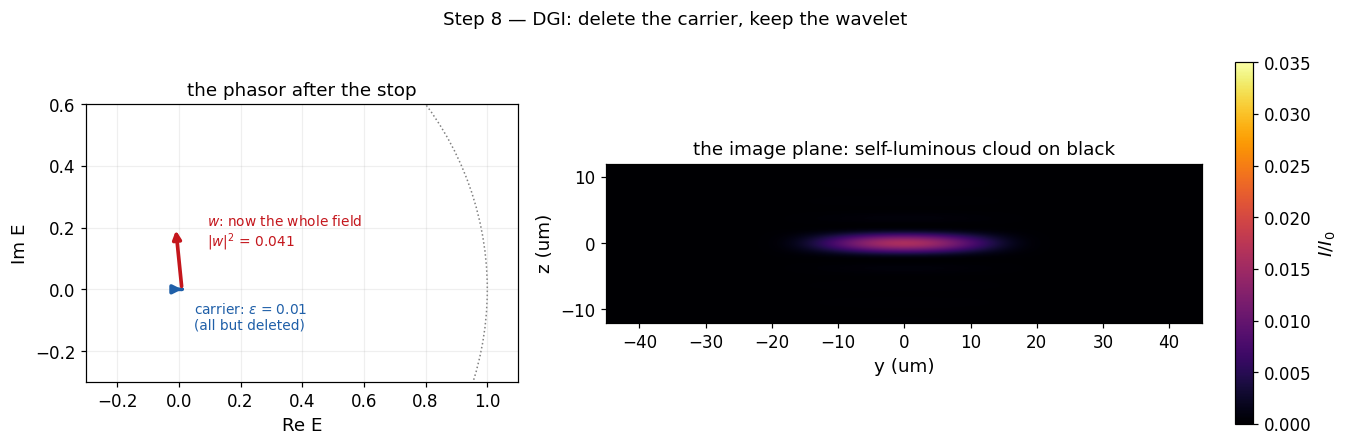

peak of the dark-ground image: 0.0160 of I0 (vs 4 sin^2(phi/2) = 0.0410 before aperture loss); background floor eps^2 = 1e-04.


In [38]:
# ---- STEP 8: carrier deleted, the wavelet's own light ------------------------
st_I_dgi, _ = sim_image(0, st_phi0, 'DGI')
st_eps = 10**(-4.0/2)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.1), gridspec_kw=dict(width_ratios=[1, 1.5]))
a1.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls=':', color='gray', lw=1))
a1.annotate('', xy=(st_eps, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#1f5fa8', lw=2.4))
a1.annotate('carrier: $\\varepsilon$ = 0.01\n(all but deleted)', (0.05, -0.13), color='#1f5fa8', fontsize=9)
tip = st_eps + st_wc
a1.annotate('', xy=(tip.real, tip.imag), xytext=(st_eps, 0),
            arrowprops=dict(arrowstyle='-|>', color='#c4161c', lw=2.4))
a1.annotate('$w$: now the whole field\n$|w|^2$ = %.3f' % abs(st_wc)**2, (0.09, 0.14), color='#c4161c', fontsize=9)
a1.set_xlim(-0.30, 1.10); a1.set_ylim(-0.30, 0.60); a1.set_aspect('equal')
a1.set_xlabel('Re E'); a1.set_ylabel('Im E'); a1.grid(alpha=0.2)
a1.set_title('the phasor after the stop')
im = a2.imshow(st_I_dgi, extent=ext, origin='lower', cmap='inferno', vmin=0, vmax=0.035)
a2.set_xlim(-45, 45); a2.set_ylim(-12, 12); a2.set_xlabel('y (um)'); a2.set_ylabel('z (um)')
a2.set_title('the image plane: self-luminous cloud on black')
plt.colorbar(im, ax=a2, fraction=0.03, label='$I/I_0$')
fig.suptitle('Step 8 — DGI: delete the carrier, keep the wavelet', fontsize=12)
plt.tight_layout(); plt.show()
print(f"peak of the dark-ground image: {st_I_dgi.max():.4f} of I0 (vs 4 sin^2(phi/2) = "
      f"{4*np.sin(st_phi0/2)**2:.4f} before aperture loss); background floor eps^2 = {st_eps**2:.0e}.")

#### Step 9 — the dark frame on the camera

**Theory.** The same detection step as Step 7, but the arithmetic is now brutally different: the
peak intensity is 0.03 of $I_0$, so the brightest pixel collects ~100 detected photons instead of
~4800 — shot noise of ~10 e⁻ against a 7 e⁻ read floor.

**What is happening.** One noisy dark-ground frame. The cloud is still detectable in a single shot
(SNR ≈ 6/pixel, §18.4) but visibly grainier than PCI's — the quadratic transfer starved it of
photons *before* the noise was ever rolled. In exchange: essentially zero background, so nothing
of the probe's brightness or flicker contaminates the frame. This trade — signal linearity versus
background darkness — is the entire PCI-vs-DGI decision of §9, now visible as two camera frames
of the same cloud.

**What the code does.** identical `to_camera(...)` call; only the input image changed.

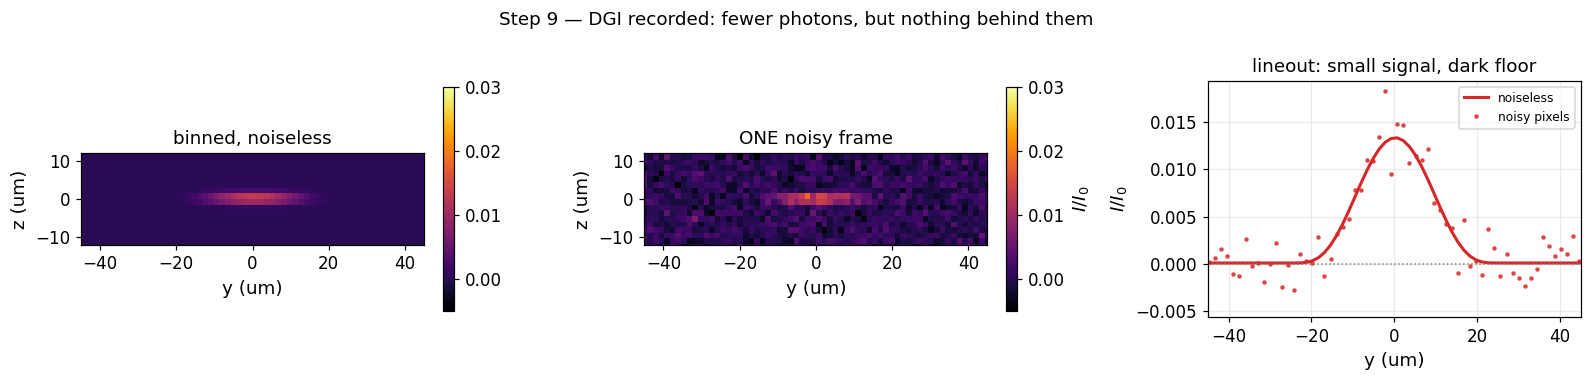

In [39]:
# ---- STEP 9: DGI, the recorded frame ------------------------------------------
st_cam_dgi, st_ideal_dgi = to_camera(st_I_dgi, st_P)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14.6, 3.5))
im1 = a1.imshow(st_ideal_dgi, extent=ext, origin='lower', cmap='inferno', vmin=-0.005, vmax=0.03)
a1.set_title('binned, noiseless'); plt.colorbar(im1, ax=a1, fraction=0.03)
im2 = a2.imshow(st_cam_dgi, extent=ext, origin='lower', cmap='inferno', vmin=-0.005, vmax=0.03)
a2.set_title('ONE noisy frame'); plt.colorbar(im2, ax=a2, fraction=0.03, label='$I/I_0$')
for a in (a1, a2):
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')
a3.plot(st_ycam, st_ideal_dgi[st_mid], 'C3', lw=2, label='noiseless')
a3.plot(st_ycam, st_cam_dgi[st_mid], 'C3.', ms=4, alpha=0.75, label='noisy pixels')
a3.axhline(0, color='gray', ls=':', lw=1)
a3.set_xlim(-45, 45); a3.set_xlabel('y (um)'); a3.set_ylabel('$I/I_0$')
a3.set_title('lineout: small signal, dark floor'); a3.legend(fontsize=8); a3.grid(alpha=0.25)
fig.suptitle('Step 9 — DGI recorded: fewer photons, but nothing behind them', fontsize=12)
plt.tight_layout(); plt.show()

### 19.4 Dark-field Faraday — let the light rotate (Steps 10–11)

#### Step 10 — one beam, two circular halves, two opposite phase maps

**Theory.** A linear probe is an equal superposition of circular components,
$\hat x = (\hat\epsilon_- - \hat\epsilon_+)/\sqrt2$. A spin-polarized cloud delays them
*differently* (§17.1): $\pm\theta_F(\mathbf r)$. Recombined, that is not a phase shift but a
**rotation** of the polarization plane:
$$\mathbf E = \cos\theta_F(\mathbf r)\,\hat x \;-\; \sin\theta_F(\mathbf r)\,\hat y .$$

**What is happening.** No Fourier-plane surgery this time — the carrier is never touched. Instead
the field is *split against itself*: each circular half plays local oscillator for the other, and
their beat shows up as a position-dependent tilt of the polarization. The left panel below maps
that tilt in degrees, from the **actual simulated $(E_x, E_y)$**: it is zero away from the cloud
and reaches a peak of $\theta_F = 0.203$ rad ≈ 11.6° imprinted (about 7° after the aperture blur).
This is a *small* rotation — the overlaid arrows are exaggerated ×6 so the lean is visible at all —
which is the whole point: the information has moved from an unmeasurable overall phase into a
*direction*, and even a small change of direction can be read out with polarizers. The right panel
shows $|E_y|^2$, the new polarization component the rotation creates and the light a crossed
analyzer will pass (Step 11).

**What the code does.** `sim_faraday_fields(axis, th)` — two runs of the same shared core with
phases $\pm\theta_F$, recombined as $E_x = (P_+ + P_-)/2$, $E_y = i(P_+ - P_-)/2$.

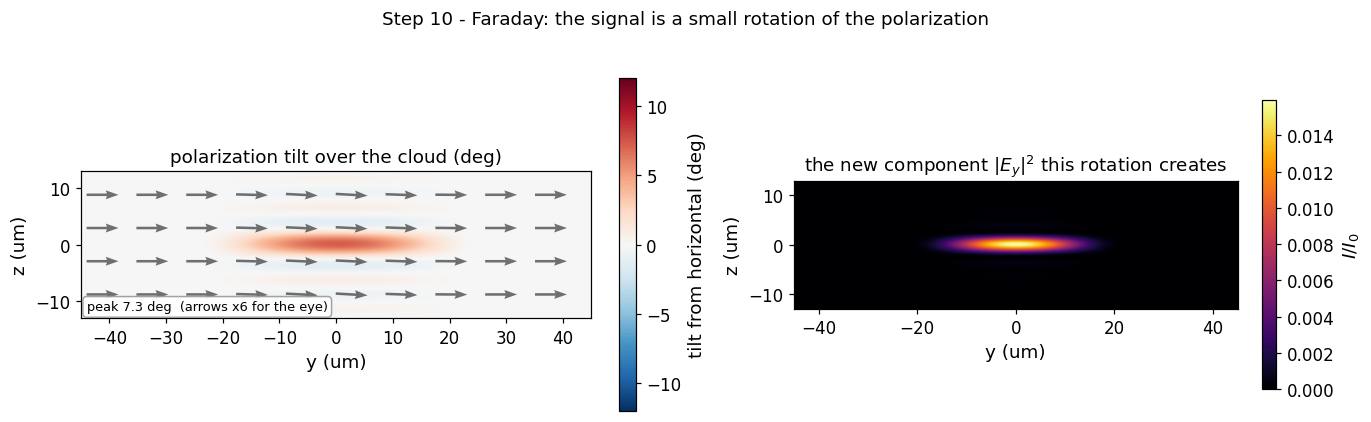

imprinted rotation: theta_F,peak = 0.203 rad = 11.6 deg (kappa_F = 1 placeholder, Sec. 17.1); largest tilt surviving the aperture into the image: 7.3 deg. The effect is small -- which is exactly why the crossed analyzer (sin^2) and the balanced ports (sin 2theta) are needed to read it out.


In [40]:
# ---- STEP 10: the rotated field ------------------------------------------------
# The rotation here is SMALL (~11 deg peak), so a raw arrow map looks flat and reads as
# nothing. Two honest fixes: (a) show the local tilt as a heatmap in DEGREES so it can be
# read quantitatively, with arrows exaggerated purely for the eye; (b) show |E_y|^2, the new
# polarization component the rotation creates -- the light the crossed analyzer will catch.
st_th0 = theta_F_peak(st_Delta, n_col[0])
st_Ex, st_Ey = sim_faraday_fields(0, st_th0)
st_tilt = np.degrees(np.arctan2(-np.real(st_Ey), np.real(st_Ex)))   # local polarization tilt, deg
st_peak_true, st_peak_img = np.degrees(st_th0), st_tilt.max()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.6, 4.1), gridspec_kw=dict(width_ratios=[1.15, 1]))
im = a1.imshow(st_tilt, extent=ext, origin='lower', cmap='RdBu_r', vmin=-12, vmax=12)
EXAG = 6                                                             # arrow-angle exaggeration (display only)
st_iy = np.arange(90, Ngrid-90, 90); st_iz = np.arange(Ngrid//2-150, Ngrid//2+151, 60)
YY, ZZ = np.meshgrid(gax[st_iy]*1e6, gax[st_iz]*1e6)
st_ang = np.radians(st_tilt[np.ix_(st_iz, st_iy)]) * EXAG
a1.quiver(YY, ZZ, np.cos(st_ang), np.sin(st_ang), pivot='mid', scale=16,
          width=0.005, headwidth=3.5, color='k', alpha=0.55)
a1.set_xlim(-45, 45); a1.set_ylim(-13, 13); a1.set_xlabel('y (um)'); a1.set_ylabel('z (um)')
a1.set_title('polarization tilt over the cloud (deg)')
plt.colorbar(im, ax=a1, fraction=0.03, label='tilt from horizontal (deg)')
a1.annotate(f'peak {st_peak_img:.1f} deg  (arrows x{EXAG} for the eye)', (-44, -11.6), fontsize=8.4,
            bbox=dict(boxstyle='round', fc='white', ec='0.6', alpha=0.9))
im2 = a2.imshow(np.abs(st_Ey)**2, extent=ext, origin='lower', cmap='inferno')
a2.set_xlim(-45, 45); a2.set_ylim(-13, 13); a2.set_xlabel('y (um)'); a2.set_ylabel('z (um)')
a2.set_title('the new component $|E_y|^2$ this rotation creates')
plt.colorbar(im2, ax=a2, fraction=0.03, label='$I/I_0$')
fig.suptitle('Step 10 - Faraday: the signal is a small rotation of the polarization', fontsize=12)
plt.tight_layout(); plt.show()
print(f"imprinted rotation: theta_F,peak = {st_th0:.3f} rad = {st_peak_true:.1f} deg "
      f"(kappa_F = 1 placeholder, Sec. 17.1); largest tilt surviving the aperture into the "
      f"image: {st_peak_img:.1f} deg. The effect is small -- which is exactly why the crossed "
      f"analyzer (sin^2) and the balanced ports (sin 2theta) are needed to read it out.")

#### Step 11 — the crossed analyzer: keep only what rotated

**Theory.** A polarizer at 90° to the input transmits only $E_y$:
$$I_\mathrm{dark} = \sin^2\theta_F \approx \theta_F^2 .$$
Quadratic again — structurally this is DGI in polarization clothing, with the analyzer's
extinction ratio playing the role of the stop's OD.

**What is happening.** The analyzer throws away the untouched horizontal component — the
"carrier" of this scheme — and passes the tilt. What lands on the camera is the left panel of
Step 10 with photon noise on top: a dark frame, a faintly glowing condensate, no Fourier-plane
optics anywhere in the beam path. That last point is the practical selling point (§17.2): the
same contrast philosophy as DGI, bought with a polarizer instead of a precision-machined stop at
an awkward intermediate focus.

**What the code does.** the `I_dark = np.abs(Ey)**2` line of `faraday_maps`, then the usual
`to_camera(...)`.

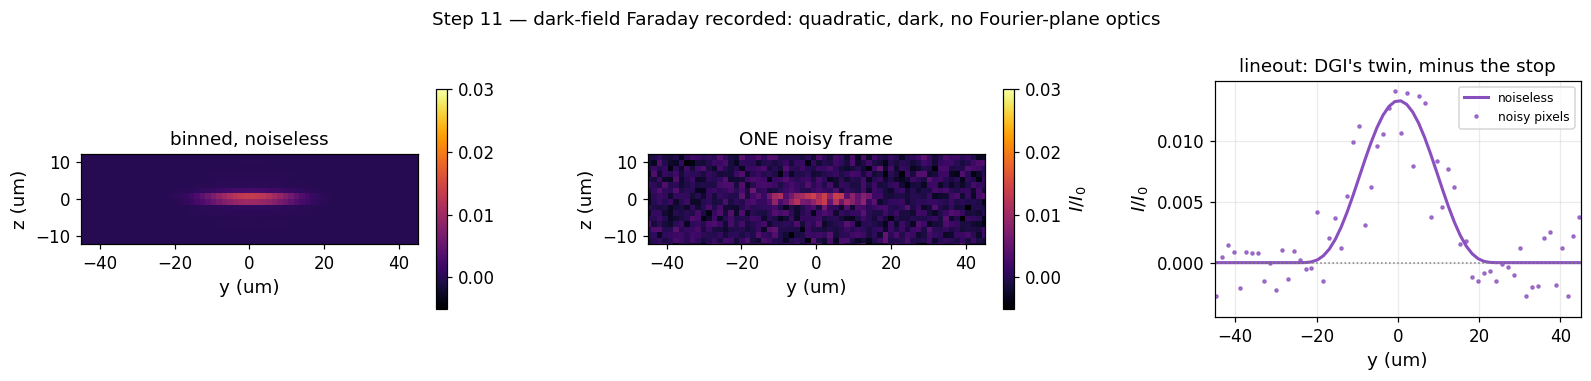

In [41]:
# ---- STEP 11: dark-field Faraday, recorded --------------------------------------
st_cam_df, st_ideal_df = to_camera(np.abs(st_Ey)**2, st_P)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14.6, 3.5))
im1 = a1.imshow(st_ideal_df, extent=ext, origin='lower', cmap='inferno', vmin=-0.005, vmax=0.03)
a1.set_title('binned, noiseless'); plt.colorbar(im1, ax=a1, fraction=0.03)
im2 = a2.imshow(st_cam_df, extent=ext, origin='lower', cmap='inferno', vmin=-0.005, vmax=0.03)
a2.set_title('ONE noisy frame'); plt.colorbar(im2, ax=a2, fraction=0.03, label='$I/I_0$')
for a in (a1, a2):
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')
a3.plot(st_ycam, st_ideal_df[st_mid], color='#8a4fbe', lw=2, label='noiseless')
a3.plot(st_ycam, st_cam_df[st_mid], '.', color='#8a4fbe', ms=4, alpha=0.75, label='noisy pixels')
a3.axhline(0, color='gray', ls=':', lw=1)
a3.set_xlim(-45, 45); a3.set_xlabel('y (um)'); a3.set_ylabel('$I/I_0$')
a3.set_title('lineout: DGI\'s twin, minus the stop'); a3.legend(fontsize=8); a3.grid(alpha=0.25)
fig.suptitle('Step 11 — dark-field Faraday recorded: quadratic, dark, no Fourier-plane optics', fontsize=12)
plt.tight_layout(); plt.show()

### 19.5 Dual-port Faraday — measure the direction twice (Steps 12–13)

#### Step 12 — a beamsplitter at 45°: the rotation tips a balance

**Theory.** Analyse the same rotated field of Step 10 with a polarizing beamsplitter at 45°. The
two ports receive
$$I_{u,v} = \tfrac12\big(1 \mp \sin 2\theta_F\big),$$
and their *normalized difference* is linear in the rotation:
$$S = \frac{I_v - I_u}{I_v + I_u} = \sin 2\theta_F \approx 2\,\theta_F .$$

**What is happening.** Nothing is thrown away this time. Both ports are bright — each is half the
probe — and away from the cloud they are exactly balanced. Over the condensate the rotation
*tips light from one port into the other*: the left panel dims where the right panel brightens,
by the same amount (energy through a PBS is conserved). The third panel is the recovered $S$ map:
the cloud reappears, linear in $\theta_F$, like PCI — but the "local oscillator" here is the other
half of the same beam, so no plate, no $t_p$, and every photon is used.

**What the code does.** `I_u = |Ex+Ey|²/2`, `I_v = |Ex−Ey|²/2` in `faraday_maps`, then the ratio.

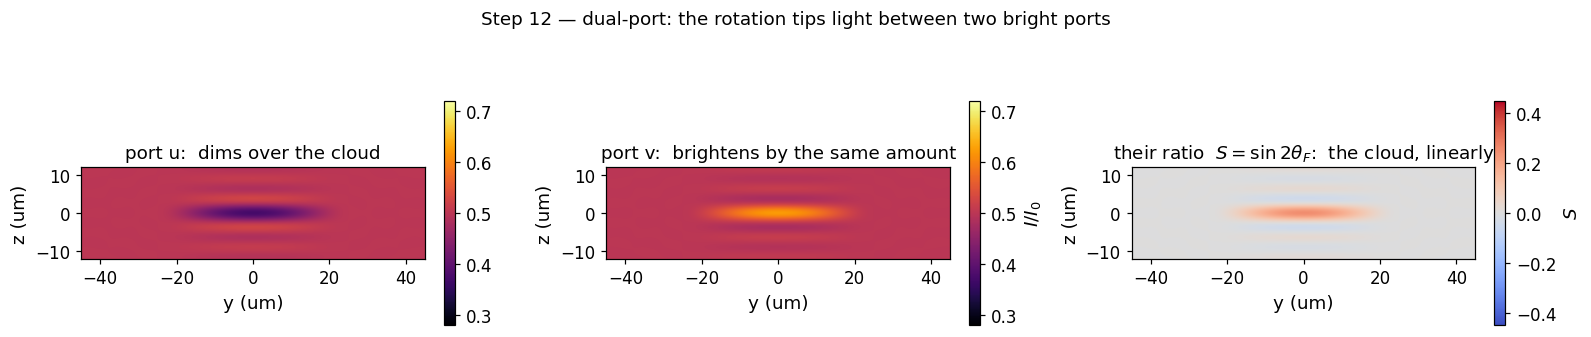

energy check at the cloud centre: I_u + I_v = 0.9955 of I0  -> nothing discarded; S at the centre = 0.251, vs sin(2 theta_F) = 0.395 imprinted -- the gap is, once again, Step 4's aperture blur, not a new loss.


In [42]:
# ---- STEP 12: the two ports and the balance they keep ---------------------------
st_Iu = np.abs(st_Ex + st_Ey)**2 / 2
st_Iv = np.abs(st_Ex - st_Ey)**2 / 2
st_S  = (st_Iv - st_Iu) / (st_Iv + st_Iu)

fig, axs = plt.subplots(1, 3, figsize=(14.6, 3.5))
im0 = axs[0].imshow(st_Iu, extent=ext, origin='lower', cmap='inferno', vmin=0.28, vmax=0.72)
axs[0].set_title('port u:  dims over the cloud'); plt.colorbar(im0, ax=axs[0], fraction=0.03)
im1 = axs[1].imshow(st_Iv, extent=ext, origin='lower', cmap='inferno', vmin=0.28, vmax=0.72)
axs[1].set_title('port v:  brightens by the same amount'); plt.colorbar(im1, ax=axs[1], fraction=0.03, label='$I/I_0$')
im2 = axs[2].imshow(st_S, extent=ext, origin='lower', cmap='coolwarm', vmin=-0.45, vmax=0.45)
axs[2].set_title('their ratio  $S = \\sin 2\\theta_F$:  the cloud, linearly')
plt.colorbar(im2, ax=axs[2], fraction=0.03, label='$S$')
for a in axs:
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')
fig.suptitle('Step 12 — dual-port: the rotation tips light between two bright ports', fontsize=12)
plt.tight_layout(); plt.show()
print(f"energy check at the cloud centre: I_u + I_v = "
      f"{(st_Iu+st_Iv)[Ngrid//2, Ngrid//2]:.4f} of I0  -> nothing discarded; "
      f"S at the centre = {st_S[Ngrid//2, Ngrid//2]:.3f}, vs sin(2 theta_F) = {np.sin(2*st_th0):.3f} "
      f"imprinted -- the gap is, once again, Step 4's aperture blur, not a new loss.")

#### Step 13 — record both ports; the ratio shrugs off the laser

**Theory.** Each port frame carries shot + read noise; the ratio inherits
$\sigma_\theta = \sqrt{N_u+N_v+2\sigma_r^2}\,/\,2(N_u+N_v) \to 1/2\sqrt{N_\mathrm{tot}}$, the
polarimetric shot limit. But any *common* factor $g$ on the probe — power drift, pointing flicker —
multiplies both ports and **cancels identically in $S$**.

**What is happening.** Top row: one noisy frame of each port, and the $S$ frame computed from
them — the condensate recovered from two noisy images, single shot. Bottom: the story-beat. Eight
consecutive shots are simulated with a deliberately jittery probe (3% rms power flicker, injected
into both ports of each shot). The recorded port brightness wanders shot to shot — but the
extracted $\theta_F$ doesn't budge beyond its photon noise. That immunity is why the dual-port
scheme exists (Kaminski et al. 2012), and here it is happening in the simulation's own noise.

**What the code does.** `to_camera(...)` on each port; then `(cv−cu)/(cv+cu)/2` per pixel. For the
flicker test, the same Poisson draw with means multiplied by one shared `g = rng.normal(1, 0.03)`
per shot.

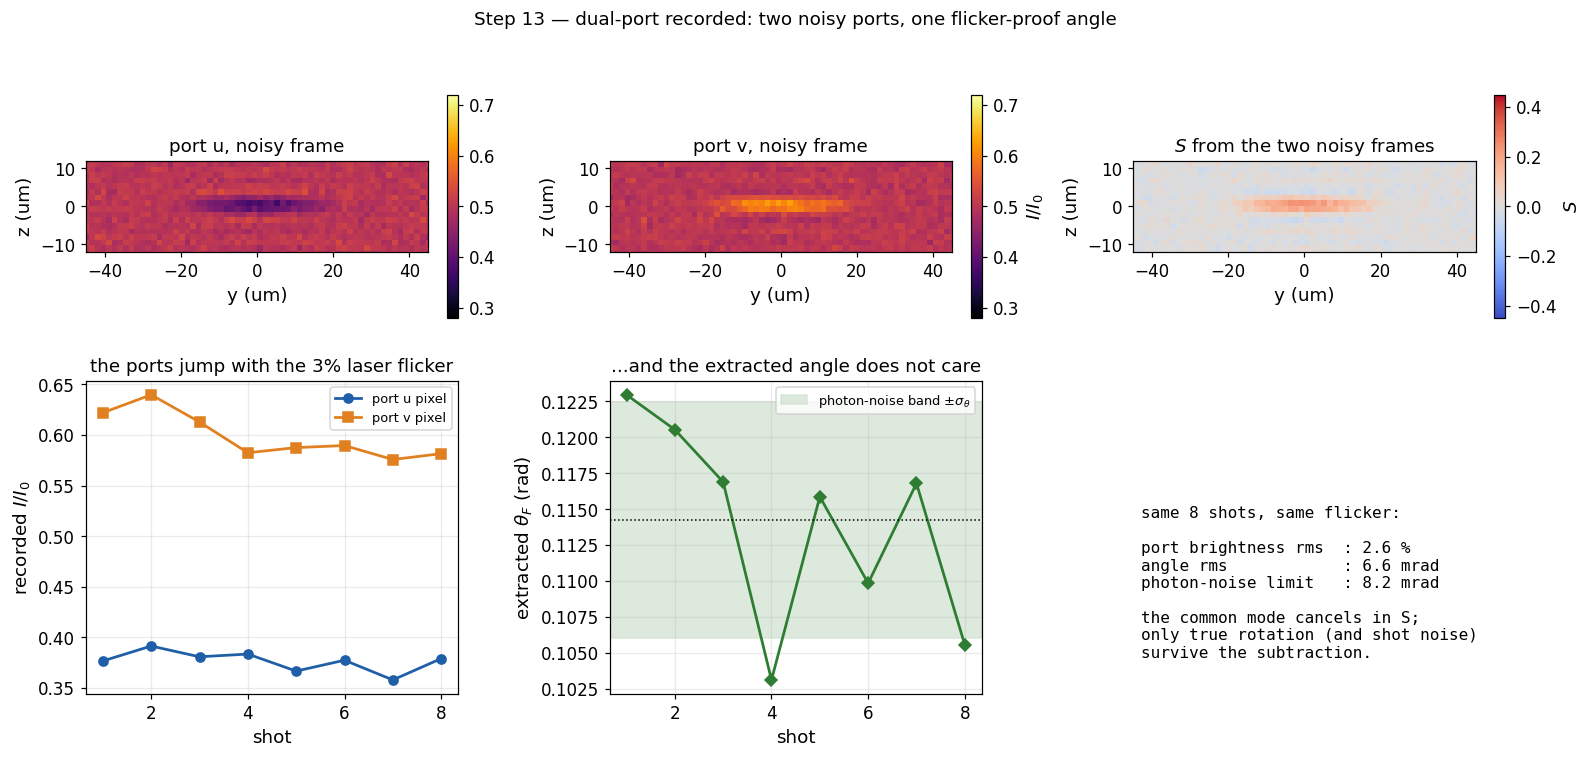

In [43]:
# ---- STEP 13: two noisy ports -> one clean angle; then shake the laser -----------
st_cam_u, st_bin_u = to_camera(st_Iu, st_P)
st_cam_v, st_bin_v = to_camera(st_Iv, st_P)
st_S_frame = (st_cam_v - st_cam_u) / (st_cam_v + st_cam_u)

fig, axs = plt.subplots(2, 3, figsize=(14.6, 7.0))
im0 = axs[0,0].imshow(st_cam_u, extent=ext, origin='lower', cmap='inferno', vmin=0.28, vmax=0.72)
axs[0,0].set_title('port u, noisy frame'); plt.colorbar(im0, ax=axs[0,0], fraction=0.03)
im1 = axs[0,1].imshow(st_cam_v, extent=ext, origin='lower', cmap='inferno', vmin=0.28, vmax=0.72)
axs[0,1].set_title('port v, noisy frame'); plt.colorbar(im1, ax=axs[0,1], fraction=0.03, label='$I/I_0$')
im2 = axs[0,2].imshow(st_S_frame, extent=ext, origin='lower', cmap='coolwarm', vmin=-0.45, vmax=0.45)
axs[0,2].set_title('$S$ from the two noisy frames'); plt.colorbar(im2, ax=axs[0,2], fraction=0.03, label='$S$')
for a in axs[0]:
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)'); a.set_ylabel('z (um)')

# eight shots with a 3% flickering probe: watch the ports jump, and theta not care
_Nd = N_phot_pix(st_P)
_nb2 = (Ngrid//15)*15; _midb = _nb2//30
_bu = st_Iu[:_nb2,:_nb2].reshape(_nb2//15,15,_nb2//15,15).mean(axis=(1,3))[_midb,_midb]
_bv = st_Iv[:_nb2,:_nb2].reshape(_nb2//15,15,_nb2//15,15).mean(axis=(1,3))[_midb,_midb]
_shots = np.arange(1, 9); _pu = []; _pv = []; _thm = []
for _s in _shots:
    _g  = rng.normal(1.0, 0.03)
    _nu = rng.poisson(_bu*_Nd*_g) + rng.normal(0, read_e)
    _nv = rng.poisson(_bv*_Nd*_g) + rng.normal(0, read_e)
    _pu.append(_nu/_Nd); _pv.append(_nv/_Nd); _thm.append((_nv-_nu)/(_nv+_nu)/2)
_th_true = (_bv-_bu)/(_bv+_bu)/2
_sig_th  = np.sqrt(_bu*_Nd+_bv*_Nd+2*read_e**2)/(_bu*_Nd+_bv*_Nd)/2

axL = axs[1,0]
axL.plot(_shots, _pu, 'o-', color='#1f5fa8', lw=1.8, label='port u pixel')
axL.plot(_shots, _pv, 's-', color='#e08020', lw=1.8, label='port v pixel')
axL.set_xlabel('shot'); axL.set_ylabel('recorded $I/I_0$')
axL.set_title('the ports jump with the 3% laser flicker'); axL.legend(fontsize=8.5); axL.grid(alpha=0.25)
axM = axs[1,1]
axM.axhspan(_th_true-_sig_th, _th_true+_sig_th, color='#cfe0cf', alpha=0.7,
            label='photon-noise band $\\pm\\sigma_\\theta$')
axM.plot(_shots, _thm, 'D-', color='#2e7d32', lw=1.8)
axM.axhline(_th_true, color='k', ls=':', lw=1)
axM.set_xlabel('shot'); axM.set_ylabel('extracted $\\theta_F$ (rad)')
axM.set_title('...and the extracted angle does not care'); axM.legend(fontsize=8.5); axM.grid(alpha=0.25)
axs[1,2].axis('off')
axs[1,2].text(0.02, 0.60, 'same 8 shots, same flicker:\n\n'
              f'port brightness rms  : {100*np.std(_pu)/np.mean(_pu):.1f} %\n'
              f'angle rms            : {1e3*np.std(_thm):.1f} mrad\n'
              f'photon-noise limit   : {1e3*_sig_th:.1f} mrad\n\n'
              'the common mode cancels in S;\nonly true rotation (and shot noise)\nsurvive the subtraction.',
              fontsize=10.5, family='monospace', va='top')
fig.suptitle('Step 13 — dual-port recorded: two noisy ports, one flicker-proof angle', fontsize=12)
plt.tight_layout(); plt.show()

### 19.6 Step 14 — the price of looking: the run as a filmstrip

**Theory.** Each frame scatters $N_\gamma$ photons per atom, depositing a fixed energy that walks
the temperature up ($T^4_{s+1} = T^4_s + \Delta E/A_E$, §12–13) and eats the condensate,
$N_0(T) = N_\mathrm{tot}[1-(T/T_c)^3]$. The shrinking cloud imprints a shrinking $\varphi$ — the
signal the *next* frame has to work with.

**What is happening.** Below is the §13 heating run (Δ = 1.5 GHz, 3.5 mW, 40 µs) rendered as what
it actually is: a sequence of camera frames of one condensate being watched to its 30% loss
budget. Each panel is a full noisy PCI frame simulated at that shot's phase, with the shot's
$N_0$, $T$ and $\varphi$ as captions. Frame by frame the signal drains — a fifth of $\varphi$
over the run, read off the captions — because non-destructive imaging does not mean free imaging:
it means *budgeted* imaging, and this is the budget being spent. (The Thomas–Fermi radii change by <10% over the run, so the fresh-cloud profile is reused
with each shot's own $\varphi_s$ — the same approximation as the engine itself, §13.)

**What the code does.** `run_sequence(...)` supplied the per-shot $\varphi_s$ (stored in `seq_h`);
each panel is one `sim_image` + Poisson/read-noise draw at the run's own power and pulse length.

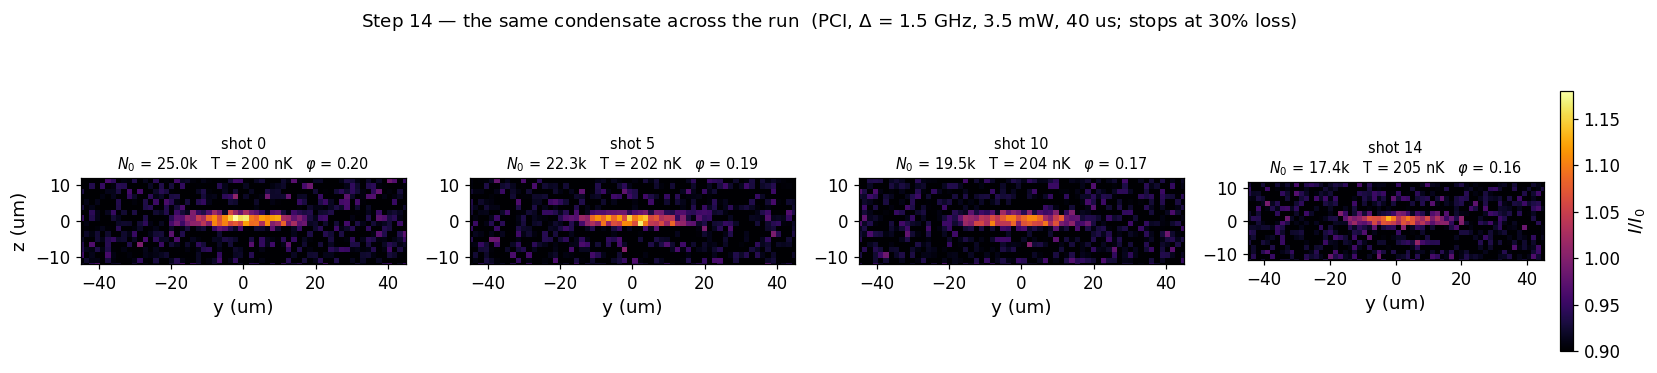

signal spent per frame: phi falls 0.203 -> 0.163 rad over 15 frames while T climbs 200 -> 205 nK. Every mode of Steps 6-13 spends this same budget; only what it buys per frame differs.


In [44]:
# ---- STEP 14: watching the condensate die, frame by frame ------------------------
st_show = [0, 5, 10, 14]                                   # shots along the heating run
st_Nd_run = N_phot_pix(SEQ_P_mW, SEQ_tau)                  # the run's own power AND pulse length

fig, axs = plt.subplots(1, len(st_show), figsize=(15.2, 3.6))
for a, s in zip(axs, st_show):
    phi_s = seq_h['phi'][s]
    I_s, _ = sim_image(SEQ_axis, phi_s, 'PCI')
    b = I_s[:_nb2,:_nb2].reshape(_nb2//15,15,_nb2//15,15).mean(axis=(1,3))
    frame = (rng.poisson(np.clip(b,0,None)*st_Nd_run) + rng.normal(0, read_e, b.shape)) / st_Nd_run
    im = a.imshow(frame, extent=ext, origin='lower', cmap='inferno', vmin=0.90, vmax=1.18)
    a.set_xlim(-45, 45); a.set_ylim(-12, 12); a.set_xlabel('y (um)')
    a.set_title(f'shot {s}\n$N_0$ = {seq_h["N0"][s]/1e3:.1f}k   T = {seq_h["T"][s]*1e9:.0f} nK'
                f'   $\\varphi$ = {phi_s:.2f}', fontsize=9.5)
axs[0].set_ylabel('z (um)')
plt.colorbar(im, ax=axs[-1], fraction=0.04, label='$I/I_0$')
fig.suptitle(f'Step 14 — the same condensate across the run  '
             f'(PCI, $\\Delta$ = {SEQ_Delta_GHz} GHz, {SEQ_P_mW} mW, {SEQ_tau_us:.0f} us; '
             f'stops at {SEQ_loss_frac:.0%} loss)', fontsize=12)
plt.tight_layout(); plt.show()
print(f"signal spent per frame: phi falls {seq_h['phi'][0]:.3f} -> {seq_h['phi'][-1]:.3f} rad over "
      f"{len(seq_h['shot'])} frames while T climbs {seq_h['T'][0]*1e9:.0f} -> {seq_h['T'][-1]*1e9:.0f} nK. "
      f"Every mode of Steps 6-13 spends this same budget; only what it buys per frame differs.")

---
**The story in one paragraph.** The atoms hand the light a phase map and nothing else (Step 1);
phase is invisible to any camera (Step 2) because the information rides in a small wavelet at 90°
to a big carrier (Step 3); the two separate only at the Fourier plane (Step 4), and a perfect lens
system alone reunites them as invisibly as they arrived (Step 5). PCI rotates the carrier under
the wavelet and buys a *linear*, bright-background image (Steps 6–7); DGI deletes the carrier and
buys a *quadratic*, dark-background one (Steps 8–9); Faraday sidesteps the Fourier plane entirely
by letting the two circular halves of the beam phase against each other — read through a crossed
polarizer it is DGI's quadratic twin (Steps 10–11), read through two balanced ports it is PCI's
linear twin with built-in immunity to the probe's own noise (Steps 12–13). All four spend the
identical destruction budget; the filmstrip of Step 14 is that budget being spent. The tables of
§17.3 and §18.4 are the accounting; this section is the film.

---
## References

The apparatus and BEC operating point used throughout are taken from the group's own thesis (K24);
the imaging techniques and destruction-budget arguments draw on the dispersive- and
Faraday-imaging literature below. (This consolidates and extends the short citation list in the
introduction at the top of the notebook.)

**Apparatus**

1. Kucera, DPhil thesis, University of Oxford (2024) [K24] -- imaging arm (§3.1.3), 401 nm
   transition (§3.2.2), BEC operating point (§6.3.1).

**Dispersive imaging of BECs (PCI / DGI)**

2. W. Ketterle, D. S. Durfee, D. M. Stamper-Kurn, "Making, probing and understanding
   Bose-Einstein condensates," in *Proceedings of the International School of Physics "Enrico
   Fermi," Course CXL* (IOS Press, 1999), arXiv:cond-mat/9904034 -- dispersive-imaging and
   phase-contrast review used throughout §5-§8.
3. M. R. Andrews, M.-O. Mewes, N. J. van Druten, D. S. Durfee, D. M. Kurn, W. Ketterle, "Direct,
   Nondestructive Observation of a Bose Condensate," Science **273**, 84 (1996) -- first
   non-destructive dark-ground observation of a BEC; motivates the DGI mode of §7.1.
4. R. Meppelink, R. A. Rozendaal, S. B. Koller, J. M. Vogels, P. van der Straten,
   "Thermodynamics of Bose-Einstein-condensed clouds using phase-contrast imaging," Phys. Rev. A
   **81**, 053632 (2010) -- primary reference for the PCI transfer-curve convention used in
   §5.3 and §7.2.
5. F. Böttcher, J.-N. Schmidt, M. Wenzel, J. Hertkorn, M. Guo, T. Langen, T. Pfau, "Transient
   Supersolid Properties in an Array of Dipolar Quantum Droplets," Phys. Rev. X **9**, 011051
   (2019) -- single-shot, in-situ far-detuned phase-contrast imaging of a strongly dipolar (Dy)
   condensate at the analogous 421 nm line; cited in §12 as the "right-substance" precedent
   for the revised destruction model.

**Faraday (polarization-rotation) imaging -- new in §17**

6. M. Gajdacz, P. L. Pedersen, T. Mørch, A. J. Hilliard, J. Arlt, J. F. Sherson,
   "Non-destructive Faraday imaging of dynamically controlled ultracold atoms," Rev. Sci.
   Instrum. **84**, 083105 (2013) -- the dark-field (crossed-polarizer) configuration of
   §17.2(a); reports up to 2000 images of the same cloud.
7. F. Kaminski, N. S. Kampel, M. P. H. Steenstrup, A. Griesmaier, E. S. Polzik, J. H. Müller,
   "In-situ dual-port polarization contrast imaging of Faraday rotation in a high optical depth
   ultracold $^{87}$Rb atomic ensemble," Eur. Phys. J. D **66**, 227 (2012) -- the balanced
   dual-port configuration of §17.2(b).
8. M. A. Kristensen, M. Gajdacz, P. L. Pedersen, C. Klempt, J. F. Sherson, J. J. Arlt, A. J.
   Hilliard, "Sub-atom shot noise Faraday imaging of ultracold atom clouds," J. Phys. B **50**,
   034004 (2017) -- quantitative shot-noise-limited precision analysis behind the SNR comparison
   of §17.3.

**Erbium apparatus context**

9. K. Aikawa, A. Frisch, M. Mark, S. Baier, A. Rietzler, R. Grimm, F. Ferlaino, "Bose-Einstein
   Condensation of Erbium," Phys. Rev. Lett. **108**, 210401 (2012) -- first quantum-degenerate
   erbium gas ($^{168}$Er); established the 401 nm cooling/imaging transition shared with the
   $^{166}$Er apparatus modelled here.

---
*Note on $\kappa_F$ (§17.1): the vector-coupling coefficient for the 401 nm $^{166}$Er
stretched-state transition was not found in the literature searched for this notebook and is left
as an explicit placeholder ($\kappa_F=1$, an idealised bound) pending either an atomic-structure
calculation or a lab measurement -- the same status as the `QE_cam`/`read_e` placeholders of
§2.*